## 🚀 Important Colab Setup Instructions

1. **Always run the setup cell below first** (even if you've copied this notebook to Drive)
    - Skip this setup if you've locally cloned the repo
2. **If you copy to Drive**: Re-run the setup cell to restore the working environment
    - Copy to Drive is not necessary, but allows you to save changes to the notebook.
3. **The setup cell is idempotent** — safe to run multiple times
4. **If you've cloned the repo and want to run locally (e.g. VS Code)**: Skip the enviroment set-up cell. We then recommend creating a new virtual environment and installng the necessary packages using requirements.txt file. 

**Why?** This notebook needs access to data files and helper functions from the GitHub repo.

In [ ]:
import os
from pathlib import Path

# =============================================================================
# ENVIRONMENT SETUP - Run this cell first!
# =============================================================================

repo_name = "2026-siop-causal-inference-master-tutorial"
github_url = "https://github.com/mlpost/2026-siop-causal-inference-master-tutorial.git"

# Always start from Colab's root directory (safe to run multiple times)
os.chdir("/content")

# Clone the repo (only if not already cloned)
if not os.path.exists(repo_name):
    print("📦 Cloning repository...")
    !git clone {github_url}
    print("✅ Repository cloned!")
else:
    print("📁 Repository already exists - skipping clone")

# Now safely change into the repo directory
os.chdir(repo_name)
print(f"📂 Working directory: {os.getcwd()}")

# Install requirements
if os.path.exists("requirements.txt"):
    print("📋 Installing requirements...")
    !pip install -r requirements.txt
    print("✅ Requirements installed!")

print("\n🎯 Setup complete! You can now run the rest of the notebook.")

In [ ]:
# import shutil
# # Delete if needed 
# shutil.rmtree("/content/2026-siop-causal-inference-master-tutorial")

# if running locally, we recommend creating a virtual environment and installing requirements
#!pip install -r requirements.txt #Python 3.12 & Python 3.13 compatible

# Measuring Program Impact of a Global Rollout without a Clear Identification Strategy

This interactive notebook walks through a causal inference analysis for a leadership development program evaluation with **open enrollment** (voluntary participation). Learning is divided into 5 checkpoints:

<img src="./diagrams/checkpoint_overview.png" width = "1000" alt="Alt text">

---

## Checkpoint 1: Context & Overview

<img src="./diagrams/checkpoint1.png" width = "300" alt="Alt text">

### Case Study

### The Data & Outcomes
**NAVIGATION TIP:** Click the arrow to the left of code chunks to hide them so you don't need to scroll through long code chunks.

In [ ]:
#@title HTML: Case Study, Data, Outcomes
from IPython.display import HTML

HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 20px; font-size: 24px; }
    .slide h3 { color: #34495e; margin: 15px 0 8px 0; font-size: 18px; }
    .slide p { line-height: 1.6; margin-bottom: 15px; font-size: 15px; }
    .slide ul { margin: 15px 0; padding-left: 25px; }
    .slide li { margin-bottom: 10px; line-height: 1.6; font-size: 15px; }
    .slide ol { margin: 10px 0; padding-left: 25px; }
    .slide ol li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }
    .slide table { width: 100%; border-collapse: collapse; margin: 15px 0; font-size: 14px; }
    .slide th, .slide td { border: 1px solid #ddd; padding: 10px; text-align: left; }
    .slide th { background-color: #f8f9fa; font-weight: bold; }
    .slide img { max-width: 100%; height: auto; display: block; margin: 20px auto; border: 1px solid #ddd; border-radius: 4px; }

    .context-box { background-color: #e7f3ff; padding: 15px; border-left: 4px solid #007bff; margin: 12px 0; border-radius: 4px; }
    .context-box h4 { margin: 0 0 8px 0; color: #007bff; font-size: 16px; }
    .context-box p, .context-box ul, .context-box li { margin: 0; font-size: 14px; line-height: 1.5; }
    .tip { background-color: #e8f8f5; padding: 15px; border-left: 4px solid #20c997; margin: 12px 0; font-size: 14px; line-height: 1.6; border-radius: 4px; }

    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 15px; }
    .tag-overview  { background: #007bff; }
    .tag-context   { background: #28a745; }
    .tag-timeline  { background: #fd7e14; }
    .tag-sample    { background: #28a745; }
    .tag-variables { background: #6f42c1; }
    .tag-outcomes  { background: #fd7e14; }
    .tag-discuss   { background: #dc3545; }

    .return-toc { margin-top: 15px; padding-top: 15px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
    .toc-item.discuss { border-left-color: #dc3545; }
    .toc-item.discuss span { color: #dc3545; }

    /* Discussion / Q&A styles */
    .discussion-item { margin-bottom: 18px; border: 1px solid #e0e0e0; border-radius: 6px; overflow: hidden; }
    .discussion-q { background: #f8f9fa; padding: 12px 16px; cursor: pointer; display: flex; justify-content: space-between; align-items: center; font-size: 14px; font-weight: bold; color: #2c3e50; user-select: none; }
    .discussion-q:hover { background: #e7f3ff; }
    .discussion-q .chevron { font-size: 12px; transition: transform 0.2s; color: #dc3545; }
    .discussion-q.open .chevron { transform: rotate(90deg); }
    .discussion-a { display: none; padding: 12px 16px; background: #fff8f8; border-top: 1px solid #f5c6cb; font-size: 14px; line-height: 1.6; color: #444; }
    .discussion-a.visible { display: block; }
    .discussion-a ul { margin: 6px 0; padding-left: 20px; }
    .discussion-a li { margin-bottom: 6px; font-size: 14px; }
</style>

<div id="slideshow_combined">
    <div class="slide-container">

        <!-- Slide 1: TOC -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Case Study: Manager Leadership Development</h2>
            <p>Your organization's L&D team ran a 3-month leadership development program and needs data to demonstrate impact and inform scaling decisions.</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>Context & Program Design</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>Study Timeline</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>Sample & Variables</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>Outcomes</div>
                <div class="toc-item discuss" data-slide="5"><span>Slide 6</span>💬 Discussion</div>
            </div>
        </div>

        <!-- Slide 2: Context & Program Design -->
        <div class="slide">
            <span class="tag tag-context">Context</span>
            <h2>Context & Program Design</h2>

            <div class="context-box">
                <h4>📊 The Problem</h4>
                <p>Last year's engagement survey indicated a strong need for improved management skills. Leadership is also concerned about consistently high manager turnover following recent organizational changes.</p>
            </div>
            <div class="context-box">
                <h4>🎯 The Solution</h4>
                <p>L&D conducted a <strong>3-month leadership development program (Jan–Mar)</strong> to better equip managers to lead through change and decrease turnover.</p>
            </div>
            <div class="context-box">
                <h4>📋 The Ask</h4>
                <p>L&D has a review with HR leadership and needs data to demonstrate impact and inform whether to continue scaling or make changes.</p>
            </div>

            <h3>Program Design:</h3>
            <ul>
                <li><strong>Voluntary participation:</strong> Any manager who signed up could attend.</li>
                <li><strong>Uneven promotion:</strong> Some departments actively encouraged participation; others sent a single email.</li>
            </ul>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: Timeline -->
        <div class="slide">
            <span class="tag tag-timeline">Timeline</span>
            <h2>Study Timeline</h2>
            <img src="./diagrams/timeline.png" alt="Timeline showing program period (Jan-Mar), survey measurement (June), and retention tracking (Jan-Dec)" style="max-width: 90%; margin: 30px auto;">
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Sample & Variables -->
        <div class="slide">
            <span class="tag tag-sample">Sample & Variables</span>
            <h2>Sample & Available Variables</h2>

            <div style="display: flex; gap: 15px; margin-bottom: 10px;">
                <div class="context-box" style="flex: 1;">
                    <h4>🎯 Treated</h4>
                    <p><strong>500 trained managers</strong> who participated in the Jan–Mar program (~5.6% of total)</p>
                </div>
                <div class="context-box" style="flex: 1;">
                    <h4>📊 Control Pool</h4>
                    <p><strong>8,500 untrained managers</strong> who did not participate</p>
                </div>
            </div>

            <div class="tip">
                This imbalance is typical of voluntary programs.
            </div>

            <h3>Pre-Treatment Covariates (measured January):</h3>
            <ul>
                <li><strong>Demographics:</strong> Gender, age, tenure</li>
                <li><strong>Organizational:</strong> Region, organization, job family</li>
                <li><strong>Team structure:</strong> Team size, total span of control</li>
                <li><strong>Performance:</strong> Performance rating</li>
            </ul>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Outcomes -->
        <div class="slide">
            <span class="tag tag-outcomes">Outcomes</span>
            <h2>Outcome Measures</h2>

            <h3>Survey Outcomes (June) — 1–5 scale, treated as continuous:</h3>
            <table>
                <tr><th>Outcome</th><th>Description</th></tr>
                <tr><td><strong>Manager Efficacy Index</strong></td><td>Self-assessed confidence in leading and supporting teams through change</td></tr>
                <tr><td><strong>Workload Index</strong></td><td>Self-assessed perceptions of workload, work-life balance, and well-being</td></tr>
                <tr><td><strong>Turnover Intention Index</strong></td><td>Self-assessed intention to stay (high score = high stay intention)</td></tr>
            </table>
            <div class="tip" style="margin-bottom: 15px;">
                <strong>Baseline & follow-up available:</strong> Both prior-year (June) and current-year (June) survey scores are available, allowing us to control for pre-existing differences.
            </div>

            <h3>Retention Outcome (Jan–Dec) — Binary survival flags:</h3>
            <ul>
                <li><strong>3 months (April)</strong> · <strong>6 months (July)</strong> · <strong>9 months (October)</strong> · <strong>12 months (January+1)</strong></li>
            </ul>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 6: Discussion -->
        <div class="slide">
            <span class="tag tag-discuss">Discussion</span>
            <h2>💬 Discussion: Design Considerations</h2>
            <p style="font-size: 13px; color: #888; margin-bottom: 18px;">Click each question to reveal the discussion point.</p>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why might the 3-month retention outcome be problematic?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Rare events:</strong> Exits are uncommon over just 3 months — there may not be enough data to detect a meaningful signal.</li>
                        <li><strong>Reverse causality:</strong> Managers already planning to leave by April are less likely to volunteer for a training program in January, biasing the treatment group toward stayers before the program even begins.</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why does it matter that covariates are measured in January?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>These variables are <strong>pre-treatment confounders</strong> — they could influence both who participates and what outcomes they achieve.</li>
                        <li>Measuring them <em>before</em> the program ensures they are true confounders rather than post-treatment variables, which would introduce bias if adjusted for.</li>
                        <li>Proper temporal ordering is essential for valid causal inference.</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    What does the imbalance between treatment and control groups imply for analysis?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>With only ~5.6% treated, a naive comparison would likely be confounded — the groups differ systematically on observed characteristics.</li>
                        <li>Voluntary participation and uneven departmental promotion further amplify selection bias, making adjustment essential.</li>
                    </ul>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress_combined"></div>

    <div class="controls">
        <button class="nav-btn-combined" data-dir="-1">← Previous</button>
        <span id="counter_combined">1 / 6</span>
        <button class="nav-btn-combined" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_combined');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_combined');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_combined').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        // Discussion accordion toggle
        container.addEventListener('click', function(e) {
            const q = e.target.closest('.discussion-q');
            if (q) {
                const answer = q.nextElementSibling;
                const isOpen = answer.classList.contains('visible');
                // Close all
                container.querySelectorAll('.discussion-a').forEach(a => a.classList.remove('visible'));
                container.querySelectorAll('.discussion-q').forEach(dq => dq.classList.remove('open'));
                // Toggle clicked
                if (!isOpen) {
                    answer.classList.add('visible');
                    q.classList.add('open');
                }
                return;
            }

            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn-combined');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

### Causal DAG (Directed Acyclic Graph)

In [ ]:
#@title HTML: DAG
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 30px 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 12px; font-size: 22px; }
    .slide h3 { color: #34495e; margin: 12px 0 6px 0; font-size: 16px; }
    .slide p { line-height: 1.5; margin-bottom: 10px; font-size: 14px; }
    .slide ul { margin: 8px 0; padding-left: 22px; }
    .slide li { margin-bottom: 7px; line-height: 1.5; font-size: 14px; }

    /* Top image layout */
    .img-top { width: 100%; text-align: center; margin-bottom: 6px; }
    .img-top img { max-height: 260px; width: auto; max-width: 100%; border: 1px solid #ddd; border-radius: 4px; object-fit: contain; }
    .img-top-wide img { max-height: 300px; }
    .dag-note { font-size: 11px; color: #666; margin: 4px 0 12px 0; padding: 6px 10px; background: #f8f9fa; border-radius: 3px; }
    .dag-note a { color: #007bff; text-decoration: none; }
    .dag-note a:hover { text-decoration: underline; }

    .definition-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff; margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .definition-box h4 { margin: 0 0 4px 0; color: #007bff; font-size: 13px; }
    .definition-box p { margin: 0; font-size: 13px; }
    .def-row { display: flex; gap: 10px; margin: 8px 0; }
    .def-row .definition-box { flex: 1; margin: 0; }

    .note    { background-color: #fff3cd; padding: 10px 14px; border-left: 4px solid #ffc107; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .tip     { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .warning { background-color: #f8d7da; padding: 10px 14px; border-left: 4px solid #dc3545; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .path-box { background-color: #e7f3ff; padding: 9px 12px; border-left: 4px solid #007bff; margin: 7px 0; border-radius: 4px; font-size: 13px; }
    .confounder-box { background-color: #f8d7da; padding: 9px 12px; border-left: 4px solid #dc3545; margin: 7px 0; border-radius: 4px; font-size: 13px; }
    .confounder-box h4 { margin: 0 0 4px 0; color: #dc3545; font-size: 13px; }
    .confounder-box p { margin: 0; font-size: 13px; }
    .conf-row { display: flex; gap: 10px; margin: 8px 0; }
    .conf-row .confounder-box { flex: 1; margin: 0; }

    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 10px; }
    .tag-overview    { background: #007bff; }
    .tag-basics      { background: #28a745; }
    .tag-dag         { background: #6f42c1; }
    .tag-paths       { background: #0d6efd; }
    .tag-confounders { background: #dc3545; }
    .tag-assumptions { background: #20c997; }
    .tag-collider    { background: #dc3545; }
    .tag-discuss     { background: #dc3545; }

    .return-toc { margin-top: 12px; padding-top: 12px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 12px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
    .toc-item.discuss { border-left-color: #dc3545; }
    .toc-item.discuss span { color: #dc3545; }
    .toc-item.collider { border-left-color: #dc3545; }
    .toc-item.collider span { color: #dc3545; }

    /* Discussion accordion */
    .discussion-item { margin-bottom: 12px; border: 1px solid #e0e0e0; border-radius: 6px; overflow: hidden; }
    .discussion-q { background: #f8f9fa; padding: 11px 16px; cursor: pointer; display: flex; justify-content: space-between; align-items: center; font-size: 14px; font-weight: bold; color: #2c3e50; user-select: none; }
    .discussion-q:hover { background: #e7f3ff; }
    .discussion-q .chevron { font-size: 12px; transition: transform 0.2s; color: #dc3545; }
    .discussion-q.open .chevron { transform: rotate(90deg); }
    .discussion-a { display: none; padding: 11px 16px; background: #fff8f8; border-top: 1px solid #f5c6cb; font-size: 13px; line-height: 1.6; color: #444; }
    .discussion-a.visible { display: block; }
    .discussion-a ul { margin: 6px 0; padding-left: 20px; }
    .discussion-a li { margin-bottom: 5px; font-size: 13px; }

    /* Code collapsible */
    .code-collapsible { margin: 10px 0; border: 1px solid #ddd; border-radius: 6px; overflow: hidden; }
    .code-header { background: #f8f9fa; padding: 10px 14px; cursor: pointer; display: flex; justify-content: space-between; align-items: center; font-size: 13px; font-weight: bold; color: #6f42c1; user-select: none; }
    .code-header:hover { background: #e7f3ff; }
    .code-header .chevron { font-size: 11px; transition: transform 0.2s; color: #6f42c1; }
    .code-header.open .chevron { transform: rotate(90deg); }
    .code-content { display: none; padding: 12px; background: #f8f9fa; border-top: 1px solid #ddd; }
    .code-content.visible { display: block; }
    .code-content pre { margin: 0; padding: 10px; background: #2d2d2d; color: #f8f8f2; border-radius: 4px; font-size: 12px; line-height: 1.4; overflow-x: auto; font-family: 'Courier New', monospace; }
</style>

<div id="slideshow_dag">
    <div class="slide-container">

        <!-- Slide 1: TOC -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Causal DAG (Directed Acyclic Graph)</h2>
            <p><strong>Research Question:</strong> Does the manager training program improve manager self-efficacy, workload, stay intention, and actual retention?</p>
            <p>A DAG helps us visualize causal relationships and identify confounders that could bias our estimates.</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>What is a DAG?</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>How DAGs Help You</div>
                <div class="toc-item discuss" data-slide="3"><span>Slide 4</span>💬 Discussion: Build Our DAG</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>Our Causal DAG</div>
                <div class="toc-item" data-slide="5"><span>Slide 6</span>Confounders & Assumptions</div>
                <div class="toc-item collider" data-slide="6"><span>Slide 7</span>Further Learning: Collider Bias</div>
                <div class="toc-item collider" data-slide="7"><span>Slide 8</span>Further Learning: Collider Example</div>
            </div>
        </div>

        <!-- Slide 2: What is a DAG? -->
        <div class="slide">
            <span class="tag tag-basics">Basics</span>
            <h2>What is a DAG?</h2>

            <div class="img-top">
                <img src="./diagrams/dagitty_ex.png" alt="DAGitty example DAG">
            </div>
            <div class="dag-note">
                Build a DAG with <a href="https://dagitty.net/" target="_blank">DAGitty</a> online or with R (ggdag). Practice your DAG skills with <a href="https://cbdrh.shinyapps.io/daggle/" target="_blank">Daggle</a>. See diagrams/dag.r for this DAG's code.
            </div>

            <p>A DAG is a <strong>graphical model</strong> used to map causal assumptions about relationships between variables.</p>
            <div class="def-row">
                <div class="definition-box"><h4>DIRECTED</h4><p>Arrows point from assumed cause to effect</p></div>
                <div class="definition-box"><h4>ACYCLIC</h4><p>No variable can cause itself (no cycles)</p></div>
                <div class="definition-box"><h4>GRAPH</h4><p>Nodes (variables) connected by edges (relationships)</p></div>
            </div>

            <div class="code-collapsible">
                <div class="code-header">
                    📝 Example DAGitty Code (click to expand)
                    <span class="chevron">▶</span>
                </div>
                <div class="code-content">
                    <pre>dag {
bb="0,0,1,1"
"Confounder A" [pos="0.809,0.306"]
"Confounder B" [pos="0.810,0.529"]
Outcome [outcome,pos="0.918,0.432"]
Treatment [exposure,pos="0.681,0.426"]
"Confounder A" -> Outcome
"Confounder A" -> Treatment
"Confounder B" -> Outcome
"Confounder B" -> Treatment
Treatment -> Outcome
}</pre>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: How DAGs Help You -->
        <div class="slide">
            <span class="tag tag-basics">Uses</span>
            <h2>How DAGs Help You</h2>

            <div class="img-top">
                <img src="./diagrams/collider_concept.jpg" alt="Collider concept illustration">
            </div>
            <div class="dag-note">
                <a href="https://journals.sagepub.com/doi/10.1177/0272989X241310898" target="_blank">(Image source)</a> Build a DAG with <a href="https://dagitty.net/" target="_blank">DAGitty</a> online or with R (ggdag). Practice your DAG skills with <a href="https://cbdrh.shinyapps.io/daggle/" target="_blank">Daggle</a>. See diagrams/dag.r for this DAG's code.
            </div>

            <ul>
                <li><strong>Make assumptions explicit</strong> — transparent for stakeholders and peer review</li>
                <li><strong>Guide variable selection</strong> — which covariates to include or exclude</li>
                <li><strong>Distinguish mediators from confounders</strong> — avoid adjusting for post-treatment variables</li>
                <li><strong>Avoid collider bias</strong> — prevent spurious correlations from incorrect adjustment</li>
                <li><strong>Assess SUTVA</strong> — (Stable Unit Treatment Value Assumption) no treatment interference/spillover; consistent treatment quality</li>
            </ul>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Discussion -->
        <div class="slide">
            <span class="tag tag-discuss">Discussion</span>
            <h2>💬 Discussion: Thinking Through Our DAG</h2>
            <p style="font-size: 13px; color: #888; margin-bottom: 14px;">Based on the case study, data, and outcomes we reviewed — click each question to reveal the discussion point.</p>

            <div class="discussion-item">
                <div class="discussion-q">
                    What variables do you think should be in our DAG? What are the nodes?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Treatment (T):</strong> Manager training participation (voluntary)</li>
                        <li><strong>Outcomes (Y):</strong> Efficacy, workload, stay intention (survey), and actual retention</li>
                        <li><strong>Observed confounders (X):</strong> Demographics, tenure, performance, team size, region, org, job family — all measured in January before the program</li>
                        <li><strong>Unobserved confounders (U):</strong> Manager motivation, relationship with their own leader, pre-existing career trajectory</li>
                        <li><strong>Mediator (M):</strong> Promotion intensity by organization — sits between org context and both treatment and outcome</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Which variables affect who signs up for training? (i.e., what drives T?)
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>Participation was <strong>voluntary</strong> — motivated, ambitious managers are more likely to sign up (unobserved U → T)</li>
                        <li><strong>Departmental promotion</strong> varied — some orgs actively encouraged participation, others sent one email (M → T)</li>
                        <li>Observed covariates like <strong>performance, tenure, and job family</strong> likely predict who opts in (X → T)</li>
                        <li>Managers already planning to leave are <strong>less likely to sign up</strong> — reverse causality risk at 3 months</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Are there any variables we should NOT adjust for, even if we have them?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Post-treatment variables</strong> should not be adjusted for — e.g., any outcome measured after January is potentially affected by the treatment itself</li>
                        <li><strong>Promotion intensity (M)</strong> is a mediator/collider — adjusting for it would open a backdoor path and bias the estimate</li>
                        <li><strong>3-month retention</strong> is a problematic outcome (not a covariate), due to rare events and reverse causality — not a confounder to adjust for</li>
                        <li>General rule: only adjust for variables measured <em>before</em> treatment that are not on the causal path from T → Y</li>
                    </ul>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Our Causal DAG -->
        <div class="slide">
            <span class="tag tag-dag">Our DAG</span>
            <h2>Our Causal DAG</h2>

            <div class="img-top img-top-wide">
                <img src="./diagrams/manager_training_dag.png" alt="Manager Training Causal DAG" style="max-height: 400px;">
            </div>
            <div class="dag-note">
                Build a DAG with <a href="https://dagitty.net/" target="_blank">DAGitty</a> online or with R (ggdag). Practice your DAG skills with <a href="https://cbdrh.shinyapps.io/daggle/" target="_blank">Daggle</a>. See diagrams/dag.r for this DAG's code.
            </div>

            <div style="display: flex; gap: 10px; flex-wrap: wrap;">
                <div class="path-box" style="flex: 1; min-width: 180px;"><strong>X → T & Y:</strong> Observed confounders drive both participation and outcomes — must adjust</div>
                <div class="path-box" style="flex: 1; min-width: 180px;"><strong>U → T & Y:</strong> Unobserved confounders (motivation, manager relationships) — addressed via sensitivity analysis</div>
                <div class="path-box" style="flex: 1; min-width: 180px;"><strong>M (Org) → T:</strong> Promotion intensity is a collider/mediator — do <em>not</em> adjust</div>
                <div class="path-box" style="flex: 1; min-width: 180px;"><strong>T → Y:</strong> The causal effect of interest — estimated after blocking backdoor paths</div>
            </div>

            <div class="definition-box" style="margin-top: 10px;">
                <h4>SUTVA Assumption</h4>
                <p>No interference between managers (separate teams/locations) and consistent training delivery. Both conditions hold in our dummy dataset by construction.</p>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 6: Further Learning — Collider Bias -->
        <div class="slide">
            <span class="tag tag-collider">Further Learning</span>
            <h2>Collider Bias</h2>

            <div class="img-top">
                <img src="./diagrams/dag_collider_ex_detail1.png" alt="DAG showing collider bias example" style="max-height:600px;">
            </div>
            <div class="dag-note">
                Build a DAG with <a href="https://dagitty.net/" target="_blank">DAGitty</a> online or with R (ggdag). Practice your DAG skills with <a href="https://cbdrh.shinyapps.io/daggle/" target="_blank">Daggle</a>. See diagrams/dag.r for this DAG's code.
            </div>

            <div class="def-row">
                <div class="definition-box"><h4>Collider</h4><p>A variable with 2+ arrows pointing <em>into</em> it</p></div>
                <div class="definition-box"><h4>When problematic</h4><p>When it sits on a path between treatment and outcome</p></div>
                <div class="definition-box"><h4>Collider Bias</h4><p>Spurious correlation created by incorrectly adjusting for a collider</p></div>
            </div>
            <div class="warning">
                <strong>Key insight:</strong> Adjusting for a collider <em>opens</em> a backdoor path, creating bias even when no true causal relationship exists.
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 7: Further Learning — Collider Example -->
        <div class="slide">
            <span class="tag tag-collider">Further Learning</span>
            <h2>Collider Bias: Our Context</h2>

            <div class="img-top">
                <img src="./diagrams/dag_collider_ex_detail2.png" alt="DAG showing collider bias with promotion" style="max-height: 600px;">
            </div>
            <div class="dag-note">
                Build a DAG with <a href="https://dagitty.net/" target="_blank">DAGitty</a> online or with R (ggdag). Practice your DAG skills with <a href="https://cbdrh.shinyapps.io/daggle/" target="_blank">Daggle</a>. See diagrams/dag.r for this DAG's code.
            </div>

            <div class="warning"><strong>The net bias direction is unpredictable — we know adjusting will bias the estimate.</strong> Since we care only about the effect of training, we <strong>do not adjust for promotion</strong>.</div>
            <div class="tip">If we want to understand the <strong>mechanism</strong> (does training work <em>through</em> promotions?), <strong>mediation analysis</strong> is the right tool.</div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress_dag"></div>

    <div class="controls">
        <button class="nav-btn-dag" data-dir="-1">← Previous</button>
        <span id="counter_dag">1 / 8</span>
        <button class="nav-btn-dag" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_dag');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_dag');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_dag').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            // Code header toggle
            const codeHeader = e.target.closest('.code-header');
            if (codeHeader) {
                const content = codeHeader.nextElementSibling;
                content.classList.toggle('visible');
                codeHeader.classList.toggle('open');
                return;
            }

            // Discussion Q toggle
            const q = e.target.closest('.discussion-q');
            if (q) {
                const answer = q.nextElementSibling;
                const isOpen = answer.classList.contains('visible');
                container.querySelectorAll('.discussion-a').forEach(a => a.classList.remove('visible'));
                container.querySelectorAll('.discussion-q').forEach(dq => dq.classList.remove('open'));
                if (!isOpen) { answer.classList.add('visible'); q.classList.add('open'); }
                return;
            }

            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) { slideIndex = parseInt(returnBtn.dataset.slide); showSlide(); return; }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) { slideIndex = parseInt(tocItem.dataset.slide); showSlide(); return; }

            const btn = e.target.closest('.nav-btn-dag');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) { slideIndex = parseInt(dot.dataset.index); showSlide(); }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

### Set Up & Preview Data

In [1]:
#@title SET-UP
# =============================================================================
from IPython.display import HTML
import math
from matplotlib.gridspec import GridSpec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import random
from scipy import stats
import seaborn as sns
import sys
import os

# Verify we're in the right directory (helpful for debugging)
print(f"📂 Current working directory: {os.getcwd()}")

# Add supp_functions to path (more robust path handling)
supp_functions_path = Path.cwd() / 'supp_functions'
if supp_functions_path.exists():
    sys.path.append(str(supp_functions_path))
    print("✅ Added supp_functions to Python path")
else:
    print("⚠️ Warning: supp_functions directory not found")
    print("Available directories:", [d for d in Path.cwd().iterdir() if d.is_dir()])

# Import custom modules
try:
    from causal_diagnostics import CausalDiagnostics
    from causal_inference_modelling import CausalInferenceModel
    print("✅ Successfully imported custom modules")
except ImportError as e:
    print(f"❌ Error importing custom modules: {e}")
    print("Make sure you've run the repository setup cell first or, if you run locally, install the requirements!")

# Configure pandas and seaborn
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

# Set up directories
base_dir = Path.cwd()
data_dir = base_dir / "data"

# Verify data directory exists
if data_dir.exists():
    print(f"✅ Data directory found: {data_dir}")
    print(f"📁 Data files: {list(data_dir.glob('*'))}")
else:
    print(f"⚠️ Warning: Data directory not found at {data_dir}")

# Set random seeds
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("\n🎯 Analysis setup complete!")

📂 Current working directory: c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial
✅ Added supp_functions to Python path


c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Successfully imported custom modules
✅ Data directory found: c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\data
📁 Data files: [WindowsPath('c:/Users/U1008500/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/data_descriptives.xlsx'), WindowsPath('c:/Users/U1008500/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/generate_data.py'), WindowsPath('c:/Users/U1008500/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/ground_truth.md'), WindowsPath('c:/Users/U1008500/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/manager_data.csv'), WindowsPath('c:/Users/U1008500/Documents/GitHub/2026-siop-causal-inference-master-tutorial/data/__pycache__')]

🎯 Analysis setup complete!


In [2]:
#@title LOAD & PREVIEW DATA
# =============================================================================

data = pd.read_csv(data_dir / "manager_data.csv")
#drop propensity_score from data generation process if exists
if "propensity_score" in data.columns:
    data = data.drop(columns=["propensity_score"])

print("\n=== Shape ===")
print(f"data: {data.shape}")

print("\n=== Dtypes  ===")
print(data.dtypes)


print("\n=== Missing Values (Top 15) ===")
print(data.isna().sum().sort_values(ascending=False).head(15))

print("\n=== Head ===")
display(data.head())

treat_counts = data["treatment"].value_counts(dropna=False).sort_index()
print("\n=== Treatment Counts ===")
print(treat_counts)
if set(treat_counts.index) >= {0, 1}:
    ratio = treat_counts.loc[0] / max(treat_counts.loc[1], 1)
    print(f"Control:Treated ratio = {ratio:.1f}:1")



=== Shape ===
data: (9000, 19)

=== Dtypes  ===
id                             int64
team_id                        int64
treatment                      int64
region                        object
organization                  object
job_family                    object
performance_rating            object
gender                        object
age                            int64
tenure_months                  int64
num_direct_reports             int64
tot_span_of_control            int64
baseline_manager_efficacy    float64
baseline_workload            float64
baseline_stay_intention      float64
exit_date                     object
manager_efficacy_index       float64
workload_index_mgr           float64
stay_intention_index_mgr     float64
dtype: object

=== Missing Values (Top 15) ===
exit_date                   7198
workload_index_mgr          1273
stay_intention_index_mgr    1273
manager_efficacy_index      1273
treatment                      0
id                             0
tea

,id,team_id,treatment,region,organization,job_family,performance_rating,gender,age,tenure_months,num_direct_reports,tot_span_of_control,baseline_manager_efficacy,baseline_workload,baseline_stay_intention,exit_date,manager_efficacy_index,workload_index_mgr,stay_intention_index_mgr
0,1,445,0,Latin America,Manufacturing,Market Access,Meets,Male,38,9,5,11,1.75,3.84,1.97,NaN,2.8,3.7,2.1
1,2,300,0,Middle East & Africa,Commercial,Regulatory Affairs,Exceeds,Male,43,5,6,11,2.69,3.56,2.57,NaN,3.3,3.1,3.3
2,3,502,0,Asia Pacific,Manufacturing,Market Access,Exceeds,Male,38,7,9,12,3.91,2.16,1.00,NaN,3.5,2.5,1.0
3,4,209,0,Middle East & Africa,Commercial,Pharmacovigilance,Exceeds,Male,26,16,8,34,3.22,4.05,2.60,NaN,4.5,5.0,3.4
4,5,862,0,Middle East & Africa,HR,IT & Digital,Meets,Male,45,10,12,24,3.68,4.33,3.12,NaN,3.3,3.0,2.4



=== Treatment Counts ===
treatment
0    8482
1     518
Name: count, dtype: int64
Control:Treated ratio = 16.4:1


In [3]:
# =============================================================================
# DATA HYGIENE CHECK
# =============================================================================

#summary stats
print("\n=== Data Summary Stats ===")
display(data.describe(include="all").T)

#check n missing by column
print("\n=== Missing Values by Column ===")
missing_counts = data.isna().sum()
missing_counts = missing_counts.sort_values(ascending=False)
print(missing_counts)

# Note: in the real use cases, you will need to add a formal process for data quality and completeness checks.



=== Data Summary Stats ===


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,9000.0,NaN,NaN,NaN,4500.5,2598.220545,1.0,2250.75,4500.5,6750.25,9000.0
team_id,9000.0,NaN,NaN,NaN,526.861444,303.68692,1.0,264.0,532.0,791.0,1049.0
treatment,9000.0,NaN,NaN,NaN,0.057556,0.232914,0.0,0.0,0.0,0.0,1.0
region,9000,5,Europe,1833,NaN,NaN,NaN,NaN,NaN,NaN,NaN
organization,9000,6,HR,1547,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_family,9000,15,Regulatory Affairs,639,NaN,NaN,NaN,NaN,NaN,NaN,NaN
performance_rating,9000,5,Meets,5407,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,9000,3,Female,4340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,9000.0,NaN,NaN,NaN,38.010444,5.900865,25.0,34.0,38.0,42.0,60.0
tenure_months,9000.0,NaN,NaN,NaN,12.032444,6.988382,1.0,7.0,11.0,16.0,52.0



=== Missing Values by Column ===
exit_date                    7198
workload_index_mgr           1273
stay_intention_index_mgr     1273
manager_efficacy_index       1273
treatment                       0
id                              0
team_id                         0
region                          0
organization                    0
job_family                      0
performance_rating              0
num_direct_reports              0
tenure_months                   0
age                             0
gender                          0
baseline_stay_intention         0
baseline_workload               0
baseline_manager_efficacy       0
tot_span_of_control             0
dtype: int64


### Exploratory Analysis

BASELINE DEMOGRAPHIC & SURVEY COMPARISON: Treated vs Control


,Control,Treated,Diff (T - C),p-value,Sig. at 95%
baseline_manager_efficacy,3.280,3.249,-0.031,0.393,
baseline_workload,3.002,3.028,0.026,0.526,
baseline_stay_intention,2.728,2.669,-0.059,0.149,
age,38.024,37.790,-0.234,0.382,
tenure_months,12.004,12.498,0.494,0.134,
num_direct_reports,8.463,8.571,0.108,0.292,
tot_span_of_control,18.373,18.554,0.181,0.613,



------------------------------------------------------------

gender  —  χ² test to determine whether distributions differ among T & C = 1.84, df = 2, p = 0.3977 not significantly


,Control %,Treated %,Diff (pp)
gender,,,
Female,48.3,47.5,-0.8
Male,47.9,47.5,-0.4
Non-Binary/Other,3.8,5.0,1.2



region  —  χ² test to determine whether distributions differ among T & C = 2.65, df = 4, p = 0.6180 not significantly


...

,Control %,Treated %,Diff (pp)
organization,,,
Commercial,17.1,11.8,-5.3
Digital,16.4,23.6,7.2
Finance,17.0,9.5,-7.5
HR,17.4,14.3,-3.1
Manufacturing,16.3,11.4,-4.9
R&D,15.9,29.5,13.6



job_family  —  χ² test to determine whether distributions differ among T & C = 12.44, df = 14, p = 0.5713 not significantly


,Control %,Treated %,Diff (pp)
job_family,,,
Clinical Operations,6.9,5.6,-1.3
Communications,6.6,6.4,-0.3
Data Science,6.7,6.8,0.0
Finance & Accounting,6.6,4.8,-1.8
Human Resources,6.3,6.8,0.5
IT & Digital,6.5,7.5,1.0
Legal & Compliance,6.4,7.9,1.5
Market Access,7.0,7.1,0.1
Marketing,6.9,6.8,-0.1



performance_rating  —  χ² test to determine whether distributions differ among T & C = 301.56, df = 4, p = 0.0000 ***


,Control %,Treated %,Diff (pp)
performance_rating,,,
Below,15.7,0.0,-15.7
Exceeds,14.4,25.9,11.4
Far Below,5.3,0.0,-5.3
Far Exceeds,4.3,16.8,12.5
Meets,60.2,57.3,-2.9


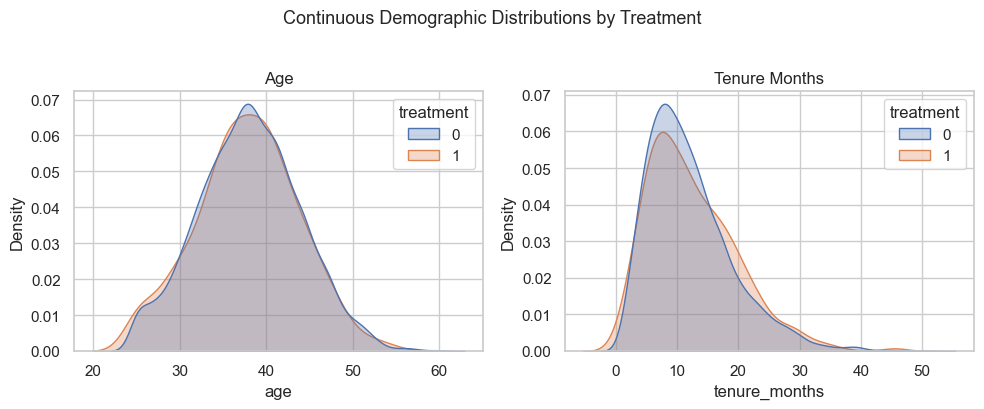

C:\Users\U1008500\AppData\Local\Temp\ipykernel_34804\3990226690.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


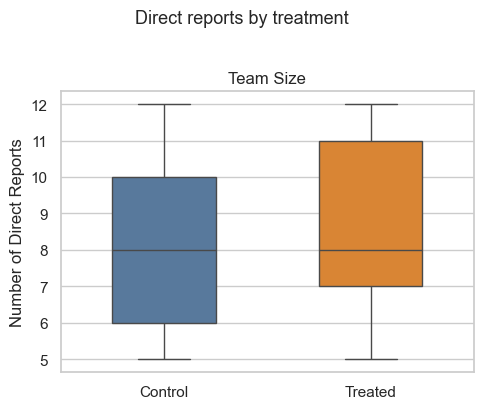

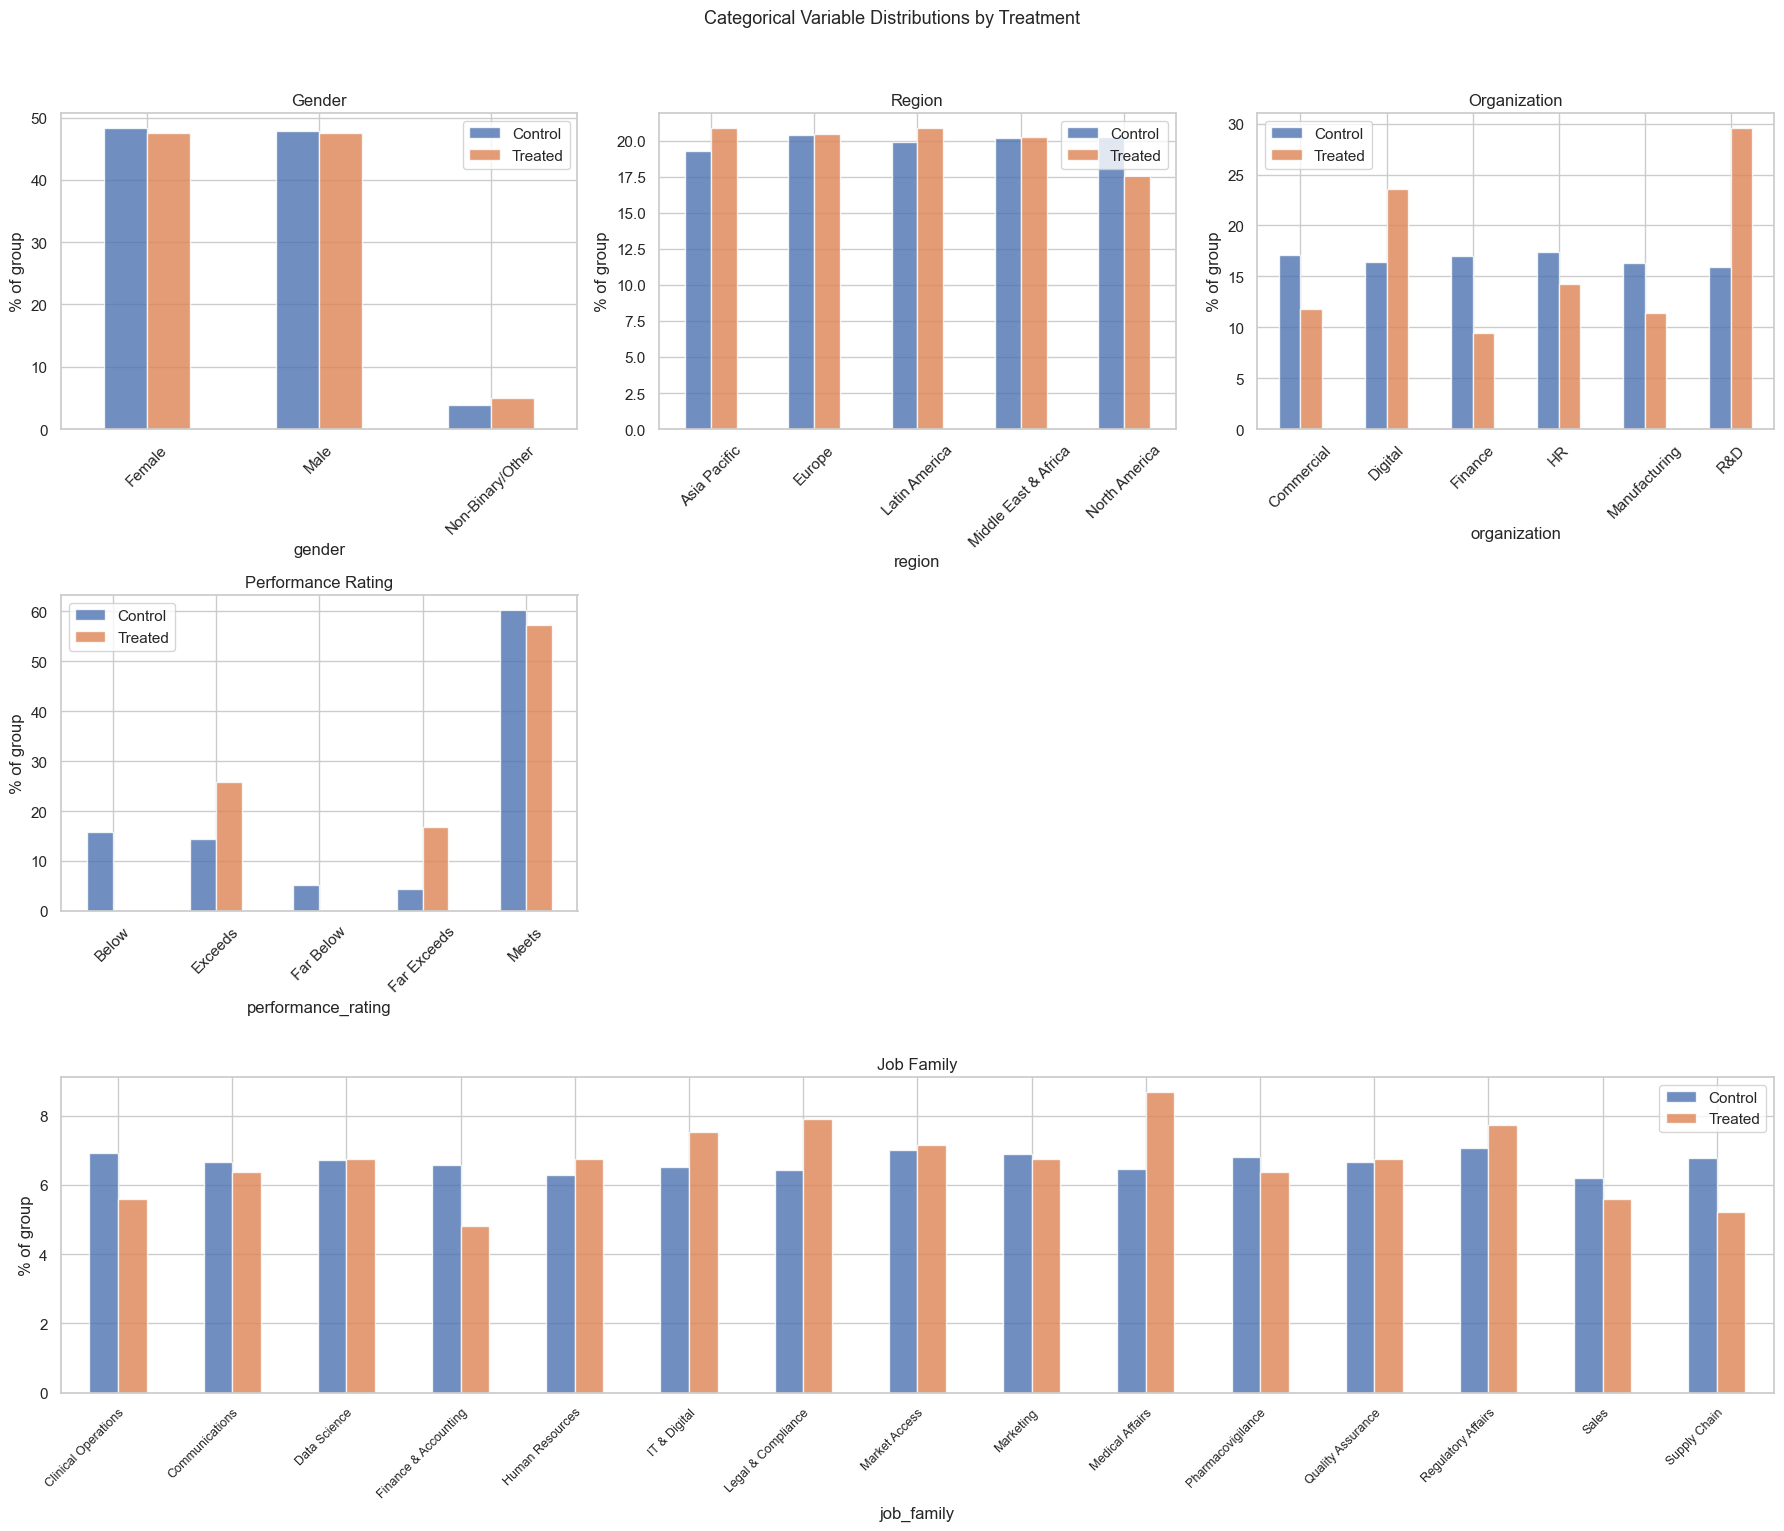

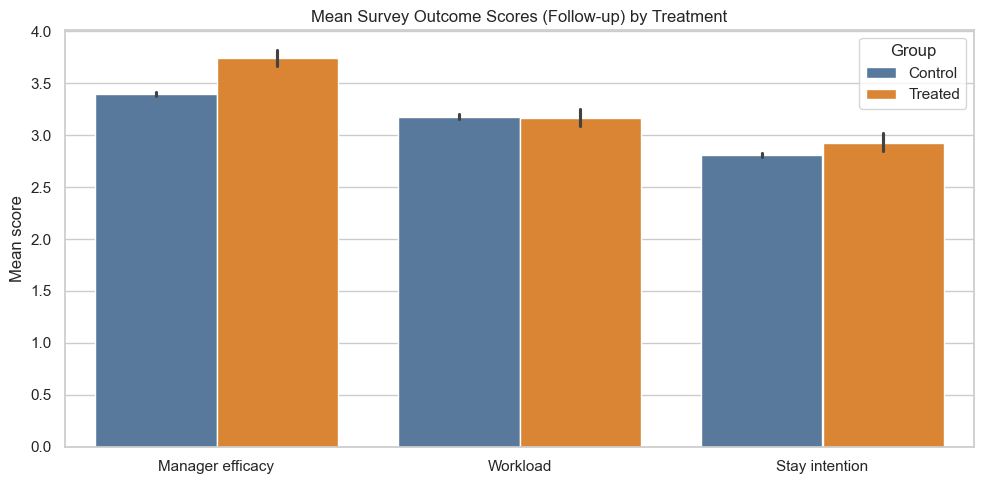

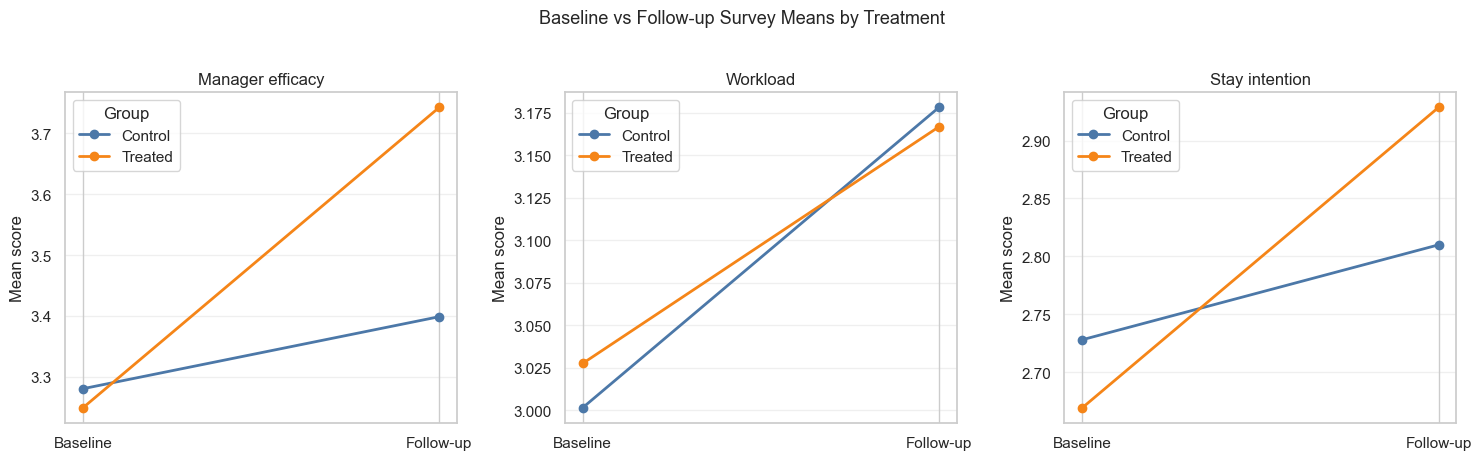

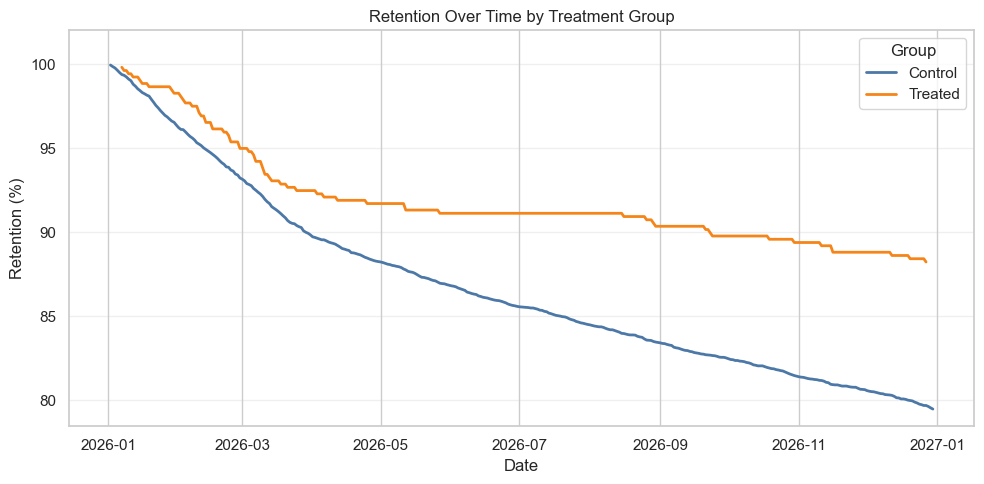

In [4]:
#@title DESCRIPTIVE EXPLORATION
# =============================================================================
# Compare outcomes for treated vs control, and explore potential confounders


def run_descriptive_comparison(data, treatment_col="treatment"):
    """Run demographic comparison between treated and control groups."""
    continuous_outcomes = [
        c for c in ["manager_efficacy_index", "workload_index_mgr", "stay_intention_index_mgr"]
        if c in data.columns
    ]
    binary_outcomes = [
        c for c in ["retention_3month", "retention_6month", "retention_9month", "retention_12month"]
        if c in data.columns
    ]
    baseline_cols = [
        c for c in ["baseline_manager_efficacy", "baseline_workload",
                    "baseline_stay_intention", "baseline_manager_support"]
        if c in data.columns
    ]

    demo_continuous = [c for c in ["age", "tenure_months"] if c in data.columns]
    demo_num = baseline_cols + demo_continuous + [c for c in ["num_direct_reports", "tot_span_of_control"] if c in data.columns]
    demo_cat = [
        c for c in ["gender", "region", "organization", "job_family", "performance_rating"]
        if c in data.columns
    ]

    print("=" * 60)
    print("BASELINE DEMOGRAPHIC & SURVEY COMPARISON: Treated vs Control")
    print("=" * 60)

    if demo_num:
        demo_means = data.groupby(treatment_col)[demo_num].mean().T
        demo_means.columns = ["Control", "Treated"]
        demo_means["Diff (T - C)"] = demo_means["Treated"] - demo_means["Control"]

        # Statistical tests for continuous/numeric variables
        p_values = []
        for col in demo_num:
            ctrl_vals = data.loc[data[treatment_col] == 0, col].dropna()
            treat_vals = data.loc[data[treatment_col] == 1, col].dropna()
            # Use Welch's t-test (does not assume equal variances)
            _, p = stats.ttest_ind(ctrl_vals, treat_vals, equal_var=False)
            p_values.append(p)
        demo_means["p-value"] = p_values
        demo_means["Sig. at 95%"] = demo_means["p-value"].apply(
            lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
        )
        display(demo_means.round(3))

    if demo_cat:
        print("\n" + "-" * 60)
        for col in demo_cat:
            ct = pd.crosstab(data[col], data[treatment_col])
            ct.columns = ["Control", "Treated"]

            ct_pct = ct.div(ct.sum(axis=0), axis=1) * 100
            ct_pct.columns = ["Control %", "Treated %"]
            ct_pct["Diff (pp)"] = ct_pct["Treated %"] - ct_pct["Control %"]

            # Chi-squared test of independence
            chi2, p_val, dof, _ = stats.chi2_contingency(ct.values)
            sig_label = "***" if p_val < 0.001 else ("**" if p_val < 0.01 else ("*" if p_val < 0.05 else "not significantly"))
            print(f"\n{col}  —  χ² test to determine whether distributions differ among T & C = {chi2:.2f}, df = {dof}, p = {p_val:.4f} {sig_label}")
            display(ct_pct.round(1))

    n_cont = len(demo_continuous)
    if n_cont:
        fig, axes = plt.subplots(1, n_cont, figsize=(5 * n_cont, 4))
        if n_cont == 1:
            axes = [axes]
        for ax, col in zip(axes, demo_continuous):
            sns.kdeplot(
                data=data,
                x=col,
                hue=treatment_col,
                common_norm=False,
                fill=True,
                alpha=0.3,
                ax=ax,
            )
            ax.set_title(col.replace("_", " ").title())
        plt.suptitle("Continuous Demographic Distributions by Treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    special_plots = []
    if "num_direct_reports" in data.columns:
        special_plots.append("num_direct_reports")


    if special_plots:
        fig, axes = plt.subplots(1, len(special_plots), figsize=(5 * len(special_plots), 4))
        if len(special_plots) == 1:
            axes = [axes]
        plot_df_special = data.copy()
        plot_df_special["treatment_label"] = plot_df_special[treatment_col].map({0: "Control", 1: "Treated"})
        for ax, col in zip(axes, special_plots):
            if col == "num_direct_reports":
                sns.boxplot(
                    data=plot_df_special,
                    x="treatment_label",
                    y=col,
                    ax=ax,
                    order=["Control", "Treated"],
                    palette={"Control": "#4C78A8", "Treated": "#F58518"},
                    width=0.5,
                )
                ax.set_xlabel("")
                ax.set_ylabel("Number of Direct Reports")
                ax.set_title("Team Size")
        plt.suptitle("Direct reports by treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    n_cat = len(demo_cat)
    if n_cat:
        other_cats = [col for col in demo_cat if col != "job_family"]
        n_other = len(other_cats)

        n_cols = 3
        n_rows = math.ceil(min(n_other, 6) / n_cols)

        fig = plt.figure(figsize=(18, 5 * (n_rows + 1)))
        gs = GridSpec(n_rows + 1, n_cols, height_ratios=[1] * n_rows + [1])

        for i, col in enumerate(other_cats[:n_rows * n_cols]):
            ax = fig.add_subplot(gs[i // n_cols, i % n_cols])
            ct_pct = pd.crosstab(data[col], data[treatment_col], normalize="columns") * 100
            ct_pct.columns = ["Control", "Treated"]
            ct_pct.plot(kind="bar", ax=ax, alpha=0.8)
            ax.set_title(col.replace("_", " ").title())
            ax.set_ylabel("% of group")
            ax.legend(title="")
            ax.tick_params(axis="x", rotation=45)

        if "job_family" in demo_cat:
            ax_job = fig.add_subplot(gs[n_rows, :])
            ct_pct = pd.crosstab(data["job_family"], data[treatment_col], normalize="columns") * 100
            ct_pct.columns = ["Control", "Treated"]
            ct_pct.plot(kind="bar", ax=ax_job, alpha=0.8)
            ax_job.set_title("Job Family")
            ax_job.set_ylabel("% of group")
            ax_job.legend(title="")
            ax_job.tick_params(axis="x", rotation=45, labelsize=9)
            ax_job.set_xticklabels(ax_job.get_xticklabels(), ha="right", rotation_mode="anchor")

        plt.suptitle("Categorical Variable Distributions by Treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    outcome_baseline_pairs = [
        ("manager_efficacy_index", "baseline_manager_efficacy"),
        ("workload_index_mgr", "baseline_workload"),
        ("stay_intention_index_mgr", "baseline_stay_intention"),
    ]
    outcome_pairs = [
        (o, b) for o, b in outcome_baseline_pairs
        if o in continuous_outcomes and b in data.columns
    ]
    outcome_labels = {
        "manager_efficacy_index": "Manager efficacy",
        "workload_index_mgr": "Workload",
        "stay_intention_index_mgr": "Stay intention",
    }

    if continuous_outcomes:
        plot_long = data[[treatment_col] + continuous_outcomes].melt(
            id_vars=[treatment_col],
            var_name="outcome",
            value_name="score",
        )
        plot_long["outcome_label"] = plot_long["outcome"].map(outcome_labels)
        plot_long["Group"] = plot_long[treatment_col].map({0: "Control", 1: "Treated"})
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.barplot(
            data=plot_long,
            x="outcome_label",
            y="score",
            hue="Group",
            hue_order=["Control", "Treated"],
            palette={"Control": "#4C78A8", "Treated": "#F58518"},
            ax=ax,
            errorbar=("ci", 95),
        )
        ax.set_title("Mean Survey Outcome Scores (Follow-up) by Treatment")
        ax.set_xlabel("")
        ax.set_ylabel("Mean score")
        ax.legend(title="Group")
        plt.tight_layout()
        plt.show()

    if outcome_pairs:
        n_out = len(outcome_pairs)
        fig, axes = plt.subplots(1, n_out, figsize=(5 * n_out, 4.5))
        if n_out == 1:
            axes = [axes]
        for ax, (outcome, baseline_col) in zip(axes, outcome_pairs):
            for trt, label, color in [(0, "Control", "#4C78A8"), (1, "Treated", "#F58518")]:
                sub = data.loc[data[treatment_col] == trt]
                y0 = sub[baseline_col].mean()
                y1 = sub[outcome].mean()
                ax.plot([0, 1], [y0, y1], marker="o", linewidth=2, label=label, color=color)
            ax.set_xticks([0, 1])
            ax.set_xticklabels(["Baseline", "Follow-up"])
            ax.set_ylabel("Mean score")
            ax.set_title(outcome_labels.get(outcome, outcome.replace("_", " ").title()))
            ax.legend(title="Group")
            ax.grid(axis="y", alpha=0.3)
        plt.suptitle("Baseline vs Follow-up Survey Means by Treatment", y=1.02, fontsize=13)
        plt.tight_layout()
        plt.show()

    if "exit_date" in data.columns:
        exit_dates = pd.to_datetime(data["exit_date"], errors="coerce")
        retention_lines = []
        for trt, label, color in [(0, "Control", "#4C78A8"), (1, "Treated", "#F58518")]:
            mask = data[treatment_col] == trt
            n_group = mask.sum()
            dates = exit_dates[mask].dropna().sort_values()
            if n_group == 0 or dates.empty:
                continue
            daily_departures = dates.dt.normalize().value_counts().sort_index().cumsum()
            idx = pd.date_range(daily_departures.index.min(), daily_departures.index.max(), freq="D")
            daily_departures = daily_departures.reindex(idx, method="ffill").fillna(0)
            retention_pct = (1 - daily_departures / n_group) * 100
            retention_lines.append((label, color, retention_pct))

        if retention_lines:
            fig, ax = plt.subplots(figsize=(10, 5))
            for label, color, series in retention_lines:
                ax.plot(series.index, series.values, label=label, color=color, linewidth=2)
            ax.set_xlabel("Date")
            ax.set_ylabel("Retention (%)")
            ax.set_title("Retention Over Time by Treatment Group")
            ax.legend(title="Group")
            ax.set_ylim(None, 102)
            ax.grid(axis="y", alpha=0.3)
            plt.tight_layout()
            plt.show()


run_descriptive_comparison(data)


#### Positivity Violation: No Low Performers in the Treated Group

We observe that **zero managers rated "Far Below" or "Below" completed the training program.** This is a **positivity violation** — for this subgroup, the probability of treatment is exactly zero: $P(T=1 \mid \text{performance} \in \{\text{Far Below, Below}\}) = 0$.

This means we **cannot estimate the treatment effect for low performers** because there are no treated low performers to learn from. No statistical method can fix this — it is a fundamental data (program set-up) limitation.

**Our decision:** We exclude low performers from the analysis. This is a defensible response to positivity violations, but it has an important consequence: **our ATE now applies only to average-and-above performers.** If L&D scales this program to include low performers, our estimates are not informative about potential effects for this subgroup.

This is an **estimand-scoping decision**, not a data-cleaning step. It should be documented in any report and flagged as a limitation.

After exclusion: 7220 managers remain
treatment
0    6702
1     518
dtype: int64
BASELINE DEMOGRAPHIC & SURVEY COMPARISON: Treated vs Control


,Control,Treated,Diff (T - C),p-value,Sig. at 95%
baseline_manager_efficacy,3.281,3.249,-0.032,0.393,
baseline_workload,3.004,3.028,0.024,0.568,
baseline_stay_intention,2.729,2.669,-0.059,0.148,
age,38.072,37.790,-0.282,0.297,
tenure_months,11.947,12.498,0.551,0.098,
num_direct_reports,8.463,8.571,0.108,0.295,
tot_span_of_control,18.329,18.554,0.225,0.532,



------------------------------------------------------------

gender  —  χ² test to determine whether distributions differ among T & C = 2.08, df = 2, p = 0.3527 not significantly


,Control %,Treated %,Diff (pp)
gender,,,
Female,48.5,47.5,-1.0
Male,47.8,47.5,-0.3
Non-Binary/Other,3.8,5.0,1.3



region  —  χ² test to determine whether distributions differ among T & C = 3.01, df = 4, p = 0.5559 not significantly


...

,Control %,Treated %,Diff (pp)
organization,,,
Commercial,17.3,11.8,-5.5
Digital,16.1,23.6,7.4
Finance,16.9,9.5,-7.4
HR,17.5,14.3,-3.2
Manufacturing,16.7,11.4,-5.3
R&D,15.5,29.5,14.0



job_family  —  χ² test to determine whether distributions differ among T & C = 11.95, df = 14, p = 0.6105 not significantly


,Control %,Treated %,Diff (pp)
job_family,,,
Clinical Operations,6.8,5.6,-1.2
Communications,6.4,6.4,-0.0
Data Science,6.5,6.8,0.2
Finance & Accounting,6.7,4.8,-1.9
Human Resources,6.4,6.8,0.3
IT & Digital,6.5,7.5,1.0
Legal & Compliance,6.5,7.9,1.4
Market Access,7.1,7.1,0.1
Marketing,6.8,6.8,-0.1



performance_rating  —  χ² test to determine whether distributions differ among T & C = 135.25, df = 2, p = 0.0000 ***


,Control %,Treated %,Diff (pp)
performance_rating,,,
Exceeds,18.3,25.9,7.6
Far Exceeds,5.5,16.8,11.3
Meets,76.2,57.3,-18.9


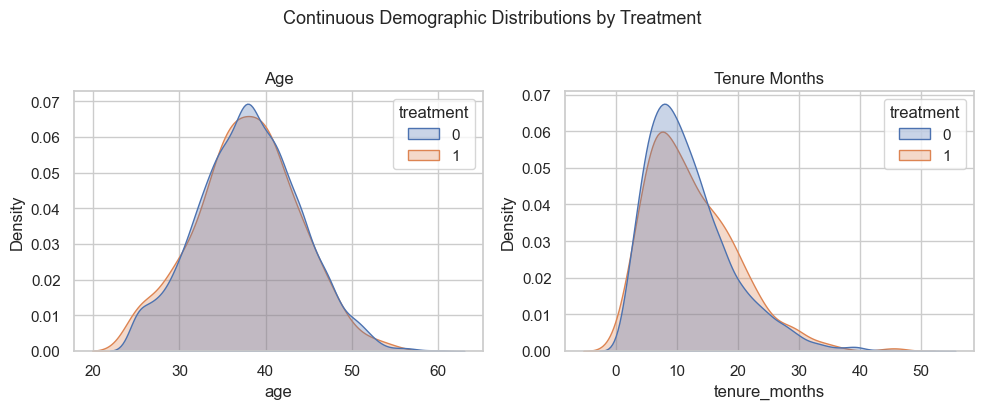

C:\Users\U1008500\AppData\Local\Temp\ipykernel_34804\3990226690.py:101: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


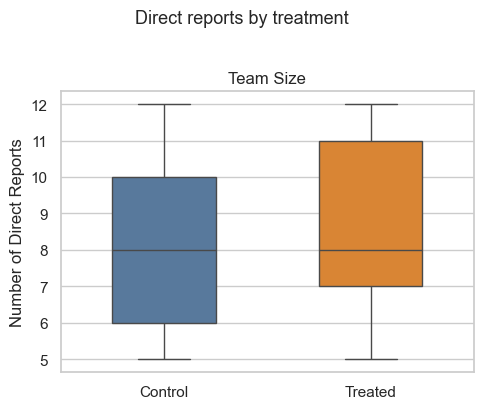

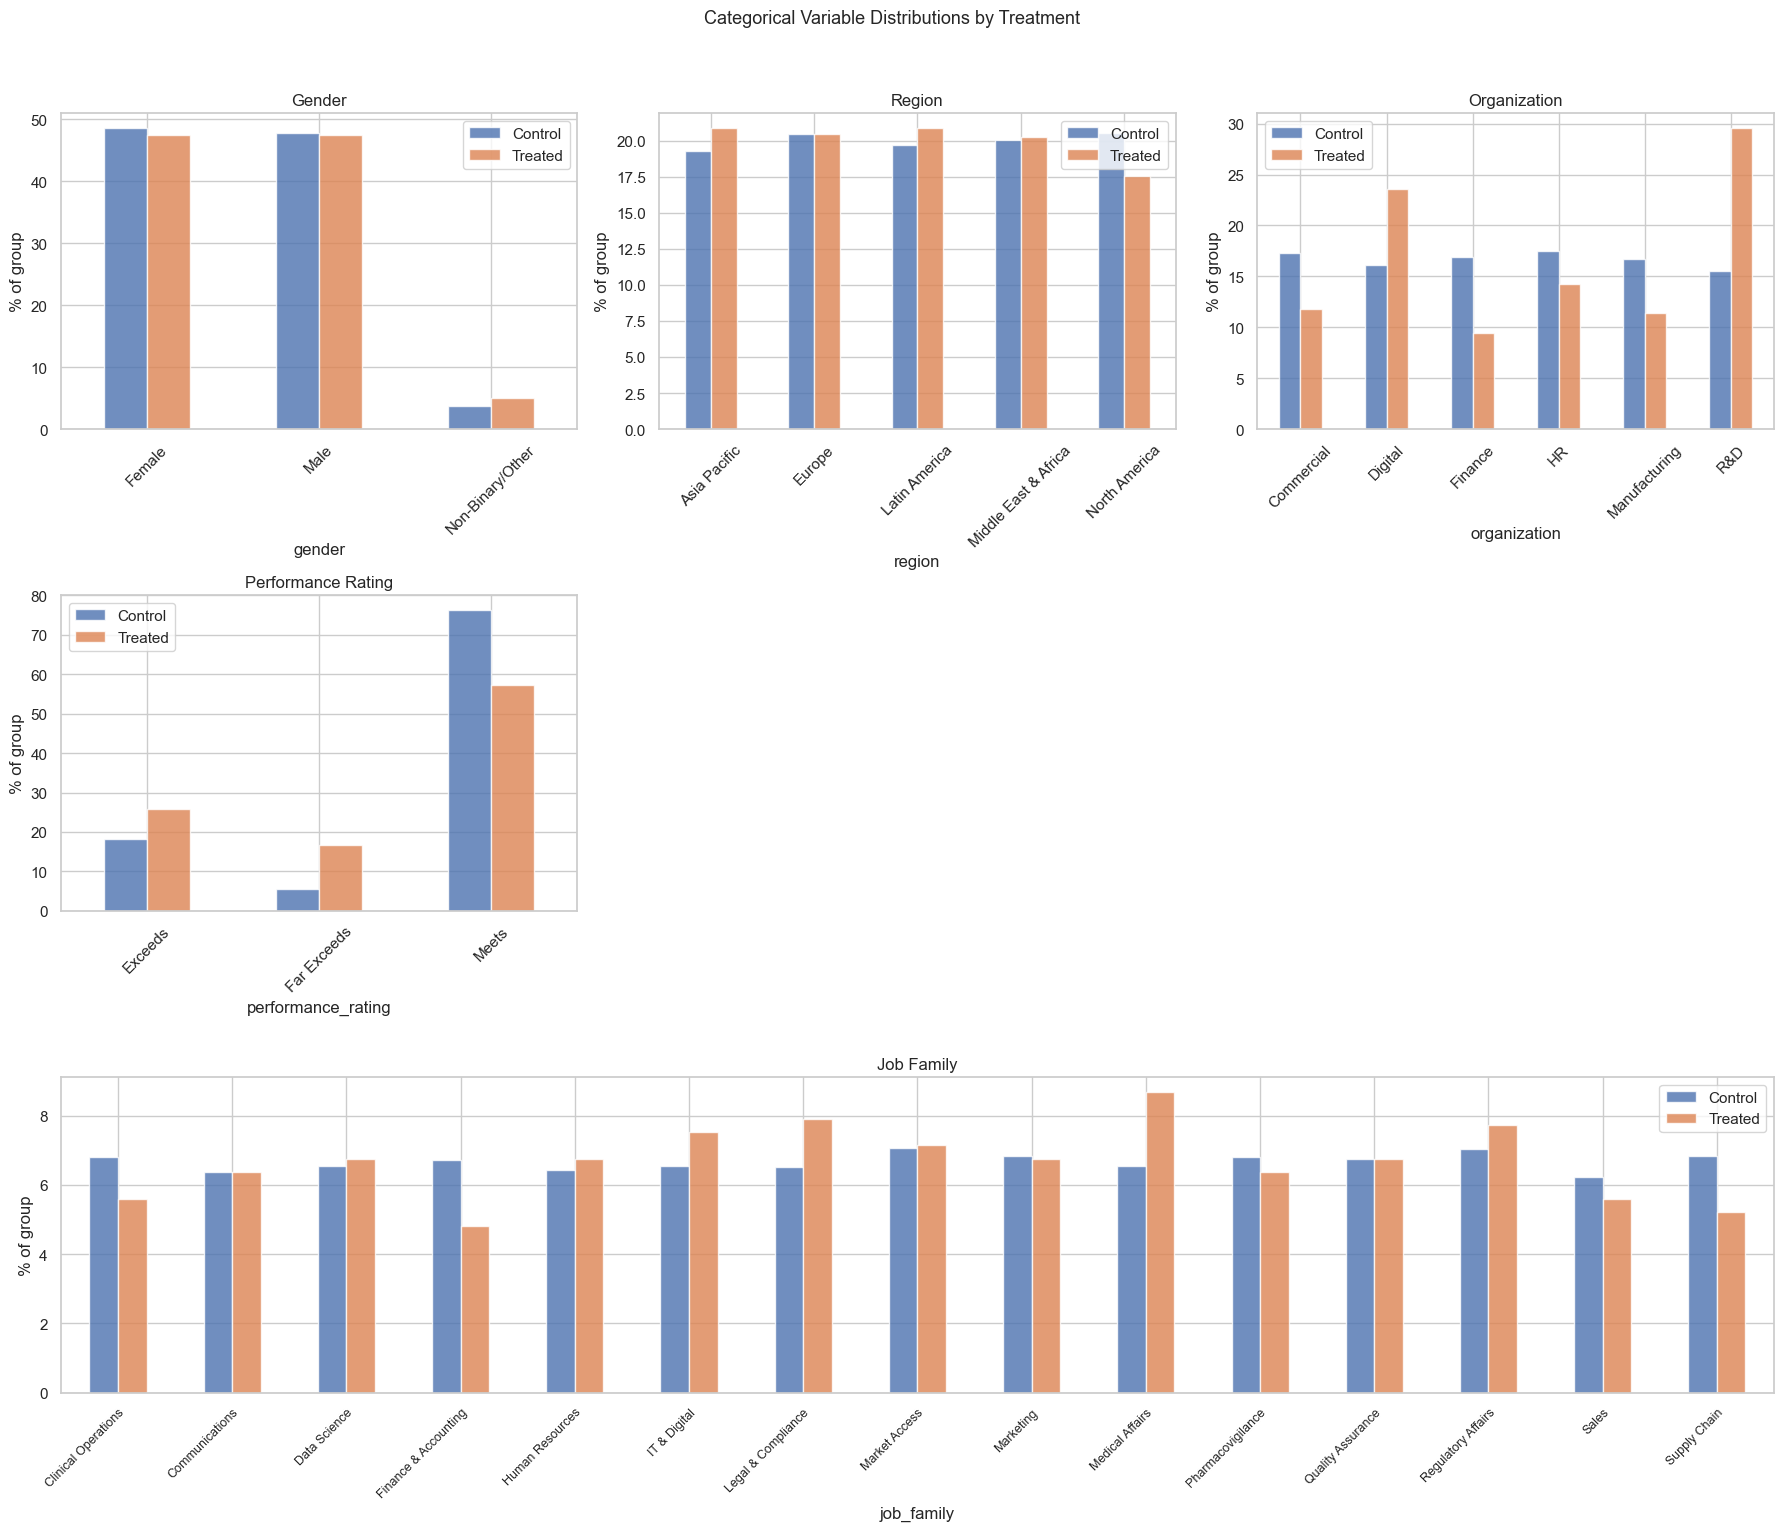

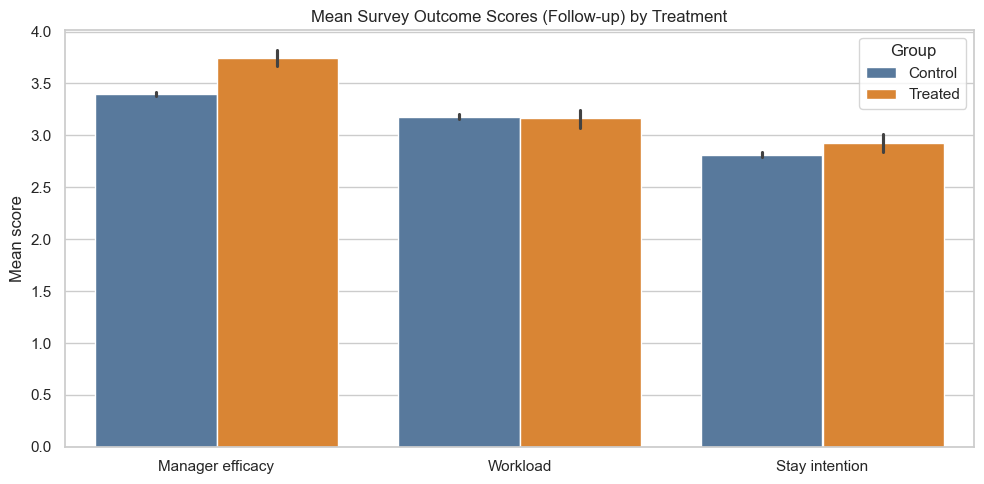

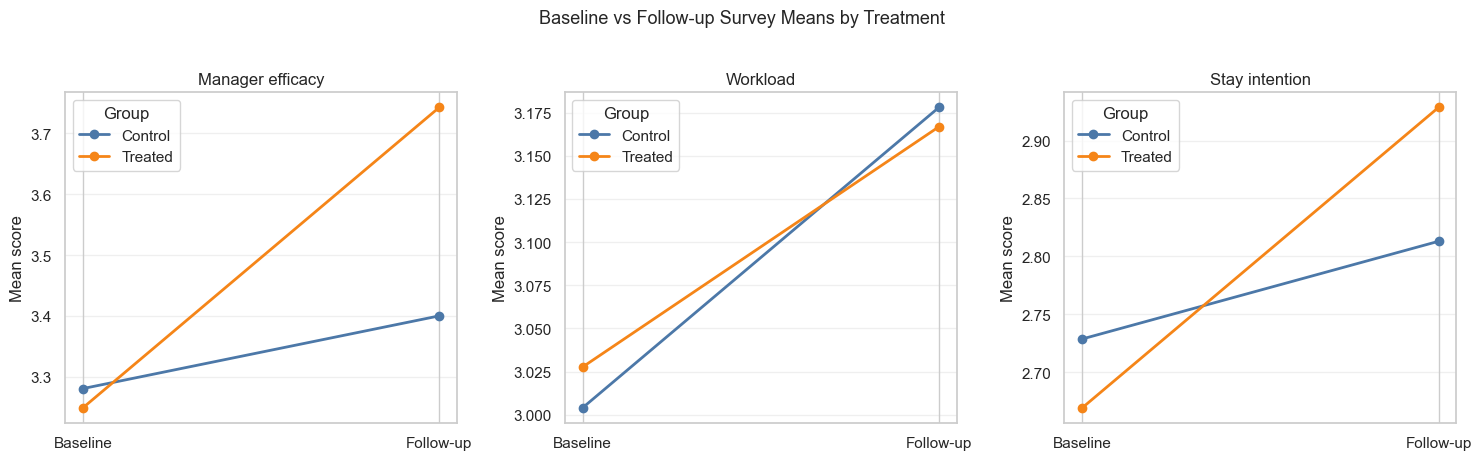

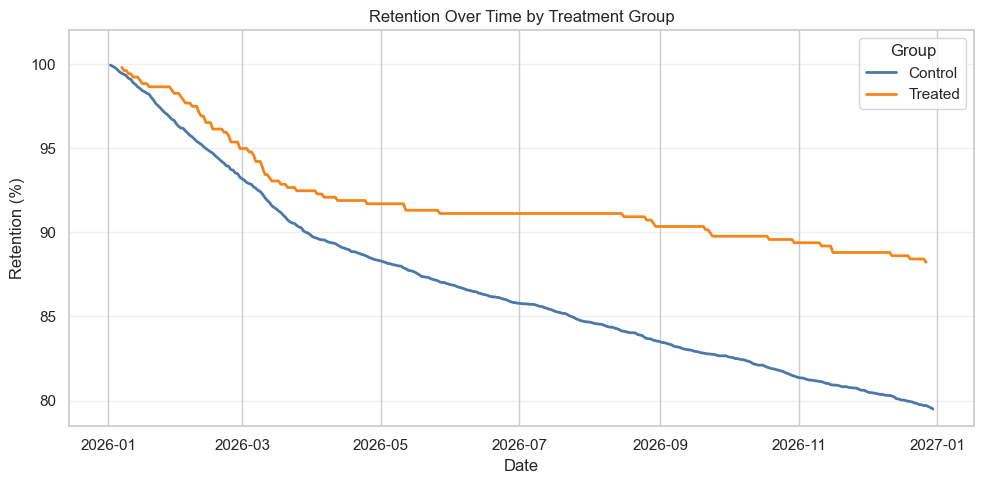

In [5]:
#@title Exclude low performers (positivity violation — see discussion above)
data = data[~data["performance_rating"].isin(["Far Below", "Below"])].copy().reset_index(drop=True)
print(f"After exclusion: {data.shape[0]} managers remain")
print(data.groupby("treatment").size())

# Re-run descriptives on restricted sample
run_descriptive_comparison(data)

### Summary: Checkpoint 1

In [6]:
#@title HTML: Summary CP1
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; background: #007bff; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
</style>

<div id="slideshow_cp1">
    <div class="slide-container">

        <div class="slide active">
            <div class="checkpoint-layout">

                <!-- Left: Image -->
                <div class="checkpoint-left">
                    <img src="./diagrams/checkpoint1.png" alt="Checkpoint 1 Diagram">
                </div>

                <!-- Right: Content -->
                <div class="checkpoint-right">
                    <span class="tag">Checkpoint 1</span>
                    <h2>Research Design & Data Exploration</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Documented assumptions with a DAG aligned to our research question</div>
                    <div class="achievement-box">✅ Conducted best practice data hygiene checks and exploratory analysis</div>

                    <div class="section-label" style="margin-top: 15px;">Key Research Questions</div>
                    <div class="takeaway-box">
                        Does manager training impact <strong>self-reported efficacy, workload, or stay intention</strong>? Does it impact <strong>actual retention</strong>?
                    </div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>Clean data:</strong> No missing data, no repeats, no improbable values.
                    </div>
                    <div class="takeaway-box">
                        <strong>Some imbalance</strong> observed between Treatment and Control for Organization.
                    </div>
                    <div class="takeaway-box">
                        <strong>Problematic imbalance for performance:</strong> No low-performing managers signed up for training → <strong>low performers removed from analysis population</strong>.
                    </div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_cp1"></div>

    <div class="controls">
        <button class="nav-btn-cp1" data-dir="-1">← Previous</button>
        <span id="counter_cp1">1 / 1</span>
        <button class="nav-btn-cp1" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_cp1');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_cp1');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_cp1').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const btn = e.target.closest('.nav-btn-cp1');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

---

## Checkpoint 2: Diagnostics & Causal Identification Strategy

<img src="./diagrams/checkpoint2.png" width = "400" alt="Alt text">

In [7]:
#@title HTML: ESTIMAND SELECTION
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 30px 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 12px; font-size: 22px; }
    .slide h3 { color: #34495e; margin: 12px 0 6px 0; font-size: 16px; }
    .slide p { line-height: 1.5; margin-bottom: 10px; font-size: 14px; }
    .slide table { width: 100%; border-collapse: collapse; margin: 12px 0; font-size: 13px; }
    .slide th, .slide td { border: 1px solid #ddd; padding: 10px; text-align: left; }
    .slide th { background-color: #f8f9fa; font-weight: bold; }
    .slide ul { margin: 8px 0; padding-left: 22px; }
    .slide li { margin-bottom: 7px; line-height: 1.5; font-size: 14px; }

    .note { background-color: #fff3cd; padding: 10px 14px; border-left: 4px solid #ffc107; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .tip { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .definition-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff; margin: 8px 0; border-radius: 4px; font-size: 14px; }

    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 10px; }
    .tag-overview { background: #007bff; }
    .tag-comparison { background: #6f42c1; }
    .tag-decision { background: #28a745; }
    .tag-discuss { background: #dc3545; }
    .tag-sidenote { background: #fd7e14; }

    .return-toc { margin-top: 12px; padding-top: 12px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 12px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
    .toc-item.discuss { border-left-color: #dc3545; }
    .toc-item.discuss span { color: #dc3545; }
    .toc-item.sidenote { border-left-color: #fd7e14; }
    .toc-item.sidenote span { color: #fd7e14; }

    /* Discussion accordion */
    .discussion-item { margin-bottom: 12px; border: 1px solid #e0e0e0; border-radius: 6px; overflow: hidden; }
    .discussion-q { background: #f8f9fa; padding: 11px 16px; cursor: pointer; display: flex; justify-content: space-between; align-items: center; font-size: 14px; font-weight: bold; color: #2c3e50; user-select: none; }
    .discussion-q:hover { background: #e7f3ff; }
    .discussion-q .chevron { font-size: 12px; transition: transform 0.2s; color: #dc3545; }
    .discussion-q.open .chevron { transform: rotate(90deg); }
    .discussion-a { display: none; padding: 11px 16px; background: #fff8f8; border-top: 1px solid #f5c6cb; font-size: 13px; line-height: 1.6; color: #444; }
    .discussion-a.visible { display: block; }
    .discussion-a ul { margin: 6px 0; padding-left: 20px; }
    .discussion-a li { margin-bottom: 5px; font-size: 13px; }
</style>

<div id="slideshow_estimand">
    <div class="slide-container">

        <!-- Slide 1: TOC -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Choosing Our Estimand: ATE vs ATT</h2>
            <p>Before we can estimate a causal effect, we need to decide <strong>what effect</strong> we're trying to estimate. The choice depends on our research question and data structure.</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>ATE vs ATT Comparison</div>
                <div class="toc-item discuss" data-slide="2"><span>Slide 3</span>💬 Discussion: Our Context</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>Our Decision: ATE</div>
                <div class="toc-item sidenote" data-slide="4"><span>Slide 5</span>Side Note: IV Approach</div>
            </div>
        </div>

        <!-- Slide 2: ATE vs ATT Comparison -->
        <div class="slide">
            <span class="tag tag-comparison">Comparison</span>
            <h2>ATE vs ATT: Key Differences</h2>
            <table>
                <tr>
                    <th>Consideration</th>
                    <th>ATE</th>
                    <th>ATT</th>
                </tr>
                <tr>
                    <td><strong>Target population</strong></td>
                    <td>Full population (treated + untreated)</td>
                    <td>Only those who received treatment</td>
                </tr>
                <tr>
                    <td><strong>Research question</strong></td>
                    <td>"What if we rolled this out to everyone?"</td>
                    <td>"Did it work for those who participated?"</td>
                </tr>
                <tr>
                    <td><strong>Overlap requirement</strong></td>
                    <td>Strict: every covariate profile needs both treated and control</td>
                    <td>Relaxed: only need controls resembling the treated</td>
                </tr>
                <tr>
                    <td><strong>Typical use case</strong></td>
                    <td>Policy decisions about universal rollout</td>
                    <td>Evaluating voluntary/targeted programs</td>
                </tr>
                <tr>
                    <td><strong>When treated group is small</strong></td>
                    <td>Problematic — requires extrapolation</td>
                    <td>Natural fit — only generalizing to treated</td>
                </tr>
            </table>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: Discussion -->
        <div class="slide">
            <span class="tag tag-discuss">Discussion</span>
            <h2>💬 Discussion: Thinking Through Our Context</h2>
            <p style="font-size: 13px; color: #888; margin-bottom: 14px;">Click each question to reveal the discussion point.</p>

            <div class="discussion-item">
                <div class="discussion-q">
                    What is L&D's goal with this training program?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>L&D wants to <strong>train as many managers as possible</strong> — they're considering scaling this program</li>
                        <li>They need to know: <strong>"Should we roll this out to everyone?"</strong></li>
                        <li>This is a <strong>policy question</strong> about universal implementation, not just about self-selected participants</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    How did managers end up in the training program?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Voluntary participation</strong> — any manager who signed up could attend</li>
                        <li><strong>Uneven promotion</strong> — some departments actively encouraged participation, others sent a single email</li>
                        <li>This creates <strong>selection bias</strong> — motivated managers or those in supportive departments are more likely to participate</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Which estimand (ATE or ATT) matches our research question?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>ATE</strong> answers: "What would happen if we assigned training to everyone vs. no one?"</li>
                        <li><strong>ATT</strong> answers: "What happened for those who self-selected into training?"</li>
                        <li>Since L&D wants to scale to <em>all managers</em>, we need <strong>ATE</strong> — the population-level effect</li>
                        <li>ATT would only tell us about self-selected participants, not the broader population</li>
                    </ul>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Our Decision -->
        <div class="slide">
            <span class="tag tag-decision">Decision</span>
            <h2>Our Target Estimand: ATE</h2>
            
            <div class="definition-box">
                <strong>Our target estimand: ATE (Average Treatment Effect)</strong>
            </div>

            <p>Since L&D wants to scale training to all managers, we estimate the <strong>population-level effect</strong> — what would happen if we assigned training to everyone vs. no one?</p>

            <h3>Diagnostic Strategy:</h3>
            <ul>
                <li><strong>Goal:</strong> Determine if our data structure supports estimating ATE</li>
                <li><strong>If successful:</strong> We can estimate ATE</li>
                <li><strong>If not:</strong> We can still get useful insights from ATT (effect on self-selected participants)</li>
                <li><strong>Last resort:</strong> If data doesn't support causal inference, we're limited to descriptive analysis</li>
            </ul>

            <div class="tip">
                <strong>Next steps:</strong> We'll conduct diagnostics (overlap, balance, propensity score distribution) to assess whether ATE estimation is feasible with our data.
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Side Note -->
        <div class="slide">
            <span class="tag tag-sidenote">Side Note</span>
            <h2>Side Note: Encouragement Design & IV</h2>
            
            <p>The department-level variation in how actively the program was promoted resembles a natural <strong>encouragement design</strong>.</p>
            
            <h3>Potential IV Approach:</h3>
            <ul>
                <li>Departments that encouraged participation more strongly could serve as an <strong>instrument</strong></li>
                <li>Could estimate <strong>Local Average Treatment Effect (LATE)</strong> for compliers</li>
            </ul>

            <h3>Why We Won't Pursue This:</h3>
            <div class="note">
                The <strong>exclusion restriction is questionable</strong> — departments that actively promoted training likely differ in other ways (stronger learning culture, more supportive leadership, additional resources) that could independently influence outcomes.
            </div>
            
            <p><em>Worth keeping in mind for settings where more credibly exogenous encouragement exists.</em></p>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress_estimand"></div>

    <div class="controls">
        <button class="nav-btn-estimand" data-dir="-1">← Previous</button>
        <span id="counter_estimand">1 / 5</span>
        <button class="nav-btn-estimand" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_estimand');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_estimand');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_estimand').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            // Discussion Q toggle
            const q = e.target.closest('.discussion-q');
            if (q) {
                const answer = q.nextElementSibling;
                const isOpen = answer.classList.contains('visible');
                container.querySelectorAll('.discussion-a').forEach(a => a.classList.remove('visible'));
                container.querySelectorAll('.discussion-q').forEach(dq => dq.classList.remove('open'));
                if (!isOpen) { answer.classList.add('visible'); q.classList.add('open'); }
                return;
            }

            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) { slideIndex = parseInt(returnBtn.dataset.slide); showSlide(); return; }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) { slideIndex = parseInt(tocItem.dataset.slide); showSlide(); return; }

            const btn = e.target.closest('.nav-btn-estimand');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) { slideIndex = parseInt(dot.dataset.index); showSlide(); }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

Consideration,ATE,ATT
Target population,Full population (treated + untreated),Only those who received treatment
Research question,"""What if we rolled this out to everyone?""","""Did it work for those who participated?"""
Overlap requirement,Strict: every covariate profile needs both treated and control,Relaxed: only need controls resembling the treated
Typical use case,Policy decisions about universal rollout,Evaluating voluntary/targeted programs
When treated group is small,Problematic — requires extrapolation,Natural fit — only generalizing to treated


### Diagnostic Prep

In [8]:
#@title DIAGNOSTIC AND ANALYSIS PREP
###############################################

# Treatment variable
treatment = 'treatment'

# Survey outcome variables (continuous, with baselines)
survey_outcomes = [
    'manager_efficacy_index',
    'workload_index_mgr',
    'stay_intention_index_mgr',
]

# Baseline variables corresponding to each survey outcome
baseline_vars = {
    'manager_efficacy_index': 'baseline_manager_efficacy',
    'workload_index_mgr': 'baseline_workload',
    'stay_intention_index_mgr': 'baseline_stay_intention',
}

# Covariates (shared between survey and retention analyses)
categorical_vars = [
    'gender',
    'organization',
    'job_family',
    'performance_rating',
    'region'
]


continuous_vars = [
    'age',
    'tenure_months',
    'num_direct_reports',
    'tot_span_of_control'
]

print(f"Survey outcomes:    {survey_outcomes}")
print(f"Covariates:         {len(categorical_vars)} categorical, {len(continuous_vars)} continuous")

Survey outcomes:    ['manager_efficacy_index', 'workload_index_mgr', 'stay_intention_index_mgr']
Covariates:         5 categorical, 4 continuous


In [9]:
#@title Instantiate CausalDiagnostics and view help
cd = CausalDiagnostics()
cd.help()


🚨 CAUSAL INFERENCE TUTORIAL - DEVELOPMENT CODE DISCLAIMER 🚨
This code is provided for EDUCATIONAL PURPOSES ONLY as part of
a causal inference tutorial for I/O psychologists.

⚠️  IMPORTANT LIMITATIONS:
   • Active development code - may contain bugs
   • Not validated for production research use
   • Requires statistical supervision and verification


        ╔══════════════════════════════════════════════════════════════════════════════╗
        ║  CausalDiagnostics — Unified Causal Inference Diagnostic Toolkit             ║
        ╚══════════════════════════════════════════════════════════════════════════════╝

        Usage:
            from supp_functions.causal_diagnostics import CausalDiagnostics
            cd = CausalDiagnostics()

        ────────────────────────────────────────────────────────────────────────────────
        GROUP A: PRE-MODELING DIAGNOSTICS
        ────────────────────────────────────────────────────────────────────────────────

        1. check_high_inter

### Initial Diagnostics: Multicollinearity/VIF

When you include multiple covariates in a regression model (like the propensity score model), some of them may be highly correlated with each other. Why is it important: Multicollinearity doesn't bias your estimates, but it inflates the standard errors, making it harder to detect real effects and producing unstable coefficient estimates (especially when you work with smaller sample sizes - as usually the case in People Analytics). 

| Function | Purpose |
|----------|---------|
| `check_high_intercorrelations` | Flags pairs above threshold (default 0.7) using Pearson, Cramér's V, or η |
| `check_vif` | Assesses multicollinearity via VIF (continuous) and adjusted GVIF (categorical). VIF shows "How well can this variable be predicted by all the other variables in the model?" |

In [10]:
#@title Intercorrelation + VIF
#  Variables to exclude from pre-modeling checks (outcomes, IDs, treatment, extra retention columns)
retention_cols = [c for c in data.columns if c.startswith('retention_')]
exclude_from_diagnostics = (
    ['id', 'team_id', 'treatment', 'exit_date']
    + survey_outcomes
    + retention_cols
    + [v for v in baseline_vars.values() if v is not None]
)

# --- Check 1: Intercorrelations ---
print("=" * 60)
print("CHECK 1: INTERCORRELATIONS")
print("=" * 60)
intercorr = cd.check_high_intercorrelations(
    data,
    numerical_threshold=0.7,
    categorical_threshold=0.7,
    verbose=True,
    exclude_vars=exclude_from_diagnostics,
)
if not intercorr['all_high_correlation_pairs']:
    print("✅ No highly correlated pairs found.")
else:
    print(f"⚠️ Found {len(intercorr['all_high_correlation_pairs'])} highly correlated pair(s).")

# --- Check 2: Variance Inflation Factor (VIF) ---
print("\n" + "=" * 60)
print("CHECK 2: VARIANCE INFLATION FACTOR (VIF)")
print("=" * 60)
controls_for_vif = categorical_vars + continuous_vars
vif_results = cd.check_vif(
    data,
    controls=controls_for_vif,
    treatment='treatment',
)
display(vif_results)

CHECK 1: INTERCORRELATIONS
✅ No highly correlated pairs found.

CHECK 2: VARIANCE INFLATION FACTOR (VIF)


,Variable,Type,VIF / GVIF,Adjusted (GVIF^1/2df),Shared Variance,Severity
0,tot_span_of_control,Continuous,1.1177,1.1177,<25% of variance is shared,✅ None
1,num_direct_reports,Continuous,1.1144,1.1144,<25% of variance is shared,✅ None
2,treatment,Continuous,1.0381,1.0381,<25% of variance is shared,✅ None
3,performance_rating,Categorical (2 dummies),1.0292,1.0072,<25% of variance is shared,✅ None
4,tenure_months,Continuous,1.0059,1.0059,<25% of variance is shared,✅ None
5,age,Continuous,1.0053,1.0053,<25% of variance is shared,✅ None
6,organization,Categorical (5 dummies),1.0322,1.0032,<25% of variance is shared,✅ None
7,gender,Categorical (2 dummies),1.0074,1.0018,<25% of variance is shared,✅ None
8,region,Categorical (4 dummies),1.0135,1.0017,<25% of variance is shared,✅ None
9,job_family,Categorical (14 dummies),1.0369,1.0013,<25% of variance is shared,✅ None


### Overlap Diagnostics

<img src="./diagrams/DiagnosticFlow.png" width = "1000" alt="Alt text">

In [11]:
#@title Run Overlap Diagnostics
# ===========================================================================================================================================
# PRE-MODELING DIAGNOSTICS : IS CAUSAL COMPARISON CREDIBLE, AND WHAT ESTIMAND IS DEFENSIBLE?
# 1. Overlap Diagnostics: Do the treatment and control groups have sufficient overlap in covariate distributions?
# 2. Based on the diagnostics, determine if the data supports a credible causal comparison.
# ===========================================================================================================================================
# Note: The propensity score model depends on covariates + treatment (not the outcomes). 
# Below, we run it here once for the 3 survey outcomes, because, depending on the outcome, we are using a different baseline variable as a covariate (that needs to be checked for balance). 
# The approach will be identical for the retention analysis.

overlap_results = cd.run_overlap_diagnostics(
    data=data,
    treatment_var=treatment,
    outcome_vars=survey_outcomes,
    baseline_vars=baseline_vars,
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars
)


STEP 2: OVERLAP / COMMON SUPPORT DIAGNOSTICS

    This step determines WHICH ESTIMAND (ATT vs ATE) is credible in your data.

    KEY CONCEPTS:
    - ATT (Average Treatment Effect on the Treated): Effect for those who got treatment
    → Requires: Good overlap for TREATED units (each treated has comparable controls)

    - ATE (Average Treatment Effect): Effect if we treated everyone
    → Requires: Good overlap BOTH directions (treated exist across control range too)

    With imbalanced samples, ATT is typically the credible estimand because
    many controls sit in regions where no treated units exist.

    We'll check overlap for each outcome (since adjustment sets include different baselines).
        
DETAILED DIAGNOSTICS
Checks 1A–1C (continuous, binary, categorical SMDs) are identical
across outcomes. Only baseline check (1D) and propensity-score model
(Check 2) vary by outcome due to outcome-specific baseline variables.
Showing full detail for first outcome: manager_efficacy_

,Outcome,AUC,Treated Overlap %,Control Overlap %,Max |SMD| (Source),Baseline Balance,Imbalanced Vars,Estimand,Rationale
0,manager_efficacy_index,0.657,87.8,93.9,0.402 (performance_rating),✓ Good (0.039),performance_rating (0.40); organization (0.34),ATE,Strong bidirectional overlap; ATE fully defens...
1,workload_index_mgr,0.658,89.4,93.1,0.402 (performance_rating),✓ Good (0.026),performance_rating (0.40); organization (0.34),ATE,Strong bidirectional overlap; ATE fully defens...
2,stay_intention_index_mgr,0.662,88.6,93.5,0.402 (performance_rating),✓ Good (0.064),performance_rating (0.40); organization (0.34),ATE,Strong bidirectional overlap; ATE fully defens...



INTERPRETATION GUIDE: WHAT THIS MEANS FOR YOUR ANALYSIS

    ╔══════════════════════════════════════════════════════════════════════════════╗
    ║  WHAT IS COVARIATE OVERLAP AND WHY DOES IT MATTER?                           ║
    ╠══════════════════════════════════════════════════════════════════════════════╣
    ║                                                                              ║
    ║  Causal inference requires COMPARABLE treatment and control groups.          ║
    ║  "Comparable" means: for each treated person, there exist control people     ║
    ║  with similar characteristics (covariates) who can serve as counterfactuals. ║
    ║                                                                              ║
    ║  If groups occupy DIFFERENT covariate spaces, we cannot observe what would   ║
    ║  have happened to treated people without treatment — we must EXTRAPOLATE.    ║
    ║                                                                              ║
    ║  

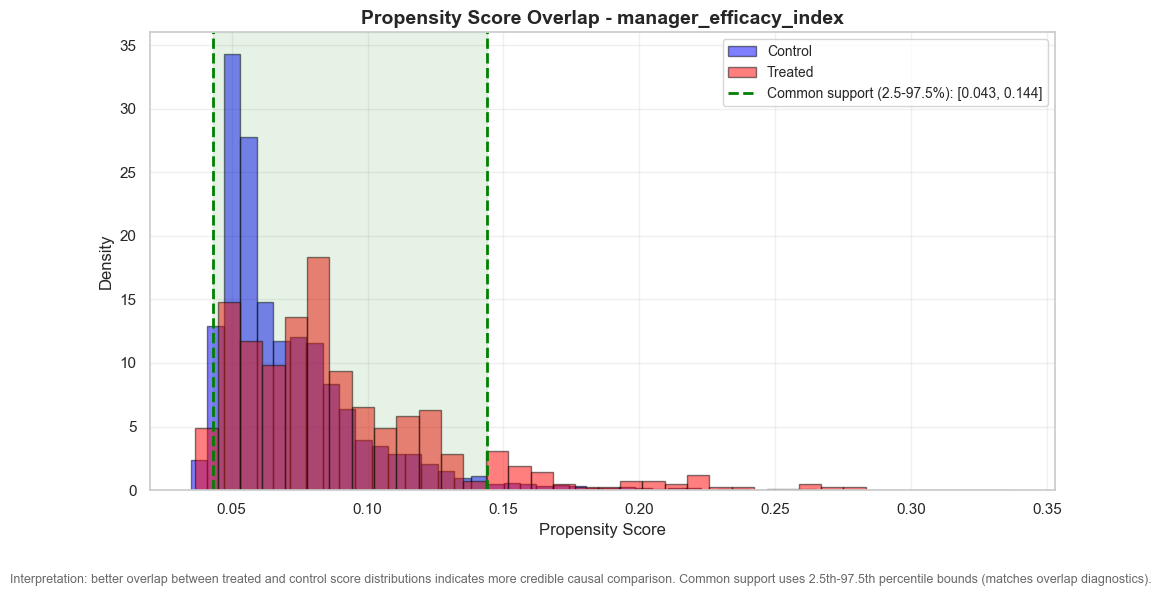

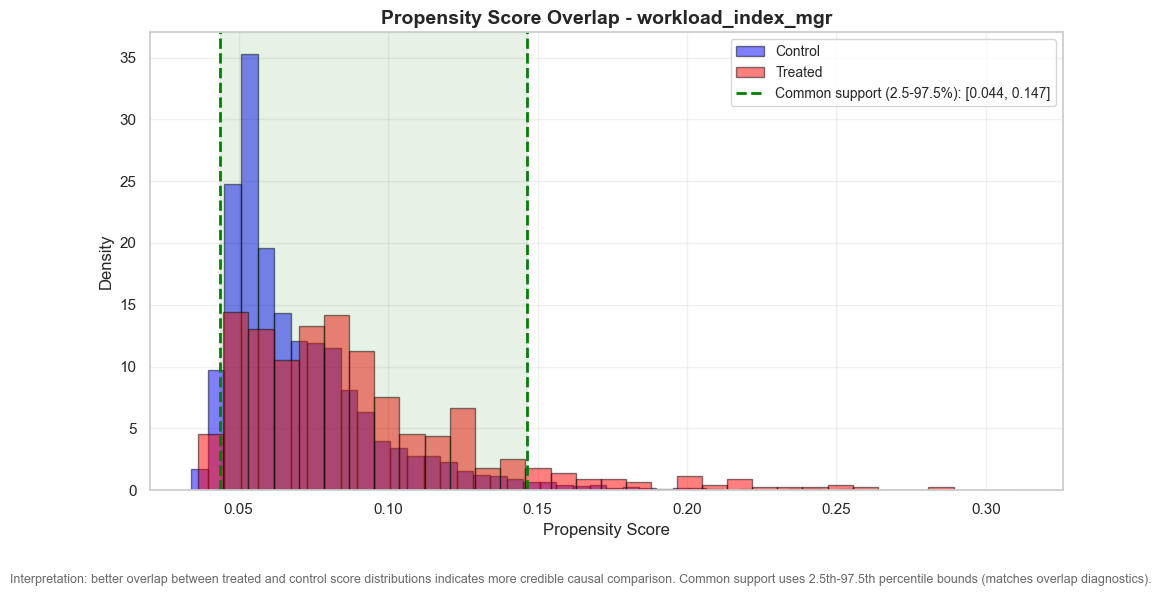

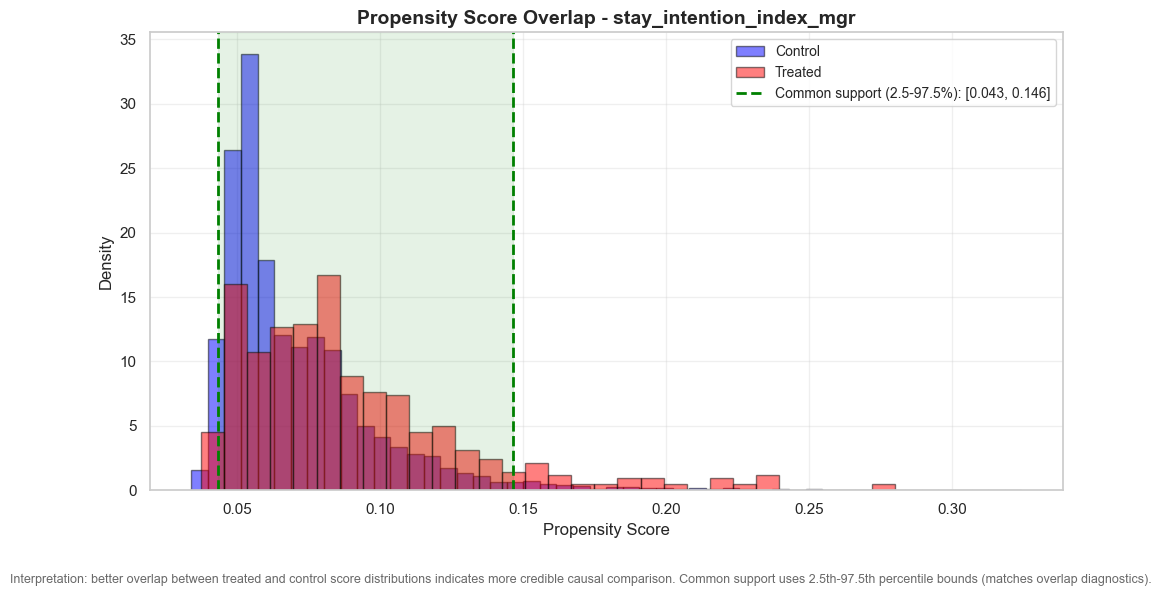

In [12]:
#@title Visualize propensity score overlap per survey outcome
# =============================================================================
for outcome_var in survey_outcomes:
    result = overlap_results.get(outcome_var)
    if result is None:
        continue

    ps = result.get('propensity_scores')
    if ps is not None:
        cd.plot_propensity_overlap(
            data=data,
            treatment_var=treatment,
            propensity_scores=ps,
            outcome_var=outcome_var,
        )

In [13]:
#@title Save overlap diagnostics summary
# =============================================================================
cd.save_overlap_diagnostics_summary(
    overlap_results,
    save_path=str(base_dir / "results/overlap_diagnostics_summary.txt"),
)


✓ Diagnostics summary saved to: c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\results\overlap_diagnostics_summary.txt


### Summary: Checkpoint 2

In [14]:
#@title HTML: Summary CP 2
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; background: #007bff; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
</style>

<div id="slideshow_cp1">
    <div class="slide-container">

        <div class="slide active">
            <div class="checkpoint-layout">

                <!-- Left: Image -->
                <div class="checkpoint-left">
                    <img src="./diagrams/checkpoint2.png" alt="Checkpoint 2 Diagram">
                </div>

                <!-- Right: Content -->
                <div class="checkpoint-right">
                    <span class="tag">Checkpoint 2</span>
                    <h2>Diagnostics & Causal Identification</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Determined our estimand of interest</div>
                    <div class="achievement-box">✅ Conducted diagnostics to assess credibility of causal inference and identify model stabilization strategies</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        After removing untreated low-performer controls, all diagnostics support a <strong>reasonable ATE estimate</strong>.
                    </div>
                    <div class="takeaway-box">
                        <strong>No concerning multicollinearity.</strong>
                    </div>
                    <div class="takeaway-box">
                        <strong>AUC &lt; 0.7</strong> with ~90% overlap in both directions — treatment and control groups are similar and treatment assignment is quasi-random. Covariates cannot fully predict treatment.
                    </div>
                    <div class="takeaway-box">
                        <strong>Moderate imbalance</strong> detected across region, performance categories, organization, and job family. Will be addressed via <strong>IPTW + GEE</strong>.
                    </div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_cp1"></div>

    <div class="controls">
        <button class="nav-btn-cp1" data-dir="-1">← Previous</button>
        <span id="counter_cp1">1 / 1</span>
        <button class="nav-btn-cp1" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_cp1');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_cp1');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_cp1').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const btn = e.target.closest('.nav-btn-cp1');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

## Checkpoint 3: Survey Modeling

<img src="./diagrams/checkpoint3.png" width = "600" alt="Alt text">

---

In [15]:
#@title HTML: Survey Outcome Modeling
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 30px 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 12px; font-size: 22px; }
    .slide h3 { color: #34495e; margin: 12px 0 6px 0; font-size: 16px; }
    .slide p { line-height: 1.5; margin-bottom: 10px; font-size: 14px; }
    .slide ul { margin: 8px 0; padding-left: 22px; }
    .slide li { margin-bottom: 7px; line-height: 1.5; font-size: 14px; }
    .slide ul ul { margin: 8px 0; }
    .slide ul ul li { margin-bottom: 6px; font-size: 13px; }
    .note { background-color: #fff3cd; padding: 10px 14px; border-left: 4px solid #ffc107; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .formula { background-color: #f8f9fa; padding: 12px; border-left: 4px solid #007bff; margin: 12px 0; font-size: 14px; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 10px; }
    .tag-overview { background: #007bff; }
    .tag-iptw { background: #6f42c1; }
    .tag-gee { background: #007bff; }
    .tag-other { background: #20c997; }
    .tag-discuss { background: #dc3545; }

    /* Overview layout */
    .overview-top { margin-bottom: 12px; }
    .overview-top p { font-size: 13px; margin-bottom: 6px; }
    .two-col { display: flex; gap: 12px; margin-top: 8px; }
    .model-col { flex: 1; }
    .model-header { color: white; padding: 8px 12px; border-radius: 6px 6px 0 0; font-weight: bold; font-size: 13px; }
    .model-header.iptw { background: #6f42c1; }
    .model-header.gee { background: #007bff; }
    .model-header small { display: block; font-weight: normal; font-size: 11px; opacity: 0.85; margin-top: 2px; }
    .toc-links { border: 2px solid #eee; border-top: none; border-radius: 0 0 6px 6px; padding: 6px; }
    .toc-link { display: block; padding: 5px 8px; font-size: 12px; border-radius: 4px; cursor: pointer;
                transition: all 0.2s ease; color: #333; margin-bottom: 3px; background: #f8f9fa; }
    .toc-link:last-child { margin-bottom: 0; }
    .toc-link:hover { transform: translateX(4px); }
    .toc-link.iptw-link:hover { background: #ede7f6; color: #6f42c1; }
    .toc-link.gee-link:hover { background: #e7f3ff; color: #007bff; }
    .toc-link.discuss-link { background: #fff8f8; border-left: 3px solid #dc3545; }
    .toc-link.discuss-link:hover { background: #ffe7e7; color: #dc3545; }
    .toc-link span { font-size: 10px; opacity: 0.6; margin-right: 4px; }

    .return-toc { margin-top: 12px; padding-top: 12px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    /* Discussion accordion */
    .discussion-item { margin-bottom: 12px; border: 1px solid #e0e0e0; border-radius: 6px; overflow: hidden; }
    .discussion-q { background: #f8f9fa; padding: 11px 16px; cursor: pointer; display: flex; justify-content: space-between; align-items: center; font-size: 14px; font-weight: bold; color: #2c3e50; user-select: none; }
    .discussion-q:hover { background: #e7f3ff; }
    .discussion-q .chevron { font-size: 12px; transition: transform 0.2s; color: #dc3545; }
    .discussion-q.open .chevron { transform: rotate(90deg); }
    .discussion-a { display: none; padding: 11px 16px; background: #fff8f8; border-top: 1px solid #f5c6cb; font-size: 13px; line-height: 1.6; color: #444; }
    .discussion-a.visible { display: block; }
    .discussion-a ul { margin: 6px 0; padding-left: 20px; }
    .discussion-a li { margin-bottom: 5px; font-size: 13px; }
</style>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div id="slideshow2">
    <div class="slide-container">

        <!-- Slide 1: Overview + ToC -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2 style="margin-bottom: 8px;">Survey Outcomes — IPTW + GEE: Estimating ATE</h2>

            <div class="overview-top">
                <p>Use this approach when treatment is <strong>not purely randomized</strong>, propensity scores are <strong>well-distributed</strong>, and weighted SMDs are <strong>acceptable</strong>. Our approach uses <strong>two complementary models</strong>:</p>
            </div>

            <div class="two-col">
                <!-- Model 1: IPTW -->
                <div class="model-col">
                    <div class="model-header iptw">
                        Model 1: Propensity Score → IPTW
                        <small>Purpose: Balance treatment groups on observed confounders</small>
                    </div>
                    <div class="toc-links">
                        <div class="toc-link iptw-link" data-slide="2"><span>Slide 3</span>Propensity Score Model</div>
                        <div class="toc-link iptw-link" data-slide="3"><span>Slide 4</span>Converting to ATE Weights</div>
                        <div class="toc-link discuss-link" data-slide="4"><span>Slide 5</span>💬 Discussion: Weight Intuition</div>
                        <div class="toc-link iptw-link" data-slide="5"><span>Slide 6</span>Stabilizing & Trimming Weights</div>
                        <div class="toc-link discuss-link" data-slide="6"><span>Slide 7</span>💬 Discussion: Extreme Weights</div>
                    </div>
                </div>

                <!-- Model 2: GEE -->
                <div class="model-col">
                    <div class="model-header gee">
                        Model 2: Outcome Model → GEE
                        <small>Purpose: Estimate treatment effect on balanced data</small>
                    </div>
                    <div class="toc-links">
                        <div class="toc-link gee-link" data-slide="7"><span>Slide 8</span>Weighted GEE Model</div>
                        <div class="toc-link discuss-link" data-slide="8"><span>Slide 9</span>💬 Discussion: Why GEE?</div>
                        <div class="toc-link gee-link" data-slide="9"><span>Slide 10</span>Continuous Outcome (Identity Link)</div>
                        <div class="toc-link gee-link" data-slide="10"><span>Slide 11</span>Double Robustness</div>
                        <div class="toc-link gee-link" data-slide="11"><span>Slide 12</span>Additional Assumptions</div>
                    </div>
                </div>
            </div>

            <div style="margin-top: 8px;">
                <div class="toc-link" data-slide="1" style="background: #e8f8f5; font-size: 12px; display: inline-block; padding: 5px 10px; border-radius: 4px; cursor: pointer;">
                    <span>Slide 2</span>📌 Note on Estimand: ATE vs ATT
                </div>
            </div>
        </div>

        <!-- Slide 2: Note on Estimand -->
        <div class="slide">
            <span class="tag tag-other">Estimand</span>
            <h2>Note on Estimand: ATE vs ATT</h2>
            <div class="note">
                <strong>GEE is agnostic to the estimand</strong> — it simply fits a weighted regression with cluster-robust standard errors. Whether you estimate the <strong>ATE</strong> or the <strong>ATT</strong> is determined entirely by how the weights are constructed. This implementation uses <strong>ATE weights</strong>, which reweigh both treated and control groups to represent the full population.
            </div>
            <p>Let:</p>
            <ul>
                <li>\(Y_i\) = outcome for individual \(i\)</li>
                <li>\(Treatment_i\) = 1 if participated, 0 otherwise</li>
                <li>\(X_i\) = pre-treatment individual-level covariates</li>
                <li>\(Team_i\) = direct manager's team (used for clustering)</li>
            </ul>
            <div class="note">
                As a rule of thumb, it is recommended to have at least <strong>30–50 clusters</strong>. For fewer clusters, consider bootstrapping standard errors.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: IPTW - Propensity Score Model -->
        <div class="slide">
            <span class="tag tag-iptw">Model 1: IPTW</span>
            <h2>Step 1: The Propensity Score Model</h2>
            <p>The first stage estimates the <strong>propensity score</strong> — the probability of receiving treatment given observed covariates.</p>
            <div class="formula">
                \[ \text{logit}(e_i) = \log\left(\frac{e_i}{1-e_i}\right) = \alpha_0 + \alpha_1 X_i \]
            </div>
            <p>Where:</p>
            <ul>
                <li>\(e_i = P(Treatment_i = 1 \mid X_i)\) = propensity score for individual \(i\)</li>
                <li>\(X_i\) = vector of pre-treatment covariates (same covariates used in outcome model)</li>
                <li>Fitted using <strong>logistic regression</strong> with all individuals in the dataset</li>
            </ul>
            <div class="note">
                <strong>Key insight:</strong> We're modeling the <strong>treatment assignment mechanism</strong> — what factors predict who received training vs. who didn't? This allows us to identify individuals who were "unlikely" to receive the treatment they actually got.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: IPTW - From Propensity Scores to Weights -->
        <div class="slide">
            <span class="tag tag-iptw">Model 1: IPTW</span>
            <h2>Step 2: Converting Propensity Scores to ATE Weights</h2>
            <p>Once we have propensity scores \(\hat{e}_i\), we convert them to <strong>ATE weights</strong>:</p>
            <div class="formula">
                \[ w_i = \begin{cases} \frac{1}{\hat{e}_i} & \text{if treated} \\ \frac{1}{1-\hat{e}_i} & \text{if control} \end{cases} \]
            </div>
            <h3>Intuition:</h3>
            <ul>
                <li><strong>Treated individuals with low \(\hat{e}_i\)</strong> (unlikely to be treated) get <strong>high weights</strong></li>
                <li><strong>Control individuals with high \(\hat{e}_i\)</strong> (likely to be treated) get <strong>high weights</strong></li>
                <li>This creates a <strong>"pseudo-population"</strong> where treatment assignment appears random</li>
            </ul>
            <div class="note">
                <strong>Example:</strong> If someone had only a 10% chance of getting training (\(\hat{e}_i = 0.1\)) but did get it, they represent 10 similar people (\(w_i = 10\)). If someone had a 90% chance but didn't get training, they also get high weight (\(w_i = 1/0.9 \approx 1.11\)).
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Discussion - Weight Intuition -->
        <div class="slide">
            <span class="tag tag-discuss">Discussion</span>
            <h2>💬 Discussion: Understanding Weight Intuition</h2>
            <p style="font-size: 13px; color: #888; margin-bottom: 14px;">Click each question to reveal the discussion point.</p>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why do we upweight some people and downweight others?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>We're creating a <strong>"pseudo-population"</strong> where treatment looks random</li>
                        <li>People who got treatment despite being <strong>unlikely</strong> to get it are rare/valuable → upweight them</li>
                        <li>People who were <strong>very likely</strong> to get treatment anyway are common → downweight them</li>
                        <li>This rebalances the groups so they're comparable on observed confounders</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    What happens if someone has a propensity score of 0.95 (very likely to be treated)?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>If treated:</strong> weight = 1/0.95 ≈ 1.05 (close to 1, minimal adjustment needed)</li>
                        <li><strong>If control:</strong> weight = 1/0.05 = 20 (huge weight! They're very informative)</li>
                        <li>This person in the control group is <strong>"surprising"</strong> — they tell us a lot about what happens when high-propensity people don't get treatment</li>
                        <li>Conversely, someone with \(\hat{e}_i = 0.05\) who ends up in control gets weight ≈ 1.05, but if treated gets weight = 20</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why is this better than just matching treated to similar controls?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Uses all the data</strong> — no discarding observations (matching often throws away unmatched controls)</li>
                        <li><strong>Weights create balance</strong> across the entire covariate distribution, not just matched pairs</li>
                        <li><strong>More efficient</strong> — retains more information and statistical power</li>
                        <li><strong>More generalizable</strong> — estimates apply to the full population, not just the matched subset</li>
                    </ul>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 6: IPTW - Stabilization and Trimming -->
        <div class="slide">
            <span class="tag tag-iptw">Model 1: IPTW</span>
            <h2>Step 3: Stabilizing and Trimming Weights</h2>
            <h3>Stabilized Weights</h3>
            <p>Multiply by marginal treatment probability \(\bar{p}\) to reduce variance:</p>
            <div class="formula">
                \[ w_i^{stab} = \begin{cases} \frac{\bar{p}}{\hat{e}_i} & \text{if treated} \\ \frac{1-\bar{p}}{1-\hat{e}_i} & \text{if control} \end{cases} \]
            </div>
            <h3>Weight Trimming</h3>
            <p>Cap extreme weights at a specified quantile (e.g., 99th percentile):</p>
            <ul>
                <li><strong>Problem:</strong> Individuals with \(\hat{e}_i\) near 0 or 1 get extreme weights</li>
                <li><strong>Solution:</strong> Set maximum weight threshold to prevent any single observation from dominating</li>
                <li><strong>Trade-off:</strong> Small bias for substantially reduced variance</li>
            </ul>
            <div class="note">
                Stabilized weights have mean ≈ 1 and are less variable than raw weights, making the analysis more stable while preserving the balance properties.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 7: Discussion - Extreme Weights -->
        <div class="slide">
            <span class="tag tag-discuss">Discussion</span>
            <h2>💬 Discussion: Dealing with Extreme Weights</h2>
            <p style="font-size: 13px; color: #888; margin-bottom: 14px;">Click each question to reveal the discussion point.</p>

            <div class="discussion-item">
                <div class="discussion-q">
                    What's the problem with extreme weights?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>One person with weight = 50 <strong>dominates</strong> 50 people with weight = 1</li>
                        <li><strong>High variance</strong> → unstable estimates that change dramatically with small data changes</li>
                        <li>Often indicates <strong>positivity violations</strong> — some people had near-zero chance of their actual treatment</li>
                        <li>A single outlier can drive your entire result</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    When should we trim weights vs. when should we worry about our data?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Trim:</strong> A few outliers due to sampling variability (e.g., cap at 99th percentile)</li>
                        <li><strong>Worry:</strong> Many extreme weights suggest fundamental overlap problems → consider <strong>ATT instead of ATE</strong></li>
                        <li><strong>Check:</strong> Plot weight distributions before and after trimming to diagnose the issue</li>
                        <li>If most weights are extreme, your data may not support ATE estimation</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    What's the trade-off with stabilized weights?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Pro:</strong> Much more stable, mean ≈ 1, easier to interpret</li>
                        <li><strong>Pro:</strong> Reduces influence of extreme propensity scores</li>
                        <li><strong>Con:</strong> Slight bias if marginal treatment probability is misestimated</li>
                        <li><strong>In practice:</strong> Almost always worth it — the variance reduction far outweighs the small bias</li>
                    </ul>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 8: GEE Model -->
        <div class="slide">
            <span class="tag tag-gee">Model 2: GEE</span>
            <h2>Step 4: The Weighted GEE Outcome Model</h2>
            <p>Now we use the IPTW weights in a <strong>Generalized Estimating Equation</strong> to estimate the treatment effect:</p>
            <div class="formula">
                \[ g\big(E[Y_i]\big) = \beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i \]
            </div>
            <p>Where:</p>
            <ul>
                <li>\(g(\cdot)\) = link function (identity for continuous, logit for binary outcomes)</li>
                <li>Each observation weighted by \(w_i^{stab}\) from the propensity score model</li>
                <li>Clustering at the <strong>team level</strong> (by direct manager ID)</li>
                <li><strong>Exchangeable working correlation</strong> within teams</li>
                <li><strong>Robust sandwich standard errors</strong> account for correlation and weight uncertainty</li>
            </ul>
            <div class="note">
                <strong>Key insight:</strong> GEE fits a population-averaged model using the reweighted data. The weights ensure that treated and control groups are balanced on observed confounders, mimicking a randomized experiment.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 9: Discussion - Why GEE? -->
        <div class="slide">
            <span class="tag tag-discuss">Discussion</span>
            <h2>💬 Discussion: Why GEE Instead of Regular Regression?</h2>
            <p style="font-size: 13px; color: #888; margin-bottom: 14px;">Click each question to reveal the discussion point.</p>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why not just use weighted OLS regression?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>Managers on the same team <strong>aren't independent</strong> — they share a leader, team culture, resources</li>
                        <li>Standard errors from OLS would be <strong>too small</strong> (overconfident) because they assume independence</li>
                        <li>GEE accounts for <strong>within-team correlation</strong> with robust sandwich standard errors</li>
                        <li>Ignoring clustering can lead to false positives (claiming significance when there isn't any)</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    What does "exchangeable correlation" mean for our teams?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li>Assumes <strong>any two managers on the same team are equally correlated</strong></li>
                        <li>Reasonable if team culture/leader effects are <strong>shared uniformly</strong> across team members</li>
                        <li><strong>Alternative structures:</strong> independent (ignores clustering), unstructured (estimates all pairwise correlations), autoregressive (time-ordered)</li>
                        <li>Exchangeable is a good default for cross-sectional team data</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why do we need "sandwich" standard errors?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Protects against misspecification</strong> of the correlation structure — even if exchangeable is wrong, SEs are still valid</li>
                        <li>Accounts for the fact that <strong>weights are estimated</strong> (though not perfectly — bootstrap for full uncertainty)</li>
                        <li>Makes inference <strong>robust</strong> even if our working correlation assumption is incorrect</li>
                        <li>Called "sandwich" because it sandwiches the model-based variance between empirical variance estimates</li>
                    </ul>
                </div>
            </div>

            <div class="discussion-item">
                <div class="discussion-q">
                    Why choose GEE over WLS with cluster-robust standard errors?
                    <span class="chevron">▶</span>
                </div>
                <div class="discussion-a">
                    <ul>
                        <li><strong>Generalizes to mixed outcomes:</strong> handles both continuous scales and binary flags (like retention) in one framework</li>
                        <li><strong>Literature alignment:</strong> standard approach in causal inference and marginal structural models</li>
                        <li><strong>Future-proofing:</strong> extends naturally to longitudinal data with repeated measures</li>
                        <li><strong>Note:</strong> For our cross-sectional data, GEE and WLS with cluster-robust SEs produce nearly identical results</li>
                    </ul>
                </div>
            </div>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 10: Continuous Outcome -->
        <div class="slide">
            <span class="tag tag-gee">Model 2: GEE</span>
            <h2>Continuous Outcome (Identity Link)</h2>
            <div class="formula">
                \[ E[Y_i] = \beta_0 + \beta_1 \cdot Treatment_i + \beta_2 \cdot X_i \]
            </div>
            <ul>
                <li>\(\beta_1\) = <strong>ATE</strong>: the weighted average difference in outcomes between treated and control individuals, after reweighting to balance observed confounders</li>
                <li><strong>Interpretation:</strong> on average across the population, treatment shifts the outcome by \(\beta_1\) units</li>
            </ul>
            <div class="note">
                GEE sandwich standard errors account for within-team correlation but do <strong>not</strong> propagate uncertainty from the first-stage propensity score estimation. For stricter inference, consider a non-parametric bootstrap that re-estimates both stages in each replicate.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 11: Double Robustness -->
        <div class="slide">
            <span class="tag tag-gee">Model 2: GEE</span>
            <h2>Protection from Model Misspecification</h2>
            <p>Including covariates in both the propensity score model and the outcome model provides additional protection. The treatment effect estimate is consistent if <strong>at least one</strong> holds:</p>
            <ul>
                <li>The propensity score model \(P(Treatment_i = 1 \mid X_i)\) is correctly specified, <strong>or</strong></li>
                <li>The outcome model (including \(X_i\)) is correctly specified</li>
            </ul>
            <div class="note">
                Both models use the same covariates with main-effects-only functional forms — so misspecification of the functional form (e.g., missing interaction terms) could affect both simultaneously. This is a <strong>safeguard, not a guarantee</strong>.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 12: Additional Assumptions -->
        <div class="slide">
            <span class="tag tag-gee">Model 2: GEE</span>
            <h2>Additional Required Assumptions</h2>
            <p>Two assumptions are always required regardless of model correctness:</p>
            <ul>
                <li>
                    <strong>Positivity (overlap):</strong> Every individual must have a non-zero probability of receiving either treatment or control:
                    \[0 < P(Treatment_i = 1 \mid X_i) < 1 \text{ for all } i\]
                    Violations (propensity scores near 0 or 1) produce extreme weights and unstable estimates.
                </li>
                <li style="margin-top: 15px;">
                    <strong>Correct temporal ordering:</strong> All covariates \(X_i\) must be measured <strong>prior to</strong> treatment assignment to qualify as true pre-treatment confounders. Including post-treatment variables as covariates can introduce bias.
                </li>
            </ul>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress2"></div>

    <div class="controls">
        <button class="nav-btn2" data-dir="-1">← Previous</button>
        <span id="counter2">1 / 12</span>
        <button class="nav-btn2" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow2');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress2');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter2').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
            if (window.MathJax) {
                MathJax.typesetPromise([slides[slideIndex]]);
            }
        }

        container.addEventListener('click', function(e) {
            // Discussion Q toggle
            const q = e.target.closest('.discussion-q');
            if (q) {
                const answer = q.nextElementSibling;
                const isOpen = answer.classList.contains('visible');
                container.querySelectorAll('.discussion-a').forEach(a => a.classList.remove('visible'));
                container.querySelectorAll('.discussion-q').forEach(dq => dq.classList.remove('open'));
                if (!isOpen) { answer.classList.add('visible'); q.classList.add('open'); }
                return;
            }

            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocLink = e.target.closest('.toc-link');
            if (tocLink) {
                slideIndex = parseInt(tocLink.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn2');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });

        if (window.MathJax) {
            MathJax.typesetPromise([slides[0]]);
        }
    })();
</script>
""")

In [16]:
#@title HTML: Model Design Summary
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 5px; font-size: 22px; }
    .slide h3 { color: #007bff; margin: 0 0 8px 0; font-size: 17px; }
    .slide p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    .slide ul { margin: 8px 0; padding-left: 20px; }
    .slide li { margin-bottom: 6px; line-height: 1.5; font-size: 14px; }
    .note { background-color: #fff3cd; padding: 10px 15px; border-left: 4px solid #ffc107; margin: 10px 0; font-size: 13px; line-height: 1.5; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 11px; margin-bottom: 12px; }
    .tag-weighting { background: #6f42c1; }
    .tag-variance { background: #e83e8c; }
    .tag-clustering { background: #20c997; }
    .tag-robustness { background: #fd7e14; }
    .tag-inference { background: #dc3545; }
    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase; 
                     letter-spacing: 1px; color: #888; margin-bottom: 4px; }
    .row { display: flex; gap: 20px; margin-bottom: 12px; }
    .col { flex: 1; }
    .divider { border: none; border-top: 1px solid #eee; margin: 12px 0; }
    .return-toc { margin-top: 15px; padding-top: 15px; border-top: 1px solid #eee; }
    .return-toc button { padding: 8px 16px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; transition: background 0.2s; }
    .return-toc button:hover { background: #5a6268; }
    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
</style>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div id="slideshow3">
    <div class="slide-container">

        <!-- Slide 1: Table of Contents -->
        <div class="slide active">
            <span class="tag tag-weighting">Overview</span>
            <h2>Summary: Model Design Choices</h2>
            <p>This section walks through each design choice in the IPTW + GEE pipeline, organized by the problem each solves. Click any item below to jump to that section.</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slides 2–4 · Weighting</span>IPTW, ATE Weights, Stabilized Weights</div>
                <div class="toc-item" data-slide="4"><span>Slide 5 · Variance Control</span>Weight Trimming & Clipping</div>
                <div class="toc-item" data-slide="5"><span>Slide 6 · Clustering</span>GEE Clustering</div>
                <div class="toc-item" data-slide="6"><span>Slide 7 · Robustness</span>Sandwich Standard Errors</div>
                <div class="toc-item" data-slide="7"><span>Slide 8 · Model Robustness</span>Covariate Adjustment (Double Robustness)</div>
                <div class="toc-item" data-slide="8"><span>Slide 9 · Inference</span>Multiple Testing Correction (FDR)</div>
            </div>
        </div>

        <!-- Slide 2: IPTW -->
        <div class="slide">
            <span class="tag tag-weighting">Weighting</span>
            <h2>IPTW — Inverse Probability of Treatment Weighting</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>Treatment assignment is non-random; treated and control groups differ on observed confounders.</p>
                    <div class="section-label">Example</div>
                    <p>Individuals who volunteered for training differ systematically from those who didn't (e.g., higher baseline performance, more tenure).</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Reweights observations so treated and control groups have balanced covariate distributions, mimicking randomization.</p>
                    <ul>
                        <li><strong>Upweights</strong> individuals who were unlikely to receive the treatment they got</li>
                        <li><strong>Downweights</strong> those who were likely to receive it</li>
                    </ul>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 3: ATE Weights -->
        <div class="slide">
            <span class="tag tag-weighting">Weighting</span>
            <h2>ATE Weights</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>You want to estimate the effect of treatment across the <strong>full population</strong>, not just those who were treated.</p>
                    <div class="section-label">Example</div>
                    <p>Deciding whether to mandate a program for all individuals.</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Reweights <strong>both</strong> treated and control groups to represent the full population:</p>
                    <ul>
                        <li>Treated: \(w_i = 1/\hat{e}_i\)</li>
                        <li>Control: \(w_i = 1/(1-\hat{e}_i)\)</li>
                    </ul>
                    <div class="note">
                        <strong>Contrast with ATT weights:</strong> leave treated unweighted and reweight controls as \(w_i = \hat{e}_i / (1 - \hat{e}_i)\) to match the treated group's covariate distribution.
                    </div>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 4: Stabilized Weights -->
        <div class="slide">
            <span class="tag tag-weighting">Weighting</span>
            <h2>Stabilized Weights</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>Extreme weights from rare propensity scores cause high variance and unstable estimates.</p>
                    <div class="section-label">Example</div>
                    <p>An individual with PS = 0.02 gets weight = 1/0.02 = 50, dominating the analysis.</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Multiplies weights by the marginal treatment probability \(\bar{p}\), reducing the range of weight values while preserving balance:</p>
                    <ul>
                        <li>Treated: \(w_i^{stab} = \bar{p} \;/\; \hat{e}_i\)</li>
                        <li>Control: \(w_i^{stab} = (1 - \bar{p}) \;/\; (1 - \hat{e}_i)\)</li>
                    </ul>
                    <p>Stabilized weights have mean ≈ 1 instead of being highly variable.</p>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 5: Trimming & Clipping -->
        <div class="slide">
            <span class="tag tag-variance">Variance Control</span>
            <h2>Weight Trimming & Propensity Score Clipping</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Weight Trimming — Problem</div>
                    <p>A few individuals with extreme propensity scores produce outlier weights that destabilize estimates.</p>
                    <div class="section-label">Example</div>
                    <p>One person with PS = 0.001 gets weight = 1000, overwhelming all other observations.</p>
                    <div class="section-label">What It Does</div>
                    <p>Caps weights at a specified quantile (e.g., 99th percentile). Trades a small bias for substantially reduced variance.</p>
                    <div class="note">Best practice: check weight distributions and effective sample size to validate the trim threshold — defaults may not be optimal for your sample.</div>
                </div>
                <div class="col">
                    <div class="section-label">PS Clipping — Problem</div>
                    <p>Division by propensity scores near 0 or 1 produces infinite or undefined weights.</p>
                    <div class="section-label">Example</div>
                    <p>PS = 0.0000001 → weight = 10,000,000.</p>
                    <div class="section-label">What It Does</div>
                    <p>Clips propensity scores to a safe range (e.g., [0.000001, 0.999999]) before calculating weights. Prevents numerical overflow and extreme weight values.</p>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 6: GEE Clustering -->
        <div class="slide">
            <span class="tag tag-clustering">Clustering</span>
            <h2>GEE Clustering</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>Observations within groups (teams) are not independent; teammates share common shocks and environments.</p>
                    <div class="section-label">Example</div>
                    <p>Individuals under the same manager have correlated outcomes due to shared leadership style, team culture, and workload.</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Models within-cluster correlation structure and adjusts coefficient estimation accordingly:</p>
                    <ul>
                        <li>Produces <strong>population-averaged (marginal) effects</strong> rather than cluster-specific effects</li>
                        <li>Prevents <strong>underestimation of standard errors</strong></li>
                        <li>Clustering specified at the <strong>team level</strong> (by direct manager ID)</li>
                    </ul>
                    <div class="note">Rule of thumb: at least 30–50 clusters recommended. For fewer clusters, consider bootstrapping standard errors.</div>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 7: Sandwich SEs -->
        <div class="slide">
            <span class="tag tag-robustness">Robustness</span>
            <h2>Sandwich (Robust) Standard Errors</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>Model assumptions about variance structure may be wrong (heteroskedasticity, misspecified correlation).</p>
                    <div class="section-label">Example</div>
                    <p>You assumed exchangeable correlation within teams, but the true correlation structure is more complex.</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Uses observed residuals to empirically estimate the true variance, producing standard errors that are valid even if variance assumptions are violated.</p>
                    <ul>
                        <li>Makes GEE <strong>robust to misspecification</strong> of the working correlation structure</li>
                    </ul>
                    <div class="note">SEs do <strong>not</strong> account for first-stage propensity score estimation uncertainty. Consider cluster bootstrap for fully valid inference.</div>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 8: Covariate Adjustment -->
        <div class="slide">
            <span class="tag tag-robustness">Model Robustness</span>
            <h2>Covariate Adjustment in Both Stages</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>Uncertainty about whether the propensity score model or outcome model is correctly specified.</p>
                    <div class="section-label">Example</div>
                    <p>You're not sure if you've included all relevant confounders, or if the functional form of relationships is correct.</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Includes covariates in <strong>both</strong> the propensity score model (via weights) and the outcome model (via regression adjustment).</p>
                    <p>Under linearity, the ATE estimate is consistent if <strong>either</strong> model is correctly specified.</p>
                    <div class="note">Both models use the same covariates with main-effects-only forms — so misspecification of functional form (e.g., missing interactions) could affect both simultaneously. This is a <strong>safeguard, not a guarantee</strong>.</div>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

        <!-- Slide 9: Multiple Testing -->
        <div class="slide">
            <span class="tag tag-inference">Inference</span>
            <h2>Multiple Testing Correction (FDR)</h2>
            <hr class="divider">
            <div class="row">
                <div class="col">
                    <div class="section-label">Problem It Solves</div>
                    <p>Testing multiple outcomes inflates the Type I error rate (false positives).</p>
                    <div class="section-label">Example</div>
                    <p>Testing 7 outcomes at α = 0.05 gives ~30% chance of at least one false positive under the null.</p>
                </div>
                <div class="col">
                    <div class="section-label">What It Does</div>
                    <p>Applies <strong>Benjamini-Hochberg FDR correction</strong> across all p-values within an outcome family.</p>
                    <ul>
                        <li>Controls the expected proportion of <strong>false discoveries</strong> among rejected hypotheses</li>
                        <li>Applied <strong>across outcomes</strong></li>
                    </ul>
                </div>
            </div>
            <div class="return-toc">
                <button class="return-btn" data-slide="0">← Return to Table of Contents</button>
            </div>
        </div>

    </div>

    <div class="progress" id="progress3"></div>

    <div class="controls">
        <button class="nav-btn3" data-dir="-1">← Previous</button>
        <span id="counter3">1 / 9</span>
        <button class="nav-btn3" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow3');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress3');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter3').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
            if (window.MathJax) {
                MathJax.typesetPromise([slides[slideIndex]]);
            }
        }

        container.addEventListener('click', function(e) {
            // Return to TOC button click
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            // TOC item click
            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            // Navigation button click
            const btn = e.target.closest('.nav-btn3');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            // Dot click
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });

        if (window.MathJax) {
            MathJax.typesetPromise([slides[0]]);
        }
    })();
</script>
""")

#### Run the GEE Model


🚨 CAUSAL INFERENCE TUTORIAL - DEVELOPMENT CODE DISCLAIMER 🚨
This code is provided for EDUCATIONAL PURPOSES ONLY as part of
a causal inference tutorial for I/O psychologists.

⚠️  IMPORTANT LIMITATIONS:
   • Active development code - may contain bugs
   • Not validated for production research use
   • Requires statistical supervision and verification


ANALYZING OUTCOME: manager_efficacy_index

📊 Analyzing outcome: manager_efficacy_index
⚠️  REMINDER: This returns raw p-values. For multiple outcomes, use build_summary_table() for FDR correction.


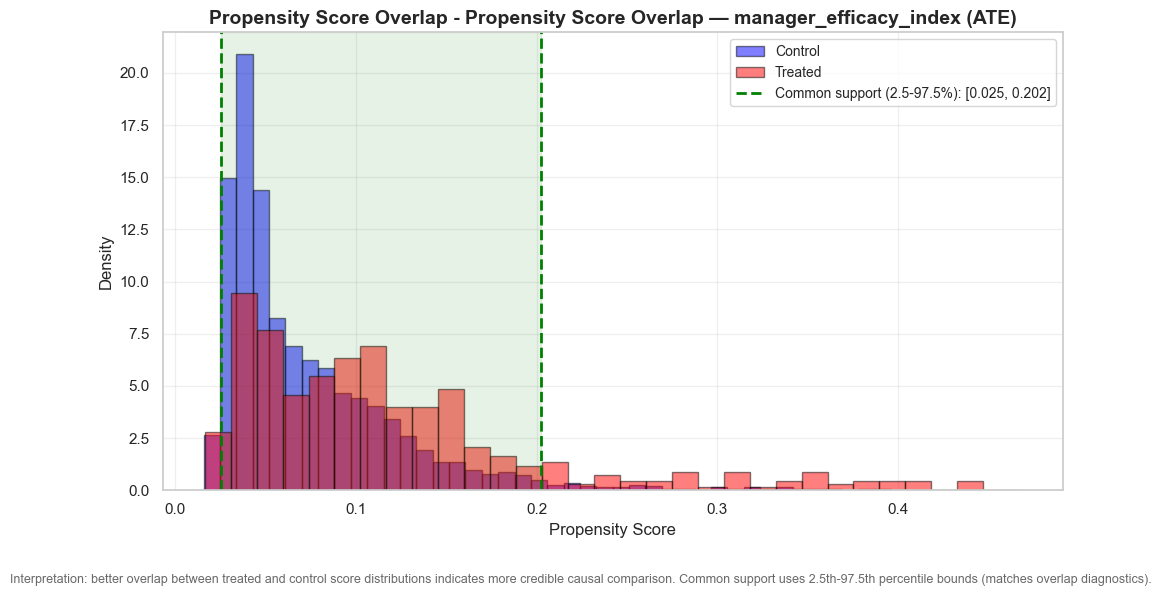

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [manager_efficacy_index] ATE = 0.3642 (95% CI: [0.2886, 0.4399]), p = 0.0000 ***, IPTW-weighted Cohen's d = 0.4385


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.364225,0.038593,0.288583,0.439867,3.817948e-21,0.05



ANALYZING OUTCOME: workload_index_mgr

📊 Analyzing outcome: workload_index_mgr
⚠️  REMINDER: This returns raw p-values. For multiple outcomes, use build_summary_table() for FDR correction.


c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


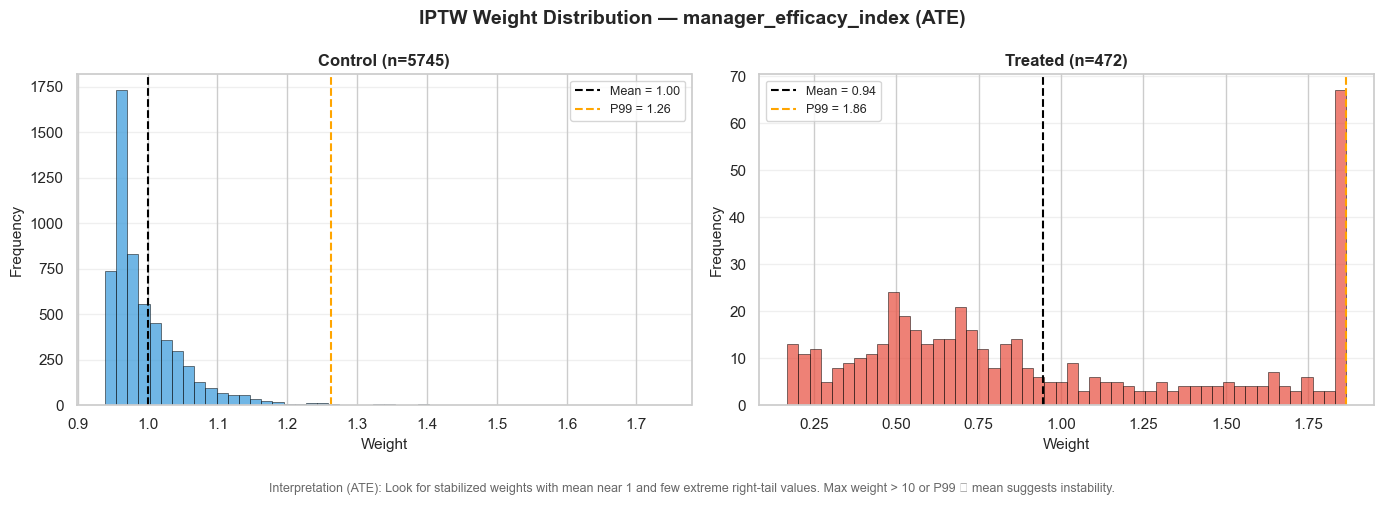

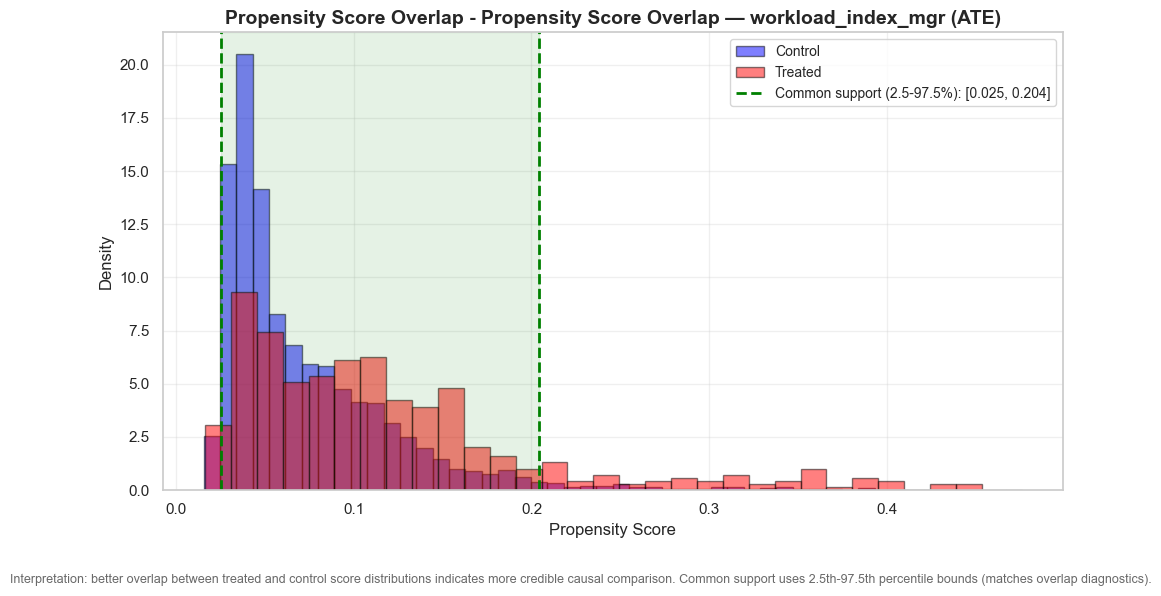

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [workload_index_mgr] ATE = -0.0033 (95% CI: [-0.1016, 0.0950]), p = 0.9472 , IPTW-weighted Cohen's d = -0.0003


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,-0.00332,0.050159,-0.10163,0.094989,0.947223,0.05



ANALYZING OUTCOME: stay_intention_index_mgr

📊 Analyzing outcome: stay_intention_index_mgr
⚠️  REMINDER: This returns raw p-values. For multiple outcomes, use build_summary_table() for FDR correction.


c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


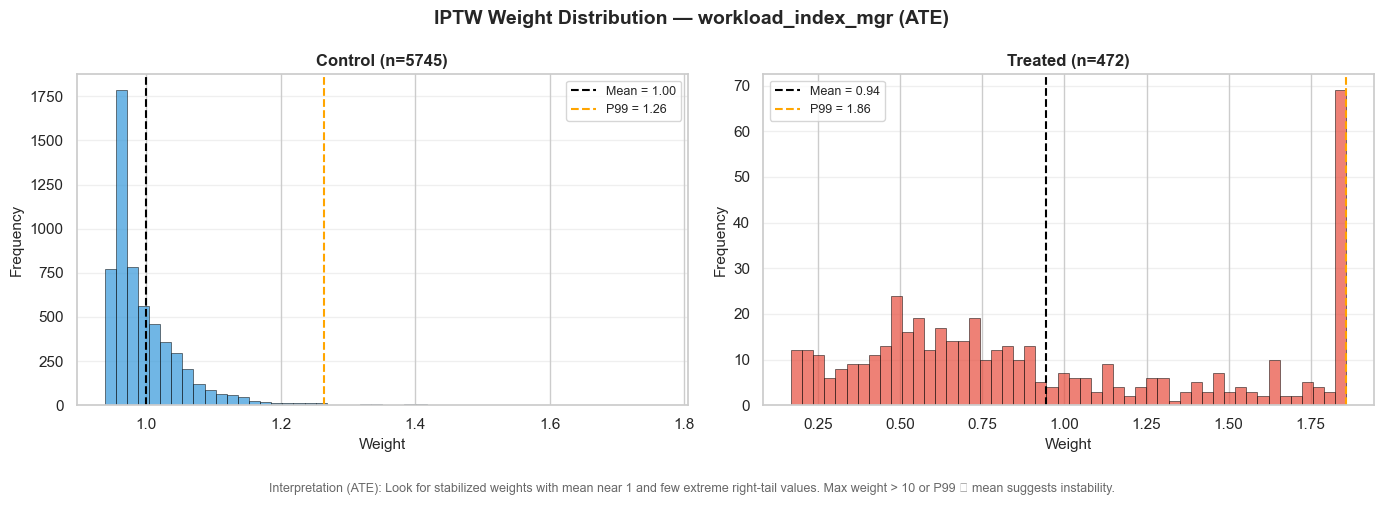

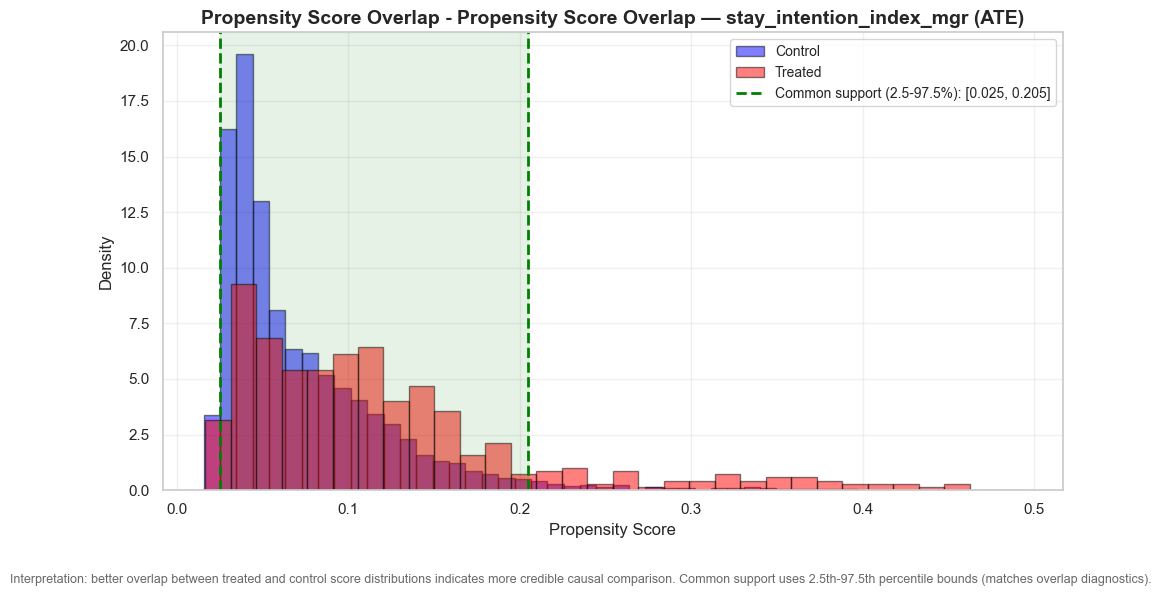

  ✓ Post-weighting balance: all 32 covariates balanced (|SMD| < 0.1)
  [stay_intention_index_mgr] ATE = 0.1649 (95% CI: [0.0835, 0.2464]), p = 0.0001 ***, IPTW-weighted Cohen's d = 0.1560


,Parameter,Estimate,Std_Error,CI_Lower,CI_Upper,P_Value_Raw,Alpha
28,treatment,0.164919,0.041564,0.083456,0.246382,0.000073,0.05



  IPTW + GEE: ATE Summary — Survey Outcomes (3 tests)
                 Outcome  Effect Estimand Std_Error CI_Lower CI_Upper P_Value Cohens_d Pct_Change Mean_Treatment Mean_Control    N    ESS P_Value_Corrected  Significant Significance Correction_Method
  manager_efficacy_index  0.3642      ATE    0.0386   0.2886   0.4399  0.0000   0.4385     10.79%         3.7661       3.3992 6217 6054.8            0.0000         True          ***            fdr_bh
      workload_index_mgr -0.0033      ATE    0.0502  -0.1016   0.0950  0.9472  -0.0003     -0.01%         3.1779       3.1782 6217 6055.9            0.9472        False                         fdr_bh
stay_intention_index_mgr  0.1649      ATE    0.0416   0.0835   0.2464  0.0001   0.1560      5.33%         2.9574       2.8078 6217 6056.0            0.0001         True          ***            fdr_bh
  Significance: *** p<0.001, ** p<0.01, * p<0.05
  Cohens_d: IPTW-weighted Cohen's d (from analyze_treatment_effect)
  Correction: fdr_bh across 

c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


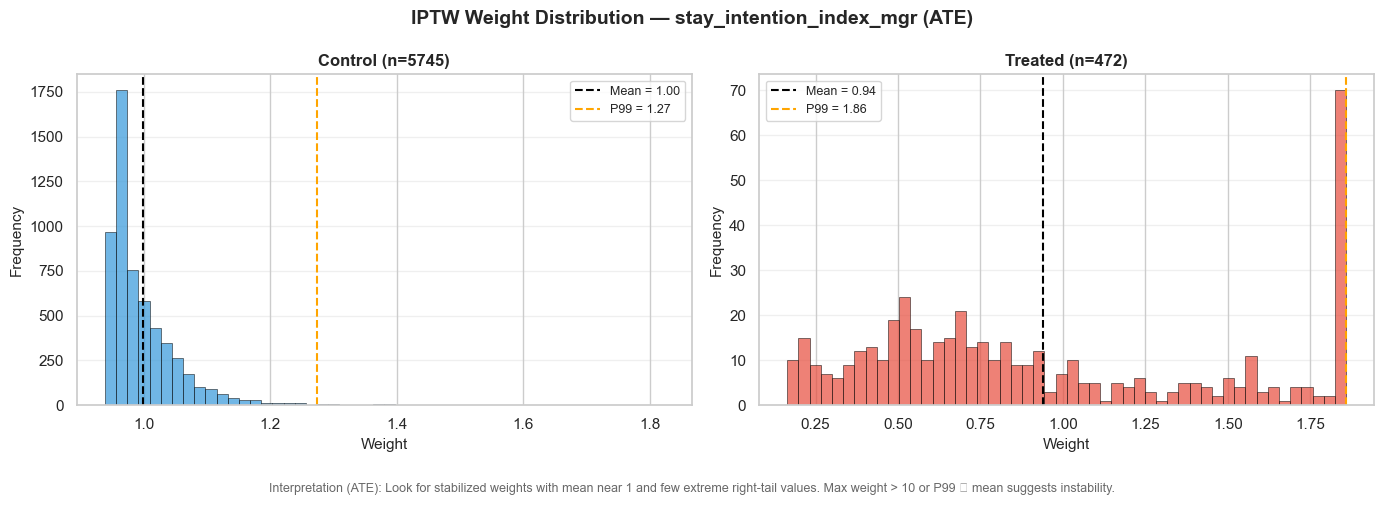

In [17]:
#@title ATE ANALYSIS — SURVEY OUTCOMES (IPTW + Covariate-Adjusted GEE)
# =============================================================================

causal_model = CausalInferenceModel()

survey_results = {}

for o in survey_outcomes:
    print("\n" + "=" * 60)
    print(f"ANALYZING OUTCOME: {o}")
    print("=" * 60)
    survey_results[o] = causal_model.analyze_treatment_effect(
        data=data,
        outcome_var=o,
        treatment_var=treatment,
        estimand='ATE',
        categorical_vars=categorical_vars,
        continuous_vars=continuous_vars,
        binary_vars=None,
        cluster_var='team_id',
        baseline_var=baseline_vars.get(o),
        project_path=base_dir / "results",
        trim_quantile=0.99,
        analysis_name=f"IPTW_GEE_{o}",
        alpha=0.05
    )
    display(survey_results[o]['coefficients_df'])

survey_summary = CausalInferenceModel.build_summary_table(
    survey_results,
    title="IPTW + GEE: ATE Summary — Survey Outcomes (3 tests)",
    save_path=str(base_dir / "results" / "ate_summary_survey.xlsx")
)

# =============================================================================
# INDEPENDENT POST-WEIGHTING BALANCE VERIFICATION — Survey
# =============================================================================

def verify_balance(results_dict, cd_instance, treatment_var,
                   exclude_cols=None):
    """
    Independent cross-check of post-weighting covariate balance.
    Uses CausalDiagnostics.compute_balance_df() on the weighted_df returned
    by analyze_treatment_effect / analyze_survival_effect, and compares
    against the model's balance_df.
    """
    # Default exclusion list for GEE outcomes
    if exclude_cols is None:
        exclude_cols = []

    for outcome, res in results_dict.items():
        wdf = res.get('weighted_df')
        if wdf is None:
            print(f"  [{outcome}] No weighted_df in results - skipping.")
            continue

        # Identify balance covariates (everything except outcome, ID, weight, PS)
        always_exclude = {treatment_var, 'id', 'team_id', 'propensity_score', 'iptw'}
        always_exclude.update(exclude_cols)
        always_exclude.add(outcome)
        balance_cols = [c for c in wdf.columns if c not in always_exclude]

        independent_balance = cd_instance.compute_balance_df(
            data=wdf,
            controls=balance_cols,
            treatment=treatment_var,
            weights=wdf['iptw'],
            already_encoded=True,
        )

        # Flag any covariates with weighted |SMD| > 0.1
        imbalanced = independent_balance[independent_balance['Weighted SMD'].abs() > 0.1]
        n_imbal = len(imbalanced)

        model_bal = res['balance_df']
        n_model_imbal = model_bal['balanced_after_weighting'].eq(False).sum() if 'balanced_after_weighting' in model_bal.columns else '?'

        status = '\u2705' if n_imbal == 0 else '\u26a0\ufe0f'
        print(f"  {status} [{outcome}]  Independent imbalanced: {n_imbal}  |  Model imbalanced: {n_model_imbal}")
        if n_imbal > 0:
            display(imbalanced)

print('=' * 60)
print('BALANCE VERIFICATION — Survey Outcomes (ATE)')
print('=' * 60)
verify_balance(survey_results, cd, treatment)

##### Sensitivity Analysis

In [18]:
#@title HTML: Sensitivity Analysis
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 20px; font-size: 24px; }
    .slide h3 { color: #34495e; margin: 15px 0 8px 0; font-size: 18px; }
    .slide p { line-height: 1.6; margin-bottom: 15px; font-size: 15px; }
    .slide ul { margin: 15px 0; padding-left: 25px; }
    .slide li { margin-bottom: 10px; line-height: 1.6; font-size: 15px; }
    .note { background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .tip { background-color: #e8f8f5; padding: 15px; border-left: 4px solid #20c997; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .evalue-scale { background-color: #f8f9fa; padding: 12px; border-radius: 4px; margin: 15px 0; font-size: 13px; }
    .evalue-scale div { margin-bottom: 6px; padding: 6px 10px; border-radius: 3px; }
    .evalue-strong { background: #d4edda; border-left: 3px solid #28a745; }
    .evalue-moderate { background: #cfe2ff; border-left: 3px solid #0d6efd; }
    .evalue-weak { background: #fff3cd; border-left: 3px solid #ffc107; }
    .evalue-vweak { background: #f8d7da; border-left: 3px solid #dc3545; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 15px; }
    .tag-overview { background: #007bff; }
    .tag-concept { background: #0d6efd; }
    .tag-interpret { background: #20c997; }
    .tag-benchmark { background: #fd7e14; }
    .return-toc { margin-top: 15px; padding-top: 15px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; transition: background 0.2s; }
    .return-toc button:hover { background: #5a6268; }
    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
</style>

<div id="slideshow5">
    <div class="slide-container">

        <!-- Slide 1: Table of Contents -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Sensitivity Analysis: E-Values and Unmeasured Confounding</h2>
            <p>Even with IPTW and covariate adjustment, we cannot rule out unmeasured confounding. Sensitivity analysis quantifies how robust our causal estimates are to hidden confounders.</p>
            <p>Click any section below to jump to it:</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>The Problem: Unmeasured Confounding</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>What Are E-Values?</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>E-Value Interpretation Scale</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>How to Read E-Value Output</div>
                <div class="toc-item" data-slide="5"><span>Slide 6</span>Confounder Benchmarking</div>
                <div class="toc-item" data-slide="6"><span>Slide 7</span>When to Trust Your Results</div>
            </div>
        </div>

        <!-- Slide 2: The Problem -->
        <div class="slide">
            <span class="tag tag-concept">Problem</span>
            <h2>The Problem: Unmeasured Confounding</h2>
            <p>Our causal inference approach (IPTW + GEE) assumes we have measured all confounders. But in reality:</p>
            <ul>
                <li>Some confounders are <strong>unobservable</strong> (e.g., manager motivation, hidden selection bias)</li>
                <li>Some confounders are <strong>unmeasured</strong> in our dataset (e.g., prior training history)</li>
                <li>We can never be 100% certain we've captured everything</li>
            </ul>
            <h3>The Question:</h3>
            <p><strong>"How strong would an unmeasured confounder need to be to explain away our treatment effect?"</strong></p>
            <p>If the answer is "unrealistically strong," we can be more confident in our result. If the answer is "quite modest," we should be cautious.</p>
            <div class="note">
                This is why sensitivity analysis is essential. It acknowledges the limits of our causal assumptions and quantifies the vulnerability of our estimates.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: What Are E-Values -->
        <div class="slide">
            <span class="tag tag-concept">Concept</span>
            <h2>What Are E-Values?</h2>
            <p>An <strong>E-value</strong> (Ding & VanderWeele, 2016) is the <strong>minimum strength of association</strong> (on the risk ratio scale) that an unmeasured confounder would need to have with <strong>both treatment and outcome</strong> to explain away a causal effect.</p>
            <h3>In Plain Language:</h3>
            <ul>
                <li>We observe a treatment effect</li>
                <li>The E-value tells us: <strong>"How strong would a hidden confounder need to be to make this effect disappear?"</strong></li>
                <li>Strength is measured as a <strong>risk ratio (RR)</strong> — the ratio of odds/probabilities</li>
                <li>An E-value of 2.0 means the confounder would need RR = 2.0 with both treatment and outcome</li>
            </ul>
            <h3>Key Assumption:</h3>
            <p>E-values assume the confounder affects treatment and outcome <strong>equally</strong> (on the RR scale). This is conservative — a confounder that affects one more than the other would need to be even stronger to explain away the effect.</p>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Interpretation Scale -->
        <div class="slide">
            <span class="tag tag-interpret">Interpretation</span>
            <h2>E-Value Interpretation Scale</h2>
            <p>E-values are interpreted using heuristic thresholds. Higher E-values = more robust to unmeasured confounding:</p>
            <div class="evalue-scale">
                <div class="evalue-strong">
                    <strong>E-value ≥ 3.0:</strong> Strong robustness. A confounder would need RR ≥ 3.0 with both treatment and outcome. This is a high bar — most real confounders are weaker.
                </div>
                <div class="evalue-moderate">
                    <strong>E-value 2.0–3.0:</strong> Moderate robustness. A confounder of moderate strength could potentially explain the effect, but it would need to be fairly strong.
                </div>
                <div class="evalue-weak">
                    <strong>E-value 1.5–2.0:</strong> Weak robustness. A relatively modest confounder (RR ≈ 1.5–2.0) could explain the effect. Interpret with caution.
                </div>
                <div class="evalue-vweak">
                    <strong>E-value &lt; 1.5:</strong> Very weak robustness. Even a weak confounder could explain the effect away. The result is fragile.
                </div>
            </div>
            <div class="note">
                <strong>Caveat:</strong> For continuous outcomes, E-values use an approximate conversion from Cohen's d to RR. The interpretation is approximate, not exact. For binary outcomes, E-values are more precise.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Reading E-Value Output -->
        <div class="slide">
            <span class="tag tag-interpret">Output</span>
            <h2>How to Read E-Value Output</h2>
            <p>E-value analyses typically report two key numbers:</p>
            <h3>1. Point Estimate E-Value</h3>
            <ul>
                <li>Based on the <strong>point estimate</strong> of the treatment effect</li>
                <li>Answers: "How strong must a confounder be to explain away the observed effect?"</li>
                <li>Usually the primary focus</li>
            </ul>
            <h3>2. Confidence Interval Bound E-Value</h3>
            <ul>
                <li>Based on the <strong>lower confidence interval bound</strong> of the treatment effect</li>
                <li>Answers: "How strong must a confounder be to shift the CI to include the null?"</li>
                <li>More conservative — accounts for uncertainty in the estimate</li>
                <li>If this E-value is low, even modest confounding could make the result non-significant</li>
            </ul>
            <div class="tip">
                <strong>Practical rule:</strong> If the CI bound E-value is high, your result is robust even accounting for estimation uncertainty. If it's low, be cautious about over-interpreting the result.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 6: Confounder Benchmarking -->
        <div class="slide">
            <span class="tag tag-benchmark">Benchmarking</span>
            <h2>Confounder Benchmarking: Calibration</h2>
            <p>To interpret E-values in context, we compare them to the <strong>strength of measured confounders</strong> in our data.</p>
            <h3>The Idea:</h3>
            <ul>
                <li>We can calculate E-values for the <strong>strongest measured confounders</strong> (pre-weighting)</li>
                <li>These give us a <strong>benchmark</strong> for what "strong" means in our specific dataset</li>
                <li>If the treatment E-value exceeds the measured confounder E-values, the effect is likely robust</li>
                <li>If the treatment E-value is lower, an unmeasured confounder of similar strength to measured ones could explain the effect</li>
            </ul>
            <h3>Interpretation:</h3>
            <ul>
                <li><strong>Treatment E-value > Measured confounder E-values:</strong> Effect is robust. An unmeasured confounder would need to be stronger than the measured ones.</li>
                <li><strong>Treatment E-value ≤ Measured confounder E-values:</strong> Effect is vulnerable. An unmeasured confounder of similar strength to measured ones could explain it away.</li>
            </ul>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 7: When to Trust Results -->
        <div class="slide">
            <span class="tag tag-overview">Summary</span>
            <h2>When to Trust Your Results: A Decision Framework</h2>
            <h3>High Confidence (Trust the Result):</h3>
            <ul>
                <li>E-value ≥ 3.0 (strong robustness)</li>
                <li>CI bound E-value is also high (≥ 2.0)</li>
                <li>Treatment E-value exceeds measured confounder E-values</li>
            </ul>
            <h3>Moderate Confidence (Interpret Cautiously):</h3>
            <ul>
                <li>E-value 2.0–3.0 (moderate robustness)</li>
                <li>CI bound E-value is moderate (1.5–2.0)</li>
                <li>Treatment E-value is similar to or slightly exceeds measured confounders</li>
            </ul>
            <h3>Low Confidence (Be Very Cautious):</h3>
            <ul>
                <li>E-value &lt; 2.0 (weak robustness)</li>
                <li>CI bound E-value is low (&lt; 1.5)</li>
                <li>Treatment E-value is lower than measured confounder E-values</li>
                <li><strong>Action:</strong> Seek replication, additional robustness checks, or qualitative evidence</li>
            </ul>
            <div class="tip">
                <strong>Remember:</strong> Sensitivity analysis is not a pass/fail test. It's a tool for understanding the vulnerability of your estimates. Even results with low E-values can be valuable — they just require more cautious interpretation and additional evidence.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress5"></div>

    <div class="controls">
        <button class="nav-btn5" data-dir="-1">← Previous</button>
        <span id="counter5">1 / 7</span>
        <button class="nav-btn5" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow5');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress5');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter5').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn5');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

In [19]:
#@title E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)
# =============================================================================

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)")
print("=" * 70)

# For survey outcomes (continuous), use Cohen's d
survey_evalues = CausalInferenceModel.compute_evalues_from_results(
    survey_results,
    effect_type="cohens_d"
)

# Confounder E-value benchmarks for calibration
survey_confounder_benchmarks = CausalInferenceModel.compute_confounder_evalue_benchmarks(
    survey_results,
    evalue_df=survey_evalues,
    n_top=3,
)
display(survey_confounder_benchmarks)

# Save to Excel
survey_evalues.to_excel(base_dir / "results" / "ate_evalue_survey.xlsx", index=False)
survey_confounder_benchmarks.to_excel(
    base_dir / "results" / "ate_evalue_confounder_benchmarks_survey.xlsx", index=False
)


E-VALUE SENSITIVITY ANALYSIS — Survey Outcomes (ATE)

  E-VALUE SENSITIVITY ANALYSIS
                 Outcome Effect_Type  Effect_Value  Effect_RR  E_Value_Point  E_Value_CI Robustness      P_Value  Significant
  manager_efficacy_index    cohens_d      0.438507   1.490395       2.345311    2.079227   Moderate 3.817948e-21         True
      workload_index_mgr    cohens_d     -0.000308   1.000280       1.017026    1.433205  Very Weak 9.472231e-01        False
stay_intention_index_mgr    cohens_d      0.156017   1.152548       1.571855    1.381039       Weak 7.251804e-05         True
  Interpretation Guide:
    E-value ≥ 3.0 : Strong robustness to unmeasured confounding
    E-value 2.0-3.0: Moderate robustness
    E-value 1.5-2.0: Weak robustness - interpret with caution
    E-value < 1.5 : Very weak - easily explained by confounding
    (Thresholds are heuristic; true RR-scale effects have more precise
     interpretations than approximate conversions from Cohen's d.)

  Per-Outcome In

,Outcome,Confounder,Rank,SMD_Pre_Weighting,Approx_RR,Confounder_E_Value
0,manager_efficacy_index,performance_rating_Meets,1,-0.392,1.4286,2.21
1,manager_efficacy_index,performance_rating_Far_Exceeds,2,0.368,1.3978,2.14
2,manager_efficacy_index,organization_RandD,3,0.351,1.3763,2.10
3,workload_index_mgr,performance_rating_Meets,1,-0.392,1.4286,2.21
4,workload_index_mgr,performance_rating_Far_Exceeds,2,0.368,1.3978,2.14
5,workload_index_mgr,organization_RandD,3,0.351,1.3763,2.10
6,stay_intention_index_mgr,performance_rating_Meets,1,-0.392,1.4286,2.21
7,stay_intention_index_mgr,performance_rating_Far_Exceeds,2,0.368,1.3978,2.14
8,stay_intention_index_mgr,organization_RandD,3,0.351,1.3763,2.10


In [20]:
#@title SHARED LABELS FOR LATER SUMMARY CELLS
# =============================================================================

outcome_descriptions = {
    'manager_efficacy_index': 'Manager Efficacy Index',
    'workload_index_mgr': 'Workload Index',
    'stay_intention_index_mgr': 'Stay Intention Index',
    'retention': 'Manager Retention',
}

# Outcome valence: "positive" = higher is better (default), "negative" = higher is worse
outcome_valence = {
    'workload_index_mgr': 'negative',  # higher workload = worse
    # all others default to 'positive'
}

print("Outcome descriptions and valence defined.")

Outcome descriptions and valence defined.


#### ATE Technical Summary: Survey Outcomes
Note: Findings do not generalize to poor performers.

| Outcome | ATE | 95% CI | p (corrected) | Cohen's d | Significant? |
|---------|-----|--------|---------------|-----------|-------------|
| Manager Efficacy Index | **+0.36** | [0.29, 0.44] | < 0.0001 | 0.44 | Yes *** |
| Workload Index | **-0.003** | [-0.10, 0.10] | 0.947 | ~0 | No |
| Stay Intention Index | **+0.16** | [0.08, 0.25] | < 0.0001 | 0.16 | Yes *** |

**Manager Efficacy Index**
- ATE of **+0.36** (Cohen's d = 0.44), representing a **+10.8% relative improvement** vs. controls

**Workload Index** — *No effect detected*
- ATE of **-0.003**, not statistically significant (p = 0.947)

**Stay Intention Index**
- ATE of **+0.16** (Cohen's d = 0.16), representing a **+5.3% relative improvement** vs. controls

##### Self-Report Bias Caveat

These are self-reported outcomes from managers who know they were trained. Demand characteristics (responding in the way they believe the organization expects), cognitive dissonance reduction (justifying time invested in the program), and social desirability bias could all inflate these numbers. A Cohen's d of 0.44 for self-reported efficacy after a voluntary program is consistent with a real effect, but also consistent with a meaningful placebo component. The retention analysis, which uses an objective behavioral outcome, provides our stronger evidence.

##### Post-Weighting Balance Verification
- ✅ All 3 outcomes passed balance verification (0 imbalanced covariates).
- IPTW successfully balanced observed confounders across treatment groups.

##### E-Value Sensitivity Analysis

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Efficacy Index | **2.35** | **2.08** | Moderate |
| Workload Index | 1.02 | 1.43 | Very Weak (ns) |
| Stay Intention Index | **1.57** | **1.38** | Weak |

**Significant outcome interpretations:**

- **Manager Efficacy Index:** E-value = 2.35. An unmeasured confounder would need risk ratio associations of at least 2.35 with both treatment and outcome to explain away this effect. This represents moderate robustness. The E-value for the confidence interval bound is 2.08, meaning a confounder of this strength could shift the CI to include the null.

- **Stay Intention Index:** E-value = 1.57. A relatively weak unmeasured confounder (RR ≈ 1.57) could potentially explain this effect. Interpret with caution. The E-value for the confidence interval bound is 1.38, meaning a confounder of this strength could shift the CI to include the null.

In [21]:
#@title HTML: ATE vs. ATT
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 20px; font-size: 24px; }
    .slide h3 { color: #34495e; margin: 15px 0 8px 0; font-size: 18px; }
    .slide p { line-height: 1.6; margin-bottom: 15px; font-size: 15px; }
    .slide ul { margin: 15px 0; padding-left: 25px; }
    .slide li { margin-bottom: 10px; line-height: 1.6; font-size: 15px; }
    .slide table { width: 100%; border-collapse: collapse; margin: 15px 0; font-size: 14px; }
    .slide th, .slide td { border: 1px solid #ddd; padding: 10px; text-align: left; }
    .slide th { background-color: #f8f9fa; font-weight: bold; }
    .note { background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .tip { background-color: #e8f8f5; padding: 15px; border-left: 4px solid #20c997; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .warning { background-color: #f8d7da; padding: 15px; border-left: 4px solid #dc3545; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .formula { background-color: #f8f9fa; padding: 15px; border-left: 4px solid #007bff; margin: 15px 0; font-size: 15px; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 15px; }
    .tag-overview { background: #007bff; }
    .tag-weights { background: #6f42c1; }
    .tag-results { background: #fd7e14; }
    .tag-guidance { background: #20c997; }
    .return-toc { margin-top: 15px; padding-top: 15px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; transition: background 0.2s; }
    .return-toc button:hover { background: #5a6268; }
    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
</style>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div id="slideshow6">
    <div class="slide-container">

        <!-- Slide 1: Table of Contents -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>ATE vs. ATT: What Changes?</h2>
            <p>The ATT (Average Treatment Effect on the Treated) answers a different question: <strong>"Did the program work for those who actually participated?"</strong> — rather than <strong>"What would happen if we scaled this to everyone?"</strong></p>
            <p>Click any section below to jump to it:</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>Different Questions, Different Estimands</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>Weight Formula Comparison</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>ATE vs. ATT Results</div>
            </div>
        </div>

        <!-- Slide 2: Different Questions -->
        <div class="slide">
            <span class="tag tag-overview">Questions</span>
            <h2>Different Questions, Different Estimands</h2>
            <h3>ATE (Average Treatment Effect):</h3>
            <ul>
                <li><strong>Question:</strong> "What would happen if we assigned treatment to everyone vs. no one?"</li>
                <li><strong>Target population:</strong> Full population (treated + untreated)</li>
                <li><strong>Use case:</strong> Policy decisions about universal rollout</li>
                <li><strong>Example:</strong> "Should we mandate this training for all managers?"</li>
            </ul>
            <h3>ATT (Average Treatment Effect on the Treated):</h3>
            <ul>
                <li><strong>Question:</strong> "Did the program work for those who actually participated?"</li>
                <li><strong>Target population:</strong> Only those who received treatment</li>
                <li><strong>Use case:</strong> Evaluating program effectiveness for participants</li>
                <li><strong>Example:</strong> "Was the training beneficial for managers who attended?"</li>
            </ul>
            <div class="note">
                Both are valid causal questions, but they target different populations and inform different decisions.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: Weight Formulas -->
        <div class="slide">
            <span class="tag tag-weights">Weights</span>
            <h2>Weight Formula Comparison</h2>
            <p><strong>Mechanically, only the weight formula changes:</strong></p>
            <table>
                <tr>
                    <th>Group</th>
                    <th>ATE Weights</th>
                    <th>ATT Weights</th>
                </tr>
                <tr>
                    <td><strong>Treated</strong></td>
                    <td>\(1 / \hat{e}_i\)</td>
                    <td>\(1\) (unweighted)</td>
                </tr>
                <tr>
                    <td><strong>Control</strong></td>
                    <td>\(1 / (1 - \hat{e}_i)\)</td>
                    <td>\(\hat{e}_i / (1 - \hat{e}_i)\)</td>
                </tr>
            </table>
            <h3>Key Differences:</h3>
            <ul>
                <li><strong>ATE:</strong> Reweights <strong>both</strong> groups to represent the full population</li>
                <li><strong>ATT:</strong> Leaves treated individuals at their natural weight and reweights only controls to resemble the treated group</li>
            </ul>
            <div class="tip">
                Everything else stays identical: propensity score model, GEE specification, covariates, clustering. Only the weights change.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Results Comparison -->
        <div class="slide">
            <span class="tag tag-results">Results</span>
            <h2>ATE vs. ATT Results Comparison</h2>
            <table>
                <tr>
                    <th>Outcome</th>
                    <th>ATE</th>
                    <th>ATT</th>
                    <th>Difference</th>
                </tr>
                <tr>
                    <td><strong>Manager Efficacy Index</strong></td>
                    <td>+0.36 (d = 0.44)</td>
                    <td>+0.35 (d = 0.43)</td>
                    <td>ATT slightly smaller</td>
                </tr>
                <tr>
                    <td><strong>Workload Index</strong></td>
                    <td>-0.003 (ns)</td>
                    <td>-0.01 (ns)</td>
                    <td>Both null</td>
                </tr>
                <tr>
                    <td><strong>Turnover Intention Index</strong></td>
                    <td>+0.16 (d = 0.16)</td>
                    <td>+0.18 (d = 0.19)</td>
                    <td>ATT slightly larger</td>
                </tr>
            </table>
            <h3>Pattern:</h3>
            <p>ATT effects are consistently slightly larger, consistent with <strong>positive selection</strong>: managers who chose to participate benefit somewhat more than the average manager would.</p>
            <div class="tip">
                Both estimands tell the same <strong>qualitative story</strong>. The differences are modest, suggesting the treatment effect is fairly homogeneous across the population.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress6"></div>

    <div class="controls">
        <button class="nav-btn6" data-dir="-1">← Previous</button>
        <span id="counter6">1 / 6</span>
        <button class="nav-btn6" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow6');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress6');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter6').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
            if (window.MathJax) {
                MathJax.typesetPromise([slides[slideIndex]]);
            }
        }

        container.addEventListener('click', function(e) {
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn6');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });

        if (window.MathJax) {
            MathJax.typesetPromise([slides[0]]);
        }
    })();
</script>
""")

In [ ]:
#@title ATT ANALYSIS — OPTIONAL (uncomment to run)
# =============================================================================
# The ATT analysis uses the same pipeline as ATE above with one change:
# estimand='ATT' in the analyze_treatment_effect() call.
# This changes only the weight formula — everything else is identical.
# Pre-computed results are shown in the comparison table above.
#
# To run this yourself, uncomment and adapt the code below:
#
# causal_model = CausalInferenceModel()
# survey_results_att = {}

# for o in survey_outcomes:
#     survey_results_att[o] = causal_model.analyze_treatment_effect(
#         data=data,
#         outcome_var=o,
#         treatment_var=treatment,
#         estimand='ATT',
#         categorical_vars=categorical_vars,
#         continuous_vars=continuous_vars,
#         cluster_var='team_id',
#         baseline_var=baseline_vars.get(o),
#         project_path=base_dir / "results",
#         trim_quantile=0.99,
#         analysis_name=f"IPTW_GEE_ATT_{o}",
#         alpha=0.05,
#     )
#     display(survey_results_att[o]['coefficients_df'])

# att_survey_summary = CausalInferenceModel.build_summary_table(
#     survey_results_att,
#     title="IPTW + GEE: ATT Summary — Survey Outcomes (3 tests)",
#     save_path=str(base_dir / "results" / "att_summary_survey.xlsx")
# )

In [ ]:
#@title ATT E-VALUE ANALYSIS — OPTIONAL (uncomment to run)
# =============================================================================
# If you rerun the optional ATT analysis, you can generate ATT-specific
# E-values with the same helper used above:
#
# survey_evalues_att = CausalInferenceModel.compute_evalues_from_results(
#     survey_results_att,
#     effect_type="cohens_d",
# )
# survey_evalues_att.to_excel(base_dir / "results" / "att_evalue_survey.xlsx", index=False)

### Summary: Checkpoint 3

In [24]:
#@title HTML: Summary CP3
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; background: #007bff; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
</style>

<div id="slideshow_cp3">
    <div class="slide-container">

        <div class="slide active">
            <div class="checkpoint-layout">

                <!-- Left: Image -->
                <div class="checkpoint-left">
                    <img src="./diagrams/cp3sh.png" alt="Checkpoint 3 Diagram">
                </div>

                <!-- Right: Content -->
                <div class="checkpoint-right">
                    <span class="tag">Checkpoint 3</span>
                    <h2>Estimation & Results</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Successfully used IPTW weights and sandwiched SEs to fit stable GEE models (survey outcomes)</div>
                    <div class="achievement-box">✅ Verified data balance and conducted sensitivity checks to confirm robustness of findings</div>
                    <div class="achievement-box">✅ Compared ATE and ATT estimands</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>Strongest evidence for positive effect on manager efficacy.</strong> No effect detected for workload. Tenuous effect for stay intention that we'll explore further in our retention model.
                    </div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_cp3"></div>

    <div class="controls">
        <button class="nav-btn-cp3" data-dir="-1">← Previous</button>
        <span id="counter_cp3">1 / 1</span>
        <button class="nav-btn-cp3" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_cp3');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_cp3');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_cp3').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const btn = e.target.closest('.nav-btn-cp3');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

## Checkpoint 4: Retention Modeling

<img src="./diagrams/checkpoint4.png" width = "600" alt="Alt text">

---

### Retention Analysis — Survival Modeling (IPTW + Cox PH with Time Interaction)

In [25]:
#@title HTML: Retention modeling 
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 20px; font-size: 24px; }
    .slide h3 { color: #34495e; margin: 15px 0 8px 0; font-size: 18px; }
    .slide p { line-height: 1.6; margin-bottom: 15px; font-size: 15px; }
    .slide ul { margin: 15px 0; padding-left: 25px; }
    .slide li { margin-bottom: 10px; line-height: 1.6; font-size: 15px; }
    .slide table { width: 100%; border-collapse: collapse; margin: 15px 0; font-size: 14px; }
    .slide th, .slide td { border: 1px solid #ddd; padding: 10px; text-align: left; }
    .slide th { background-color: #f8f9fa; font-weight: bold; }
    .note { background-color: #fff3cd; padding: 15px; border-left: 4px solid #ffc107; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .tip { background-color: #e8f8f5; padding: 15px; border-left: 4px solid #20c997; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .warning { background-color: #f8d7da; padding: 15px; border-left: 4px solid #dc3545; margin: 15px 0; font-size: 14px; line-height: 1.6; }
    .formula { background-color: #f8f9fa; padding: 15px; border-left: 4px solid #007bff; margin: 15px 0; font-size: 15px; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 15px; }
    .tag-overview { background: #007bff; }
    .tag-weights { background: #6f42c1; }
    .tag-results { background: #fd7e14; }
    .tag-guidance { background: #20c997; }
    .return-toc { margin-top: 15px; padding-top: 15px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; transition: background 0.2s; }
    .return-toc button:hover { background: #5a6268; }
    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
</style>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div id="slideshow10">
    <div class="slide-container">

        <!-- Slide 1: Table of Contents -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Retention modeling: Why can't we just apply the same method as with survey outcomes?</h2>
            <p>Standard regression methods are often problematic with attrition outcomes. In this section, we discuss why it is the case and outline possible solutions.</p>
            <p>Click any section below to jump to it:</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>Different Data Generation Processes, Different Estimands</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>Weighted Kaplan-Meier Curve</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>RMST</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>Modeling Hazard Ratios with Cox Models</div>
            </div>
        </div>

        <!-- Slide 2: Data Generation Process -->
        <div class="slide">
            <span class="tag tag-overview">Data Generation</span>
            <h2>Different Data Generation Processes, Different Estimands</h2>
            <h3>Attrition metric has several important features:</h3>
            <ul>
                <li><strong>Time-to-event nature:</strong> Employees can leave at any point in time. A binary outcome (left or not) ignores exact timing</li>
                <li><strong>Right censoring:</strong> Some employees haven't left yet — we don't know when (or if) they will</li>
                <li><strong>Varying observation windows:</strong> Employees may have different follow-up periods</li>
                <li><strong>Non-linear dynamics:</strong> The risk of leaving may change over time (e.g., higher in the first 3 months)</li>
            </ul>
            <div class="warning">
                <strong>Why standard regression fails:</strong> A linear probability model (or logistic regression) for "left within 12 months" collapses all timing information into a single binary indicator. It cannot capture <em>when</em> people leave, treats someone who left at month 1 the same as month 11, and ignores censored observations.
            </div>
            <div class="note">
                We need methods specifically designed for time-to-event data: <strong>Kaplan-Meier curves</strong>, <strong>RMST</strong>, and <strong>Cox proportional hazards models</strong>.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: Weighted Kaplan-Meier -->
        <div class="slide">
            <span class="tag tag-weights">Descriptive</span>
            <h2>Weighted Kaplan-Meier Curve</h2>
            <p>The <strong>Kaplan-Meier estimator</strong> calculates the probability of surviving (staying) past each observed event time.</p>
            <h3>How it works:</h3>
            <ul>
                <li>At each departure time, compute the proportion who left among those still "at risk"</li>
                <li>Multiply these conditional survival probabilities to get the cumulative survival curve</li>
                <li>IPTW weights adjust the risk set so treated and control groups are comparable</li>
            </ul>
            <h3>Strengths:</h3>
            <ul>
                <li>✅ No assumptions about the shape of the hazard function</li>
                <li>✅ Handles censoring naturally</li>
                <li>✅ Visual and intuitive — easy for stakeholders to understand</li>
                <li>✅ Shows the full retention trajectory, not just a single number</li>
            </ul>
            <div class="note">
                <strong>Limitation:</strong> KM curves are <em>descriptive</em>. Under IPTW, the confidence bands from the Greenwood formula are not valid (they ignore propensity score uncertainty). For formal inference, we use Cox models.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: RMST -->
        <div class="slide">
            <span class="tag tag-results">Business Metric</span>
            <h2>Restricted Mean Survival Time (RMST)</h2>
            <p>RMST is the <strong>area under the KM survival curve</strong> up to a specified time horizon. It represents the average number of days an employee is expected to stay within the observation window.</p>
            <h3>Why RMST?</h3>
            <ul>
                <li><strong>Business-friendly:</strong> "Trained managers stayed an average of X additional days" is immediately actionable</li>
                <li><strong>No proportional hazards assumption:</strong> Works even when the treatment effect changes over time</li>
                <li><strong>Directly interpretable:</strong> Measured in days (or weeks), not hazard ratios</li>
            </ul>
            <h3>How it's computed:</h3>
            <div class="formula">
                RMST = \(\int_0^{\tau} \hat{S}(t) \, dt\)<br><br>
                where \(\hat{S}(t)\) is the IPTW-weighted KM survival function and \(\tau\) is the time horizon (e.g., 365 days).<br><br>
                <strong>Δ RMST = RMST<sub>treated</sub> − RMST<sub>control</sub></strong> = additional days retained due to treatment.
            </div>
            <div class="tip">
                Bootstrap confidence intervals are used for inference since the analytical variance under IPTW weighting is complex.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Cox Model -->
        <div class="slide">
            <span class="tag tag-guidance">Inference</span>
            <h2>Modeling Hazard Ratios with Cox Models</h2>
            <p>The <strong>Cox proportional hazards model</strong> estimates the <strong>hazard ratio (HR)</strong> — the relative risk of leaving at any given time point, comparing treated to control.</p>
            <h3>Standard Cox PH:</h3>
            <div class="formula">
                \(h(t | X) = h_0(t) \cdot \exp(\beta \cdot \text{Treatment} + \gamma \cdot X)\)<br><br>
                HR = \(\exp(\beta)\) — a single constant ratio across all time points.
            </div>
            <h3>Cox with Time Interactions:</h3>
            <p>If the treatment effect changes over time (PH violation), we split the timeline into periods and estimate <strong>separate HRs per period</strong>:</p>
            <ul>
                <li><strong>0–3 months:</strong> HR may be strongest (early retention boost)</li>
                <li><strong>3–6, 6–9, 9–12 months:</strong> Effect may fade as the program's impact wears off</li>
            </ul>
            <div class="note">
                <strong>Survivor selection bias:</strong> At later time points, the remaining population is increasingly selected — people who were going to leave early have already left. HRs at 9–12 months describe a <em>different</em> (more stable) population than HRs at 0–3 months.
            </div>
            <div class="tip">
                <strong>Recommended approach:</strong> Run all three methods. KM curves for visualization, RMST for the business case, and Cox with time interactions for formal inference with temporal granularity.
            </div>
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress10"></div>

    <div class="controls">
        <button class="nav-btn10" data-dir="-1">← Previous</button>
        <span id="counter10">1 / 5</span>
        <button class="nav-btn10" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow10');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress10');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter10').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
            if (window.MathJax) {
                MathJax.typesetPromise([slides[slideIndex]]);
            }
        }

        container.addEventListener('click', function(e) {
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn10');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });

        if (window.MathJax) {
            MathJax.typesetPromise([slides[0]]);
        }
    })();
</script>
""")

In [26]:
#@title RETENTION ANALYSIS — VARIABLE DEFINITIONS
###############################################

# Survival outcome variables
time_var = 'days_observed'   # will be created by prepare_survival_data()
event_var = 'departed'       # will be created by prepare_survival_data()

# The single survival outcome uses 'retention' as its key in results dicts
retention_outcome_name = 'retention'

# Departure date column in the raw data
departure_date_col = 'exit_date'

# Study window (matches the data generator)
t0_date = '1-01-2026'           # study start — all managers begin observation Jan 1
study_end_date = '12-31-2026'   # study end — 365-day observation window

print(f"Time variable:      {time_var}")
print(f"Event variable:     {event_var}")
print(f"Departure date col: {departure_date_col}")
print(f"Study window:       {t0_date} → {study_end_date}")

Time variable:      days_observed
Event variable:     departed
Departure date col: exit_date
Study window:       1-01-2026 → 12-31-2026


#### Run the Survival Analysis w/o Time Interactions

In [27]:
#@title SURVIVAL DATA PREPARATION
# =============================================================================
# Convert exit_date → days_observed + departed
# This adds two columns to the dataframe: 'days_observed' (int) and 'departed' (0/1)

data = causal_model.prepare_survival_data(
    data=data,
    departure_date_col=departure_date_col,
    treatment_var=treatment,
    t0_date=t0_date,
    study_end_date=study_end_date,
    date_format='mixed',           # exit_date uses M/D/YYYY without zero-padding
    time_col_name=time_var,
    event_col_name=event_var,
)

# Quick validation: departed events align with non-blank exit_date
print("\n--- Validation: survival columns vs. exit_date ---")
n_exit = (data['exit_date'].astype(str).str.strip() != '').sum()
print(f"  departed=1 count:       {data[event_var].sum()}")
print(f"  non-blank exit_date:    {n_exit}")
print(f"  Match:                  {data[event_var].sum() == n_exit}")


Parsed dates:
  T=0 (study start):  2026-01-01
  Study end:          2026-12-31
  Total window:       364 days
  Departure range:    2026-01-02 → 2026-12-30

SURVIVAL DATA PREPARATION SUMMARY
Study window:  2026-01-01  →  2026-12-31  (364 days)

SAMPLE:
  Total managers:          7220
  Treated (trained):       518 (7.2%)
  Control (untrained):     6702 (92.8%)

EVENTS (Departures):
  Total events:            1435 (19.9%)
  Events — Treated:        61 (11.8% of treated)
  Events — Control:        1374 (20.5% of control)

TIMING:
  Median days observed:    364 days
  Median days (events only): 89 days

DEPARTURE BY QUARTER:


,Control,Treated,Total
departure_quarter,,,
Q1 (Jan-Mar),688,39,727
Q2 (Apr-Jun),264,7,271
Q3 (Jul-Sep),210,7,217
Q4 (Oct-Dec),212,8,220
Censored,5328,457,5785
Total,6702,518,7220



CENSORED:
  Total censored:          5785 (80.1%)
  Censored — Treated:      457
  Censored — Control:      5328

✓ Survival columns added: 'days_observed' (days) and 'departed' (0/1)

--- Validation: survival columns vs. exit_date ---
  departed=1 count:       1435
  non-blank exit_date:    7220
  Match:                  False


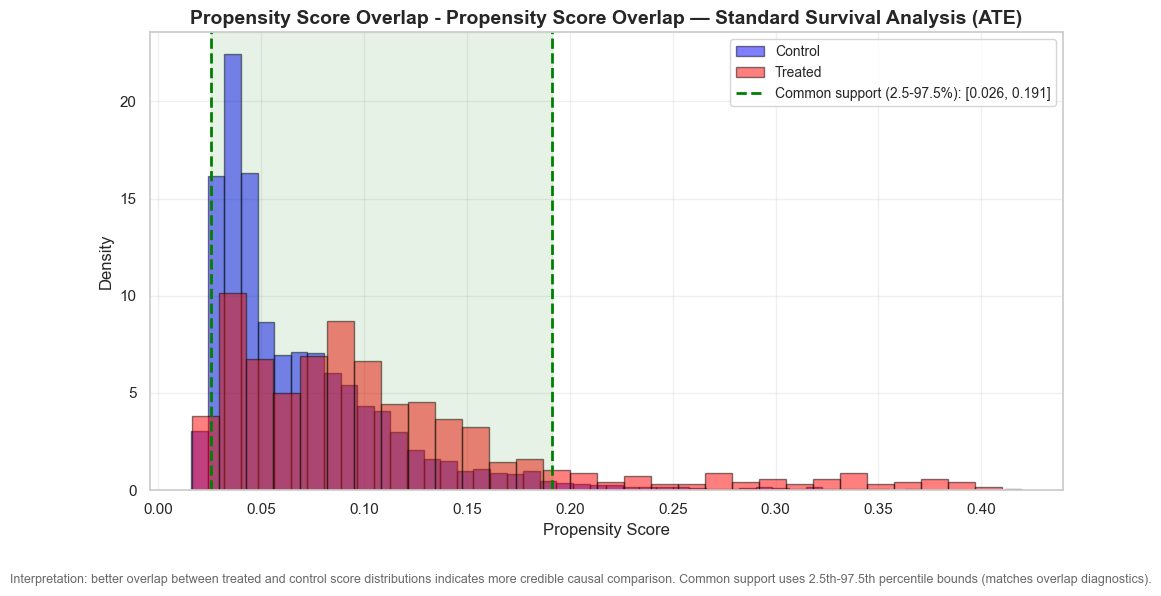

  ✓ Post-weighting balance: all 31 covariates balanced (|SMD| < 0.1)

COX PROPORTIONAL HAZARDS MODEL — STANDARD (NO TIME INTERACTION)
Model            : treatment (single overall HR)

Model fitted     : 7,220 observations, 1435 events
Concordance      : 0.551

--- Proportional Hazards Test ---
NOTE: Standard Cox PH assumes proportional hazards.
      If treatment violates PH, consider using
      analyze_survival_effect(time_interaction='categorical')
      to model time-varying effects.
                                   test_statistic         p note
age                                      3.443506  0.063501     
gender_Male                              0.590315  0.442297     
gender_Non_Binary_Other                  0.645742  0.421639     
job_family_Communications                0.115861  0.733568     
job_family_Data_Science                  0.165851  0.683826     
job_family_Finance_and_Accounting        0.055550  0.813673     
job_family_Human_Resources               2.342656  0

,Outcome,Confounder,Rank,SMD_Pre_Weighting,Approx_RR,Confounder_E_Value
0,retention,performance_rating_Meets,1,-0.402,1.4417,2.24
1,retention,performance_rating_Far_Exceeds,2,0.359,1.3864,2.12
2,retention,organization_RandD,3,0.336,1.3577,2.05


c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\IPython\core\events.py:100: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  func(*args, **kwargs)
c:\Users\U1008500\Documents\GitHub\2026-siop-causal-inference-master-tutorial\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8811 (\N{MUCH GREATER-THAN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


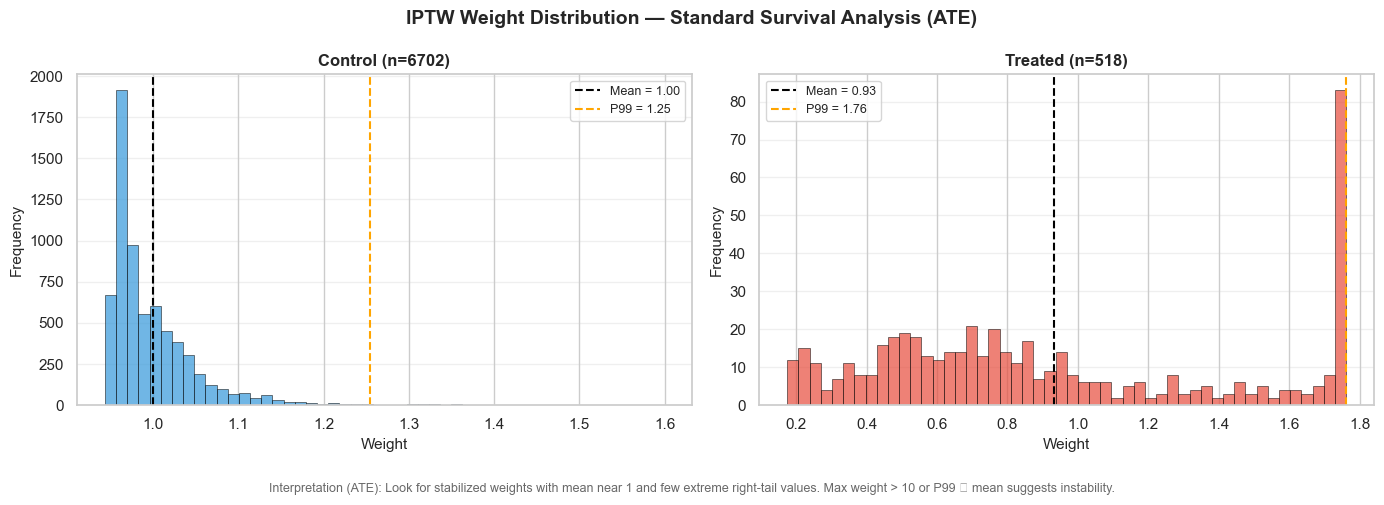

In [28]:
#@title Standard Cox PH (no time interaction)
standard_results = {}
standard_results['retention'] = causal_model.analyze_standard_survival_effect(
    data=data,
    time_var='days_observed',
    event_var='departed',
    treatment_var='treatment',
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars,
    cluster_var='team_id',
    estimand='ATE',
    project_path=str(base_dir / "results"),
    analysis_name='IPTW_Cox_Standard_retention',
)

# verify balance on the weighted data from the standard Cox model, excluding time/event vars and retention flags (which are outcomes, not covariates)
verify_balance(
    standard_results, cd, treatment,
    exclude_cols=[time_var, event_var, 'departure_quarter']
)
standard_summary = CausalInferenceModel.build_survival_summary_table(standard_results)
standard_evalues = CausalInferenceModel.compute_evalues_from_results(
    standard_results, effect_type="risk_ratio"
)

# Confounder E-value benchmarks for calibration
standard_confounder_benchmarks = CausalInferenceModel.compute_confounder_evalue_benchmarks(
    standard_results,
    evalue_df=standard_evalues,
    n_top=3,
)
display(standard_confounder_benchmarks)

# Save to Excel
standard_confounder_benchmarks.to_excel(
    base_dir / "results" / "ate_evalue_confounder_benchmarks_retention.xlsx", index=False
)

#### Run the Survival Analysis w/ Time Interactions

In [29]:
#@title Uncomment below to compare the results when allowing for time interactions
'''
# =============================================================================
# ATE ANALYSIS — RETENTION (IPTW + Cox Time Interaction)
# =============================================================================

print("=" * 60)
print("ANALYZING RETENTION: IPTW + Cox Time Interaction (ATE)")
print("=" * 60)

survival_results = {}

survival_results[retention_outcome_name] = causal_model.analyze_survival_effect(
    data=data,
    time_var=time_var,
    event_var=event_var,
    treatment_var=treatment,
    categorical_vars=categorical_vars,
    continuous_vars=continuous_vars,
    cluster_var='team_id',
    estimand='ATE',
    time_interaction='categorical',
    period_breaks=[0, 90, 180, 270, 365],   # 3/6/9/12 months
    period_labels=['0-3mo', '3-6mo', '6-9mo', '9-12mo'],
    project_path=str(base_dir / "results"),
    trim_quantile=0.99,
    analysis_name='IPTW_Cox_TimeInteraction_retention',
    alpha=0.05,
    plot_propensity=True,
    plot_weights=True,
)

display(survival_results[retention_outcome_name]['period_hrs'])

# =============================================================================
# KAPLAN-MEIER SURVIVAL CURVES
# =============================================================================

survival_fig = causal_model.plot_survival_curves(
    survival_result=survival_results[retention_outcome_name],
    outcome_name='Manager Retention',
    time_horizon=365,
    show_snapshots=True,
    snapshot_days=[90, 180, 270, 365],
    save_path=None,
);

# =============================================================================
# SURVIVAL SUMMARY TABLE
# =============================================================================

survival_summary = CausalInferenceModel.build_survival_summary_table(
    survival_results_dict=survival_results,
    title="IPTW + Cox Time Interaction: ATE Summary — Retention (1 test)",
    save_path=str(base_dir / "results" / "ate_summary_retention_survival.xlsx"),
)

# =============================================================================
# BALANCE VERIFICATION — Retention (ATE)
# =============================================================================
# Reuses verify_balance() defined in the survey section.
# For survival analysis, exclude time/event columns from balance covariates.

print('=' * 60)
print('BALANCE VERIFICATION — Retention (ATE, Survival)')
print('=' * 60)
verify_balance(
    survival_results, cd, treatment,
    exclude_cols=[time_var, event_var, 'departure_quarter']
)

# =============================================================================
# E-VALUE SENSITIVITY ANALYSIS — Retention (ATE)
# =============================================================================
# Hazard ratios are on the risk ratio scale, so we use effect_type="risk_ratio"

print("\n" + "=" * 70)
print("E-VALUE SENSITIVITY ANALYSIS — Retention (ATE, Survival)")
print("=" * 70)

survival_evalues = CausalInferenceModel.compute_evalues_from_results(
    survival_results,
    effect_type="risk_ratio"
)

# Confounder E-value benchmarks for calibration
survival_confounder_benchmarks = CausalInferenceModel.compute_confounder_evalue_benchmarks(
    survival_results,
    evalue_df=survival_evalues,
    n_top=3,
)
display(survival_confounder_benchmarks)

# Save to Excel
survival_evalues.to_excel(base_dir / "results" / "ate_evalue_retention_survival.xlsx", index=False)
survival_confounder_benchmarks.to_excel(
    base_dir / "results" / "ate_evalue_confounder_benchmarks_retention_timeint.xlsx", index=False
)

# =============================================================================
# PRESERVE RETENTION RESULTS
# =============================================================================

ate_survival_results = {k: v for k, v in survival_results.items()}
ate_survival_summary = survival_summary.copy()
ate_survival_evalues = survival_evalues.copy()
ate_rmst_results = {k: v for k, v in rmst_results.items()}

print("✅ ATE retention (survival) results preserved.")

'''

'\n# =============================================================================\n# ATE ANALYSIS — RETENTION (IPTW + Cox Time Interaction)\n# =============================================================================\n\nprint("=" * 60)\nprint("ANALYZING RETENTION: IPTW + Cox Time Interaction (ATE)")\nprint("=" * 60)\n\nsurvival_results = {}\n\nsurvival_results[retention_outcome_name] = causal_model.analyze_survival_effect(\n    data=data,\n    time_var=time_var,\n    event_var=event_var,\n    treatment_var=treatment,\n    categorical_vars=categorical_vars,\n    continuous_vars=continuous_vars,\n    cluster_var=\'team_id\',\n    estimand=\'ATE\',\n    time_interaction=\'categorical\',\n    period_breaks=[0, 90, 180, 270, 365],   # 3/6/9/12 months\n    period_labels=[\'0-3mo\', \'3-6mo\', \'6-9mo\', \'9-12mo\'],\n    project_path=str(base_dir / "results"),\n    trim_quantile=0.99,\n    analysis_name=\'IPTW_Cox_TimeInteraction_retention\',\n    alpha=0.05,\n    plot_propensity=True,\

#### Kaplan-Meier Survival Curves

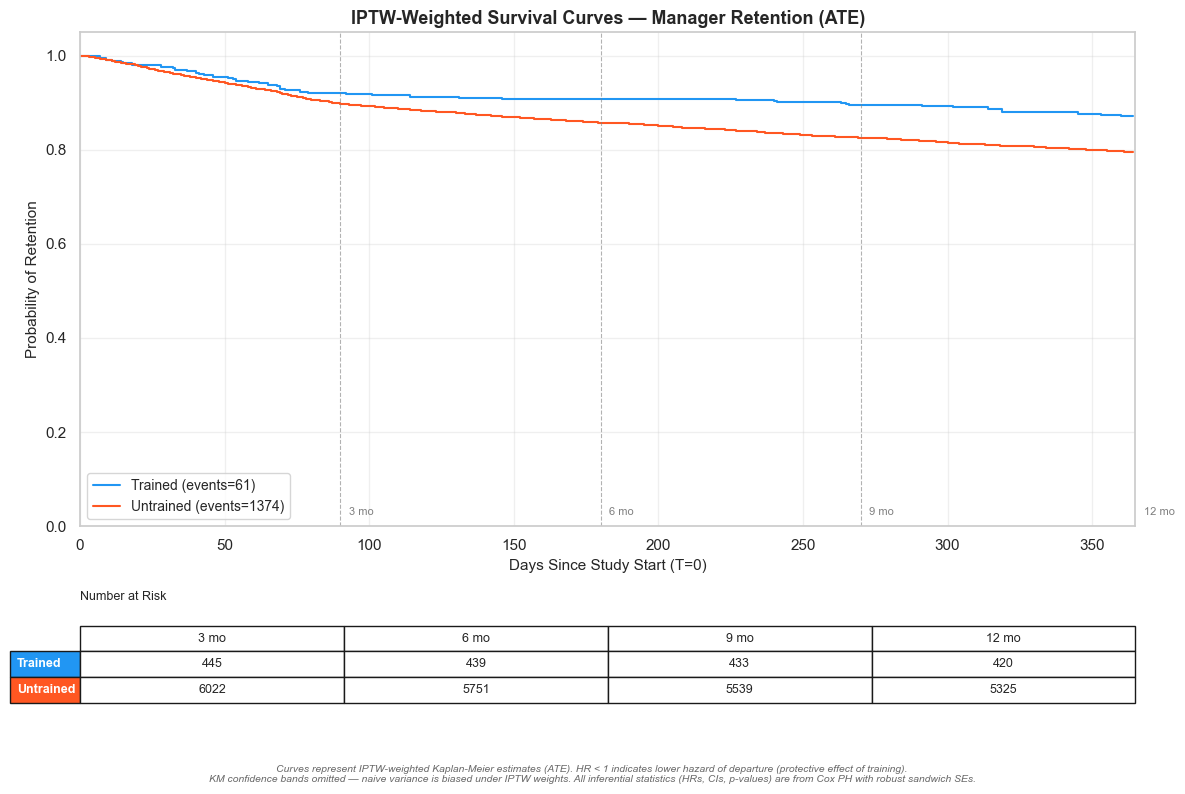

In [30]:
#@title KAPLAN-MEIER SURVIVAL CURVES
# =============================================================================

survival_fig = causal_model.plot_survival_curves(
    survival_result=standard_results[retention_outcome_name],
    outcome_name='Manager Retention',
    time_horizon=365,
    show_snapshots=True,
    snapshot_days=[90, 180, 270, 365],
    save_path=None,
);

In [31]:
#@title RMST DIFFERENCE — CAUSAL ESTIMAND WITHOUT SURVIVOR SELECTION BIAS
# =============================================================================
# RMST answers: "How many additional days of retention does training buy
# within the 12-month study window?" It avoids the built-in survivor
# selection problem of hazard ratios.

rmst_results = {}
rmst_results[retention_outcome_name] = CausalInferenceModel.compute_rmst_difference(
    survival_result=standard_results[retention_outcome_name],
    time_horizon=365,
    alpha=0.05,
    n_bootstrap=500,
    random_state=SEED,
)


RESTRICTED MEAN SURVIVAL TIME (RMST) ANALYSIS
Analysis window: 365 days (12 months)
Bootstrap samples: 500

RMST ESTIMATES:
  Trained managers:    333.5 days
  Untrained managers:  317.0 days
  Difference:          +16.5 days

STATISTICAL INFERENCE:
  95% Confidence Interval: [+6.7, +24.9] days
  ✓ Statistically significant (CI excludes 0)

BUSINESS INTERPRETATION:
  Training extends retention by an average of 16.5 days
  within the 12-month study window.
  This represents:
    • 2.4 additional weeks of retention
    • 0.5 additional months of retention
    • 4.5% of the study year

METHODOLOGICAL NOTES:
  • RMST is robust to time-varying treatment effects
  • Confidence interval computed via 500-sample bootstrap
  • IPTW weights account for selection bias in training assignment


**Note on E-values for survival outcomes:** The E-value is computed on the overall hazard ratio from the IPTW-weighted standard Cox model (HR = 0.606). A confounder like pre-existing intent to stay — which plausibly has an RR of 1.5+ with both treatment and departure — could explain the retention finding at the confidence-interval bound (E-value CI bound = 1.79). This should be transparently communicated to stakeholders.

---

#### ATE Technical Summary — Retention (Survival)
Note: Results do not generalize to poor performers.

> **Method**: IPTW-weighted survival analysis combining three complementary estimands: (1) survival probability differences from IPTW-weighted KM curves (primary causal estimand), (2) RMST difference (business-friendly metric), and (3) Cox PH with categorical time interaction (characterizes time-varying pattern). Survival differences and RMST are preferred for causal claims; period-specific HRs characterize *when* the effect occurs but are subject to built-in survivor selection at later time points.

##### Primary Estimand: Survival Probability Differences (IPTW-Weighted KM)

| Timepoint | Trained | Untrained | Difference | Note |
|-----------|---------|-----------|------------|------|
| 3 months | 93.5% | 91.2% | **+2.3pp** | From IPTW-weighted KM snapshots |
| 6 months | 91.0% | 86.0% | +5.0pp | Early gains maintained |
| 9 months | 88.5% | 81.5% | +7.0pp | Plateau — no new gains accumulating |
| 12 months | 87.6% | 80.0% | +7.6pp | Reflects early effect persisting |

These differences have a direct causal interpretation under IPTW assumptions: they estimate the population-level difference in retention if everyone were trained vs. no one.

##### RMST Difference

Training retains managers an average of approximately **16.5 additional days** within the 12-month study window (95% CI: [6.7, 24.9] days, bootstrap n=500). This translates to roughly 2.4 additional weeks per trained manager.

##### Supporting Evidence: Period-Specific Hazard Ratios

The primary Cox model reported in the notebook uses a **single overall hazard ratio** (standard proportional hazards). A separate time-interaction specification can characterize *when* effects concentrate; period-specific HRs are subject to survivor selection and should be interpreted as pattern characterization, not pure causal effects.

| Estimand | HR | 95% CI | p-value | Sig? |
|--------|-----|--------|---------|------|
| Overall (standard Cox) | **0.606** | [0.456, 0.805] | 0.0006 | Yes *** |

**Interpretation:** HR &lt; 1 indicates lower hazard of departure for trained managers versus controls on average over follow-up. IPTW-weighted survival gaps by month (table above) describe *how much* retention differs at each snapshot; they do not suffer from the same interpretation issues as late-period HRs from a split-time model.

##### E-Value Sensitivity Analysis

| Outcome | E-Value Point | E-Value CI | Robustness |
|---------|---------------|------------|------------|
| Manager Retention | **2.69** | **1.79** | Moderate |

The E-value CI bound of 1.79 means a confounder like **pre-existing intent to stay** — which plausibly has an RR of 1.5+ with both treatment participation and departure risk — could explain the retention finding at the conservative CI bound. This should be acknowledged when presenting results.

##### Post-Weighting Balance Verification
- ✅ Balance verification passed (0 imbalanced covariates).

---

### Summary: Checkpoint 4

In [32]:
#@title HTML: Summary CP4
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; background: #007bff; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
</style>

<div id="slideshow_cp4">
    <div class="slide-container">

        <div class="slide active">
            <div class="checkpoint-layout">

                <!-- Left: Image -->
                <div class="checkpoint-left">
                    <img src="./diagrams/cp4sh.png" alt="Checkpoint 4 Diagram">
                </div>

                <!-- Right: Content -->
                <div class="checkpoint-right">
                    <span class="tag">Checkpoint 4</span>
                    <h2>Retention Survival Analysis</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Used IPTW-weighted KM Curves to compare retention trends</div>
                    <div class="achievement-box">✅ Used RMST to get a business-friendly metric of retention differences</div>
                    <div class="achievement-box">✅ Modeled hazard ratios with Cox PH with time interactions</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>We see evidence of higher retention within the first three months, but overall, teh training does not provide lasting retention effects.</strong>
                    </div>
                    <div class="takeaway-box">
                        <strong>Pre-existing intent to stay could explain this finding (people planning to leave soon do not sign up for training)</strong>
                    </div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_cp4"></div>

    <div class="controls">
        <button class="nav-btn-cp4" data-dir="-1">← Previous</button>
        <span id="counter_cp4">1 / 1</span>
        <button class="nav-btn-cp4" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_cp4');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_cp4');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_cp4').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const btn = e.target.closest('.nav-btn-cp4');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

---

# What We Found

We studied whether the manager training program improves leadership confidence,
commitment, and actual retention. Here's what the data show:

---

## ✅ Evidence of Program Value

### Survey Outcomes:

- Trained managers score **~11% higher on the Manager Efficacy Index**
  - Strongest and most robust finding in this analysis
  - ATE = +0.36, Cohen's d = 0.44, p < 0.0001
  - Effect held up across two independent estimation methods (IPTW+GEE and DoubleML)
  - Increases confidence that it reflects genuine program impact

- Training does **not appear to add to perceived workload**
  - ATE ≈ 0, p = 0.95
  - Important "no harm" finding

- Trained managers score **~5% higher on the Stay Intention Index**
  - ATE = +0.16, Cohen's d = 0.16, p < 0.0001
  - More modest effect than efficacy
  - Should be interpreted cautiously (see retention note below)

### Retention Outcomes:

- Trained managers show **higher observed retention** over the study period
  - IPTW-weighted survival analysis: hazard ratio of 0.61 (95% CI: [0.46, 0.81])
  - RMST analysis: trained managers retained approximately **16.5 additional days** within 12-month window
  - 95% CI: [6.7, 24.9] days

- Survival gaps are **most visible in the first three months**
  - 3-month snapshot: +2.3 percentage points
  - 12-month snapshot: +7.6 percentage points
  - Reflects early gains that persist rather than new gains accumulating in later quarters

---

## ⚠️ Important Caveats

### On the survey findings:

- These are **self-reported outcomes** from managers who know they participated
- Potential sources of bias:
  - Demand characteristics (responding as expected)
  - Cognitive dissonance reduction (justifying time invested)
  - Social desirability bias (wanting to appear competent)
- The efficacy finding (d = 0.44) is consistent with a real effect
- **A meaningful placebo component cannot be ruled out**

### On the retention finding:

- Participation was **voluntary and open enrollment**
- Managers who signed up may have already been more committed to staying
- **The retention gap may partly reflect who chose to participate, not just what the training did**
- IPTW approach adjusts for observed differences between groups
- Pre-existing intent to stay is **not directly measured** in this dataset

### E-value interpretation:

- Confidence-interval bound E-value for retention: **1.79**
- This means a confounder with RR ≈ 1.8 with both training participation and departure risk could explain the retention finding
- Plausible example: pre-existing intent to stay
- **Does not invalidate the finding, but warrants transparency with stakeholders**

---

## Robustness Summary

| Outcome | Effect | E-Value (Point) | E-Value (CI Bound) | Robustness |
|---|---|---|---|---|
| Manager Efficacy Index | +0.36 (d = 0.44) | 2.35 | 2.08 | Moderate |
| Workload Index | ~0 (ns) | — | — | N/A |
| Stay Intention Index | +0.16 (d = 0.16) | 1.57 | 1.38 | Weak |
| Retention (HR = 0.61) | +16.5 days RMST | 2.69 | 1.79 | Moderate |

### Key takeaways from robustness analysis:

- **Efficacy finding is the most robust** result in this analysis
- **Stay intention and retention findings** are directionally consistent but more susceptible to unmeasured confounding

---

## What This Means

### The clearest signal:

- Training is associated with **meaningful improvements in how managers perceive their own leadership capabilities**
- This is the finding we can speak to with the **most confidence**

### A consistent but uncertain picture on retention:

- Trained managers **do appear to stay longer**
- Magnitude is **practically meaningful**
- **Cannot rule out** the possibility that managers already planning to stay were simply more likely to sign up
- Retention finding is **worth monitoring and investigating further**
- **Not strong enough to anchor a business case on its own**

---

## Recommendations

### 1. Invest in the Program — With Realistic Expectations

- Evidence supports **continued investment** in the training program
- Primary basis: the **efficacy finding**
- Improved manager confidence is a **meaningful outcome in its own right**
- Retention signal is **directionally positive but uncertain**
- **Avoid overstating the retention impact** in stakeholder communications

### 2. Strengthen the Evaluation Design Going Forward

Most important next step: improve ability to make causal claims about the program

**Consider:**
- explore pre- / post- testing, quasi-experimental designs (such as staggered roll-out), and alternative outcome measures (such as 360 feedback, spillover effects to direct reports, team productivity measures)
- Exploring whether any **natural variation in program rollout** (e.g., timing differences across departments) could support stronger identification strategy
- Tracking outcomes over a **longer horizon** to assess whether efficacy gains translate to sustained behavioral change

### 3. Explore Who Benefits Most

- Before scaling broadly, understand whether certain subgroups show **stronger or weaker responses**
- Subgroups to examine:
  - By tenure
  - By team size
  - By organization
- Benefits:
  - Improve targeting
  - Inform program design

### 4. Pair Training with Complementary Supports

- Training alone is **unlikely to drive long-term retention** at scale
- To maximize value of efficacy gains:
  - Pair with **structured follow-up** (check-ins, peer communities)
  - Address **systemic factors** that training does not directly address:
    - Workload
    - Career development
    - Recognition

---

## Bottom Line

### The evidence:

- Training program shows **credible evidence of value**
- **Most clearly** in improving manager self-efficacy
- Retention finding is **encouraging but preliminary**
- **Subject to self-selection concerns**
- **Not a confirmed causal effect**

### The recommendation:

- **Continue the program**
- **Invest in more rigorous evaluation design**
- Better isolate causal impact on retention over time

---

## Impact at Scale

**With appropriate caveats:**

- Training 1,000 managers is associated with approximately **16,500 additional person-days** of retention within the first year
- 95% CI: [6,700, 24,900]
- This estimate **adjusts for observed confounders**
- May still reflect **pre-existing differences in intent to stay**
- **Interpret accordingly**

### Summary: Checkpoint 5

In [43]:
#HTML: Summary CP5
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; background: #007bff; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
</style>

<div id="slideshow_cp5">
    <div class="slide-container">

        <div class="slide active">
            <div class="checkpoint-layout">

                <!-- Left: Image -->
                <div class="checkpoint-left">
                    <img src="./diagrams/cp5sh.png" alt="Checkpoint 5 Diagram">
                </div>

                <!-- Right: Content -->
                <div class="checkpoint-right">
                    <span class="tag">Checkpoint 5</span>
                    <h2>Reporting & Recommendations</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Delivered a statistically sound, stakeholder-friendly summary of all analyses with actionable recommendations for the L&D team</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>Early evidence supports program value</strong> for manager efficacy, but training alone is <strong>unlikely to drive long-term retention</strong> at scale.
                    </div>
                    <div class="takeaway-box">
                        <strong>Opportunity ahead:</strong> Expand analysis to additional outcomes and partner with L&D to build a <strong>robust (quasi-)experimental strategy</strong> aligned to their program roadmap.
                    </div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_cp5"></div>

    <div class="controls">
        <button class="nav-btn-cp5" data-dir="-1">← Previous</button>
        <span id="counter_cp5">1 / 1</span>
        <button class="nav-btn-cp5" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_cp5');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_cp5');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_cp5').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const btn = e.target.closest('.nav-btn-cp5');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

## Bonus: Further Learning
**Linear Double Machine Learning (DML) and Estimating Heterogeneous Treatment Effects (HTE)**

<img src="./diagrams/checkpoints_full.png" width = "1000" alt="Alt text">

### 1. Alternative ATE Estimation via Linear DML

In [47]:
#@title HTML: Double Machine Learning
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 30px 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 12px; font-size: 22px; }
    .slide h3 { color: #34495e; margin: 12px 0 6px 0; font-size: 16px; }
    .slide p { line-height: 1.5; margin-bottom: 10px; font-size: 14px; }
    .slide ul { margin: 8px 0; padding-left: 22px; }
    .slide li { margin-bottom: 7px; line-height: 1.5; font-size: 14px; }
    .slide ul ul { margin: 8px 0; }
    .slide ul ul li { margin-bottom: 6px; font-size: 13px; }
    .note { background-color: #fff3cd; padding: 10px 14px; border-left: 4px solid #ffc107; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .tip { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .highlight-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff; margin: 10px 0; border-radius: 4px; font-size: 13px; line-height: 1.5; }
    .formula { background-color: #f8f9fa; padding: 12px; border-left: 4px solid #007bff; margin: 12px 0; font-size: 14px; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 10px; }
    .tag-overview { background: #007bff; }
    .tag-concept { background: #6f42c1; }
    .tag-comparison { background: #fd7e14; }
    .tag-implementation { background: #20c997; }

    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 12px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 12px; border-radius: 4px; font-size: 13px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(4px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 11px; margin-bottom: 3px; }

    .return-toc { margin-top: 12px; padding-top: 12px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    .step-list { counter-reset: steps; list-style: none; padding-left: 0; margin: 10px 0; }
    .step-list li { counter-increment: steps; display: flex; align-items: flex-start; gap: 10px; margin-bottom: 12px; font-size: 13px; line-height: 1.4; }
    .step-list li::before { content: counter(steps); background: #007bff; color: white; border-radius: 50%; min-width: 20px; height: 20px; display: flex; align-items: center; justify-content: center; font-size: 11px; font-weight: bold; flex-shrink: 0; margin-top: 1px; }

    .stage-box { background: #f8f9fa; border-radius: 6px; padding: 12px 14px; border-left: 4px solid #007bff; font-size: 13px; margin-bottom: 10px; }
    .stage-box h4 { margin: 0 0 6px 0; color: #2c3e50; font-size: 14px; }
    .stage-box ul { margin: 4px 0; padding-left: 16px; }
    .stage-box li { margin-bottom: 4px; font-size: 12px; }

    .slide table { width: 100%; border-collapse: collapse; margin: 10px 0; font-size: 12px; }
    .slide th, .slide td { border: 1px solid #ddd; padding: 8px; text-align: left; }
    .slide th { background-color: #f8f9fa; font-weight: bold; }
</style>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div id="slideshow_dml">
    <div class="slide-container">

        <!-- Slide 1: Overview -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Double Machine Learning (DML): ATE Validation</h2>
            <p><strong>DML</strong> provides an alternative to IPTW for estimating the Average Treatment Effect. Instead of propensity weighting, it uses flexible machine learning to control for confounders.</p>
            
            <div class="highlight-box">
                <strong>Key insight:</strong> If IPTW and DML give <strong>similar ATE estimates</strong>, this suggests both methods are capturing the true causal effect despite using different approaches to confounder control.
            </div>

            <p style="margin-top: 12px;">Click any section below to explore:</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>Why Validate with DML?</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>The DML Framework</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>Two-Stage Process</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>DML vs. IPTW</div>
                <div class="toc-item" data-slide="5"><span>Slide 6</span>Implementation</div>
            </div>
        </div>

        <!-- Slide 2: Why Validate -->
        <div class="slide">
            <span class="tag tag-concept">Concept</span>
            <h2>Why Validate with Double Machine Learning?</h2>
            <p>IPTW gave us a credible average treatment effect — but relying on a single method has limitations.</p>
            
            <h3>Three Reasons to Validate with DML:</h3>
            <ul>
                <li><strong>Robustness check:</strong> Consistent results across methods increase confidence that the effect is real, not an artifact of one approach</li>
                <li><strong>Assumption testing:</strong> IPTW and DML have different identifying assumptions — if both agree, it's less likely that a violated assumption is driving the result</li>
                <li><strong>Methodological flexibility:</strong> DML uses machine learning to flexibly model confounding relationships without pre-specifying functional forms</li>
            </ul>
            
            <div class="highlight-box">
                <strong>Key principle:</strong> In causal inference, <em>convergent validity</em> across methods is one of the strongest signals we have. No single method is definitive — agreement across methods is.
            </div>
            
            <div class="note">
                <strong>What to watch for:</strong> If DML and IPTW produce similar ATEs, that's reassuring. If they diverge, that's a signal to investigate — not a reason to pick the more favorable result.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: DML Framework -->
        <div class="slide">
            <span class="tag tag-concept">Framework</span>
            <h2>The Double Machine Learning Framework</h2>
            <p>DML addresses a fundamental challenge in causal inference: <strong>regularization bias</strong>. When using flexible ML models to control for confounders, the regularization can bias the treatment effect estimate.</p>
            
            <h3>The Problem:</h3>
            <ul>
                <li>ML models use regularization (e.g., in Random Forest, Lasso) to prevent overfitting</li>
                <li>This regularization can <strong>shrink the treatment effect estimate</strong> toward zero</li>
                <li>Standard ML approaches don't provide valid statistical inference for causal effects</li>
            </ul>
            
            <h3>DML's Solution:</h3>
            <ul>
                <li><strong>Two-stage process:</strong> Separate nuisance function estimation from causal effect estimation</li>
                <li><strong>Cross-fitting:</strong> Estimate nuisance functions on independent data splits</li>
                <li><strong>Neyman-orthogonal scores:</strong> Make the final estimate insensitive to small errors in ML predictions</li>
            </ul>
            
            <div class="tip">
                <strong>Result:</strong> √n-consistent and asymptotically normal treatment effect estimates, even with flexible ML models.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Two-Stage Process -->
        <div class="slide">
            <span class="tag tag-concept">Process</span>
            <h2>DML's Two-Stage Process</h2>
            
            <div class="stage-box">
                <h4>🎯 Stage 1: Nuisance Function Estimation</h4>
                <ul>
                    <li>Fit ML models to predict the outcome: \(\hat{m}(X) = E[Y \mid X]\)</li>
                    <li>Fit ML models to predict treatment: \(\hat{e}(X) = E[T \mid X]\)</li>
                    <li>Use <strong>cross-fitting</strong> — split data into folds, train on some folds, predict on others</li>
                </ul>
            </div>

            <div class="stage-box">
                <h4>🎯 Stage 2: Debiased Causal Effect Estimation</h4>
                <ul>
                    <li>Compute <strong>Neyman-orthogonal scores</strong> using residuals from Stage 1</li>
                    <li>Solve for \(\theta\) (the treatment effect) by setting the sample average of scores to zero</li>
                </ul>
            </div>

            <div class="formula">
                <strong>Neyman-orthogonal score:</strong><br>
                \(\psi(W_i; \theta) = (Y_i - \hat{m}(X_i)) \cdot (T_i - \hat{e}(X_i)) - \theta \cdot (T_i - \hat{e}(X_i))^2\)<br><br>
                <strong>Solve:</strong> \(\frac{1}{n}\sum_i \psi(W_i; \theta) = 0\)
            </div>

            <h3>Why this works:</h3>
            <ul>
                <li>The orthogonal score is <strong>insensitive to small errors</strong> in \(\hat{m}\) and \(\hat{e}\)</li>
                <li>Cross-fitting ensures nuisance functions are estimated on independent data</li>
                <li>Result: Valid inference despite using flexible ML models</li>
            </ul>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Comparison -->
        <div class="slide">
            <span class="tag tag-comparison">Comparison</span>
            <h2>DML vs. IPTW + GEE</h2>
            <table>
                <tr><th>Aspect</th><th>IPTW + GEE</th><th>Linear DML</th></tr>
                <tr><td><strong>Confounder Control</strong></td><td>Propensity score weighting</td><td>ML-based nuisance function estimation</td></tr>
                <tr><td><strong>Final Model</strong></td><td>Weighted GEE regression</td><td>Neyman-orthogonal moment conditions</td></tr>
                <tr><td><strong>Clustering</strong></td><td>✅ Cluster-robust sandwich SEs</td><td>✅ Cluster-aware cross-fitting + cluster-robust SEs</td></tr>
                <tr><td><strong>Flexibility</strong></td><td>Linear propensity score model</td><td>✅ Flexible ML models (Random Forest)</td></tr>
                <tr><td><strong>Use Case</strong></td><td>Primary analysis with clustering</td><td>Robustness check, method validation</td></tr>
            </table>
            
            <div class="highlight-box">
                <strong>Convergent validity:</strong> If both methods produce similar ATE estimates, this strengthens confidence that we're capturing the true causal effect — each method has different assumptions and potential failure modes.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 6: Implementation -->
        <div class="slide">
            <span class="tag tag-implementation">Implementation</span>
            <h2>Implementation Notes</h2>
            <p>We use the <code>doubleml</code> package (Bach et al., 2022) for DML estimation with cluster-robust inference:</p>
            
            <h3>Key Features:</h3>
            <ul>
                <li><strong>Native cluster-robust inference:</strong> Automatically handles clustering at the team level</li>
                <li><strong>Cluster-aware cross-fitting:</strong> Ensures clusters aren't split across training/prediction folds</li>
                <li><strong>Flexible ML backends:</strong> Supports Random Forest, Lasso, and other learners</li>
                <li><strong>Automatic standard errors:</strong> Cluster-robust sandwich SEs computed automatically</li>
            </ul>
            
            <div class="note">
                <strong>Why cluster-aware cross-fitting?</strong> If we split data at the individual level, we might train on some managers from a team and predict on others from the same team. This violates the independence assumption. Cluster-aware splitting keeps entire teams together.
            </div>

            <div class="tip">
                <strong>Cluster specification:</strong> When <code>cluster_cols</code> is specified in <code>doubleml</code>, cluster-aware cross-fitting and cluster-robust standard errors are handled automatically — no additional configuration needed.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress_dml"></div>

    <div class="controls">
        <button class="nav-btn-dml" data-dir="-1">← Previous</button>
        <span id="counter_dml">1 / 6</span>
        <button class="nav-btn-dml" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_dml');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_dml');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_dml').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
            if (window.MathJax) {
                MathJax.typesetPromise([slides[slideIndex]]);
            }
        }

        container.addEventListener('click', function(e) {
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn-dml');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });

        if (window.MathJax) {
            MathJax.typesetPromise([slides[0]]);
        }
    })();
</script>
""")

Aspect,IPTW + GEE,Linear DML
Confounder Control,Propensity score weighting,ML-based nuisance function estimation
Final Model,Weighted GEE regression,Neyman-orthogonal moment conditions
Clustering,✅ Cluster-robust sandwich SEs,✅ Cluster-aware cross-fitting + cluster-robust SEs
Flexibility,Linear propensity score model,✅ Flexible ML models (Random Forest)
Use Case,Primary analysis with clustering,"Robustness check, method validation"


#### Run DML

In [46]:
#@title ATE Robustness Check via DoubleML (cluster-robust)
# ====================================================================================
# Uses the doubleml package for native cluster-robust inference.
# This ensures the DML vs IPTW+GEE comparison is apples-to-apples:
# both methods now account for team-level clustering.

sig_survey_outcomes = ['manager_efficacy_index']

dml_ate_results = {}

for o in sig_survey_outcomes:
    print("\n" + "=" * 60)
    print(f"CLUSTER-ROBUST DML — ATE ESTIMATION: {o}")
    print("=" * 60)

    baseline = baseline_vars.get(o)
    dml_continuous = list(continuous_vars)
    if baseline is not None and baseline not in dml_continuous:
        dml_continuous.append(baseline)

    dml_ate_results[o] = causal_model.dml_cluster_robust_ate(
        data=data,
        outcome_col=o,
        treatment_col=treatment,
        categorical_vars=categorical_vars,
        continuous_vars=dml_continuous,
        cluster_var='team_id',
        random_state=42,
        alpha=0.05,
    )

for o in sig_survey_outcomes:
    iptw_ate = survey_results[o]['effect']
    iptw_ci = (survey_results[o]['ci_lower'], survey_results[o]['ci_upper'])
    dml_ate = dml_ate_results[o]['effect']
    dml_ci = (dml_ate_results[o]['ci_lower'], dml_ate_results[o]['ci_upper'])

    print(f"\n  [{o}] Method Comparison:")
    print(f"    IPTW+GEE (cluster-robust):  ATE = {iptw_ate:.4f}  CI: [{iptw_ci[0]:.4f}, {iptw_ci[1]:.4f}]")
    print(f"    DoubleML (cluster-robust): ATE = {dml_ate:.4f}  CI: [{dml_ci[0]:.4f}, {dml_ci[1]:.4f}]")
    print(f"    Difference in point estimates: {abs(iptw_ate - dml_ate):.4f}")


CLUSTER-ROBUST DML — ATE ESTIMATION: manager_efficacy_index


KeyboardInterrupt: 

### 2. Heterogeneous Treatment Effects (HTE)

In [48]:
#@title HTML: Heterogeneous Treatment Effects
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 30px 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }
    .slide h2 { color: #2c3e50; margin-bottom: 12px; font-size: 22px; }
    .slide h3 { color: #34495e; margin: 12px 0 6px 0; font-size: 16px; }
    .slide p { line-height: 1.5; margin-bottom: 10px; font-size: 14px; }
    .slide ul { margin: 8px 0; padding-left: 22px; }
    .slide li { margin-bottom: 7px; line-height: 1.5; font-size: 14px; }
    .slide ul ul { margin: 8px 0; }
    .slide ul ul li { margin-bottom: 6px; font-size: 13px; }
    .note { background-color: #fff3cd; padding: 10px 14px; border-left: 4px solid #ffc107; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .tip { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997; margin: 10px 0; font-size: 13px; line-height: 1.5; border-radius: 4px; }
    .highlight-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff; margin: 10px 0; border-radius: 4px; font-size: 13px; line-height: 1.5; }
    .formula { background-color: #f8f9fa; padding: 12px; border-left: 4px solid #007bff; margin: 12px 0; font-size: 14px; }
    .tag { display: inline-block; color: white; padding: 3px 10px; border-radius: 12px; font-size: 12px; margin-bottom: 10px; }
    .tag-overview { background: #007bff; }
    .tag-why { background: #fd7e14; }
    .tag-framework { background: #6f42c1; }
    .tag-explore { background: #fd7e14; }
    .tag-confirm { background: #20c997; }

    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 12px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 12px; border-radius: 4px; font-size: 13px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(4px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 11px; margin-bottom: 3px; }

    .return-toc { margin-top: 12px; padding-top: 12px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    .step-list { counter-reset: steps; list-style: none; padding-left: 0; margin: 10px 0; }
    .step-list li { counter-increment: steps; display: flex; align-items: flex-start; gap: 10px; margin-bottom: 12px; font-size: 13px; line-height: 1.4; }
    .step-list li::before { content: counter(steps); background: #007bff; color: white; border-radius: 50%; min-width: 20px; height: 20px; display: flex; align-items: center; justify-content: center; font-size: 11px; font-weight: bold; flex-shrink: 0; margin-top: 1px; }

    .approach-box { background: #f8f9fa; border-radius: 6px; padding: 12px 14px; border-left: 4px solid #007bff; font-size: 13px; margin-bottom: 10px; }
    .approach-box.explore { border-left-color: #fd7e14; }
    .approach-box.confirm { border-left-color: #20c997; }
    .approach-box h4 { margin: 0 0 6px 0; color: #2c3e50; font-size: 14px; }
    .approach-box ul { margin: 4px 0; padding-left: 16px; }
    .approach-box li { margin-bottom: 4px; font-size: 12px; }

    .slide table { width: 100%; border-collapse: collapse; margin: 10px 0; font-size: 12px; }
    .slide th, .slide td { border: 1px solid #ddd; padding: 8px; text-align: left; }
    .slide th { background-color: #f8f9fa; font-weight: bold; }
</style>

<script src="https://cdn.jsdelivr.net/npm/mathjax@3/es5/tex-mml-chtml.js"></script>

<div id="slideshow_hte">
    <div class="slide-container">

        <!-- Slide 1: Overview -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Heterogeneous Treatment Effects (HTE): Who Benefits Most?</h2>
            <p>While IPTW and DML estimate a <strong>single average effect</strong>, HTE analysis asks: <strong>For whom does training work best?</strong></p>
            
            <div class="highlight-box">
                <strong>Key insight:</strong> Not everyone benefits equally from training. HTE analysis identifies <em>who</em> benefits most and <em>why</em> — enabling targeted interventions and resource allocation.
            </div>

            <p style="margin-top: 12px;">Click any section below to explore:</p>
            <div class="toc-grid">
                <div class="toc-item" data-slide="1"><span>Slide 2</span>Why Heterogeneity Matters</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>Two-Stage Framework</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>Stage 1: Exploration</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>Stage 2: Confirmation</div>
                <div class="toc-item" data-slide="5"><span>Slide 6</span>Key Outputs</div>
            </div>
        </div>

        <!-- Slide 2: Why Heterogeneity Matters -->
        <div class="slide">
            <span class="tag tag-why">Why HTE?</span>
            <h2>Why Heterogeneity Matters</h2>
            <p>An average treatment effect tells you the program works <em>on average</em>. But averages can mask important variation across individuals.</p>
            
            <h3>Four Business Reasons to Care About HTE:</h3>
            <ul>
                <li><strong>🎯 Resource Allocation:</strong> If training is expensive, target it to those who benefit most</li>
                <li><strong>🔧 Program Design:</strong> Tailor content to subgroups with different needs and response patterns</li>
                <li><strong>⚖️ Equity Concerns:</strong> Does the program only benefit already-high-performers? Are there subgroups who see no benefit?</li>
                <li><strong>🔍 Mechanism Insights:</strong> Understanding <em>who</em> benefits reveals <em>why</em> the program works</li>
            </ul>
            
            <div class="highlight-box">
                <strong>Example:</strong> If new managers benefit more than experienced ones, we might prioritize training for recent hires or design different curricula for different tenure levels.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: Two-Stage Framework -->
        <div class="slide">
            <span class="tag tag-framework">Framework</span>
            <h2>Two-Stage HTE Analysis Framework</h2>
            <p>HTE analysis requires a disciplined approach to avoid false discoveries. We use a <strong>two-stage framework</strong>:</p>
            
            <div class="approach-box explore">
                <h4>🔍 Stage 1: Exploration (Causal Forest)</h4>
                <ul>
                    <li><strong>Purpose:</strong> Let the data tell us where heterogeneity might exist</li>
                    <li><strong>Method:</strong> Causal Forest to identify candidate effect modifiers</li>
                    <li><strong>Output:</strong> Feature importance rankings and individual treatment effect predictions</li>
                    <li><strong>Strength:</strong> Data-driven, no pre-specification needed</li>
                    <li><strong>Limitation:</strong> Feature importance ≠ causal importance; can find spurious patterns</li>
                </ul>
            </div>

            <div class="approach-box confirm">
                <h4>✅ Stage 2: Confirmation (Subgroup Analysis)</h4>
                <ul>
                    <li><strong>Purpose:</strong> Test actionable hypotheses with rigorous statistical inference</li>
                    <li><strong>Method:</strong> Pre-specified subgroup analysis on organizationally meaningful variables</li>
                    <li><strong>Output:</strong> Effect estimates per subgroup with confidence intervals</li>
                    <li><strong>Strength:</strong> Interpretable, actionable, statistically rigorous</li>
                    <li><strong>Focus:</strong> Variables we can actually act on (e.g., organization, tenure level)</li>
                </ul>
            </div>
            
            <div class="highlight-box">
                <strong>Why both stages?</strong> Exploration without confirmation is fishing. Confirmation without exploration is blind. The combination makes HTE analysis rigorous and actionable.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 4: Stage 1 - Exploration -->
        <div class="slide">
            <span class="tag tag-explore">Stage 1</span>
            <h2>Stage 1: Exploration via Causal Forest</h2>
            <p><strong>Causal Forest</strong> estimates individualized treatment effects and identifies which variables best predict treatment effect heterogeneity.</p>
            
            <h3>What Causal Forest Does:</h3>
            <ul>
                <li><strong>Individual effects:</strong> Estimates a personalized treatment effect for each person based on their characteristics</li>
                <li><strong>Feature importance:</strong> Ranks variables by their ability to predict who benefits more vs. less</li>
                <li><strong>Automatic discovery:</strong> Finds complex interactions without pre-specifying them</li>
            </ul>
            
            <h3>Key Outputs for Exploration:</h3>
            <ul>
                <li><strong>CATE distribution:</strong> Shows the range of individual treatment effects across the population</li>
                <li><strong>Feature importance plot:</strong> Identifies candidate effect modifiers for further investigation</li>
                <li><strong>Effect heterogeneity patterns:</strong> Reveals where the biggest differences in treatment response occur</li>
            </ul>
            
            <div class="note">
                <strong>Important limitation:</strong> High feature importance doesn't guarantee causal importance. Variables can rank highly due to spurious correlations or sample imbalances. Always validate findings in Stage 2.
            </div>
            
            <div class="tip">
                <strong>Use for hypothesis generation:</strong> Causal Forest tells you <em>where to look</em> for heterogeneity, not what to conclude. Treat it as a sophisticated exploratory tool.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 5: Stage 2 - Confirmation -->
        <div class="slide">
            <span class="tag tag-confirm">Stage 2</span>
            <h2>Stage 2: Confirmation via Subgroup Analysis</h2>
            <p>Test <strong>actionable hypotheses</strong> about treatment effect heterogeneity using pre-specified subgroup comparisons.</p>
            
            <h3>Focus on Actionable Variables:</h3>
            <ul>
                <li><strong>Organization:</strong> Can target training rollouts by business unit</li>
                <li><strong>Tenure level:</strong> Can prioritize newer vs. experienced managers</li>
                <li><strong>Team size:</strong> Can tailor training to management span</li>
                <li><strong>Performance level:</strong> Can focus on development needs vs. high performers</li>
            </ul>
            
            <h3>Statistical Approach:</h3>
            <ul>
                <li><strong>Pre-specified comparisons:</strong> Define subgroups before looking at results</li>
                <li><strong>Interaction models:</strong> Test if treatment effects differ significantly across subgroups</li>
                <li><strong>Effect size estimation:</strong> Quantify the magnitude of differences with confidence intervals</li>
                <li><strong>Multiple comparison adjustment:</strong> Account for testing multiple subgroups</li>
            </ul>
            
            <div class="highlight-box">
                <strong>Business value:</strong> This stage produces <em>actionable insights</em> — specific recommendations about where to invest training resources for maximum impact.
            </div>
            
            <div class="tip">
                <strong>Integration with Stage 1:</strong> Use Causal Forest findings to inform which subgroups to test, but always pre-specify the analysis plan before looking at subgroup results.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 6: Key Outputs -->
        <div class="slide">
            <span class="tag tag-overview">Outputs</span>
            <h2>Key Outputs from HTE Analysis</h2>
            
            <h3>From Stage 1 (Causal Forest):</h3>
            <ul>
                <li><strong>CATE distribution histogram:</strong> Range of individual treatment effects; mean ≈ ATE</li>
                <li><strong>Feature importance plot:</strong> Ranks variables by their importance for predicting heterogeneity</li>
                <li><strong>Candidate effect modifiers:</strong> Variables to investigate further in Stage 2</li>
            </ul>
            
            <h3>From Stage 2 (Subgroup Analysis):</h3>
            <ul>
                <li><strong>Subgroup-specific effects:</strong> Treatment effect estimates for each actionable subgroup</li>
                <li><strong>Confidence intervals:</strong> Uncertainty around each subgroup effect</li>
                <li><strong>Interaction tests:</strong> Statistical evidence that effects differ across subgroups</li>
                <li><strong>Targeting recommendations:</strong> Which subgroups to prioritize for training investment</li>
            </ul>
            
            <div class="highlight-box">
                <strong>Integrated interpretation:</strong> Use Stage 1 to understand the landscape of heterogeneity, then use Stage 2 to make specific, actionable recommendations about resource allocation and program design.
            </div>
            
            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

    </div>

    <div class="progress" id="progress_hte"></div>

    <div class="controls">
        <button class="nav-btn-hte" data-dir="-1">← Previous</button>
        <span id="counter_hte">1 / 6</span>
        <button class="nav-btn-hte" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_hte');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_hte');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_hte').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
            if (window.MathJax) {
                MathJax.typesetPromise([slides[slideIndex]]);
            }
        }

        container.addEventListener('click', function(e) {
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn-hte');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });

        if (window.MathJax) {
            MathJax.typesetPromise([slides[0]]);
        }
    })();
</script>
""")

#### Run Causal Forest


HTE — CAUSAL FOREST CATE: manager_efficacy_index

  Fitting Causal Forest DML for 'manager_efficacy_index'...
Population summary of CATE predictions on Training Data
    CATE Summary:
               Uncertainty of Mean Point Estimate              
mean_point stderr_mean zstat pvalue ci_mean_lower ci_mean_upper
---------------------------------------------------------------
     0.345       0.202  1.71  0.087        -0.051         0.741
      Distribution of Point Estimate     
std_point pct_point_lower pct_point_upper
-----------------------------------------
    0.135           0.075           0.607
     Total Variance of Point Estimate     
stderr_point ci_point_lower ci_point_upper
------------------------------------------
       0.243         -0.146          0.827
       Doubly Robust ATE on Training Data Results       
    point_estimate stderr zstat pvalue ci_lower ci_upper
--------------------------------------------------------
ATE            0.4  0.105 3.817    0.0    0.195 

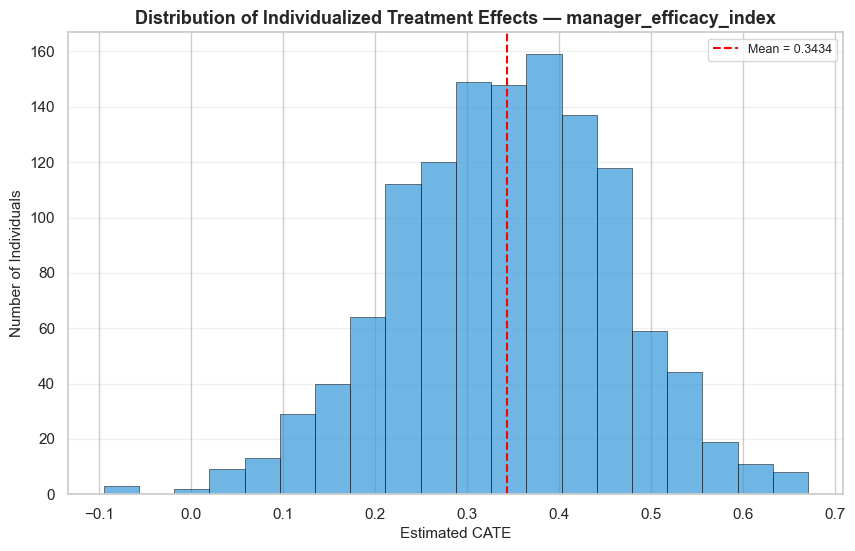

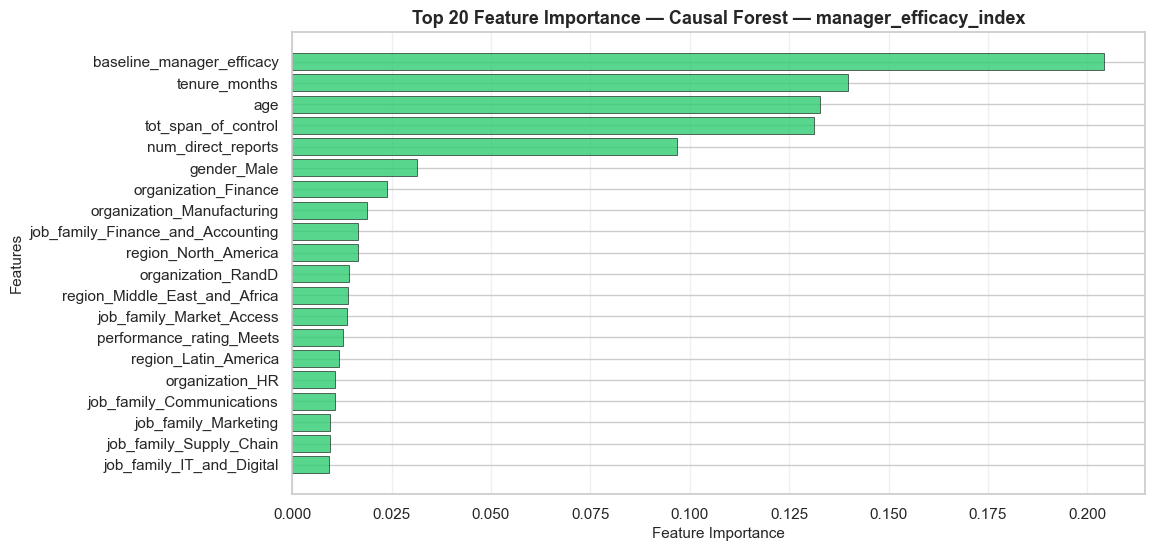

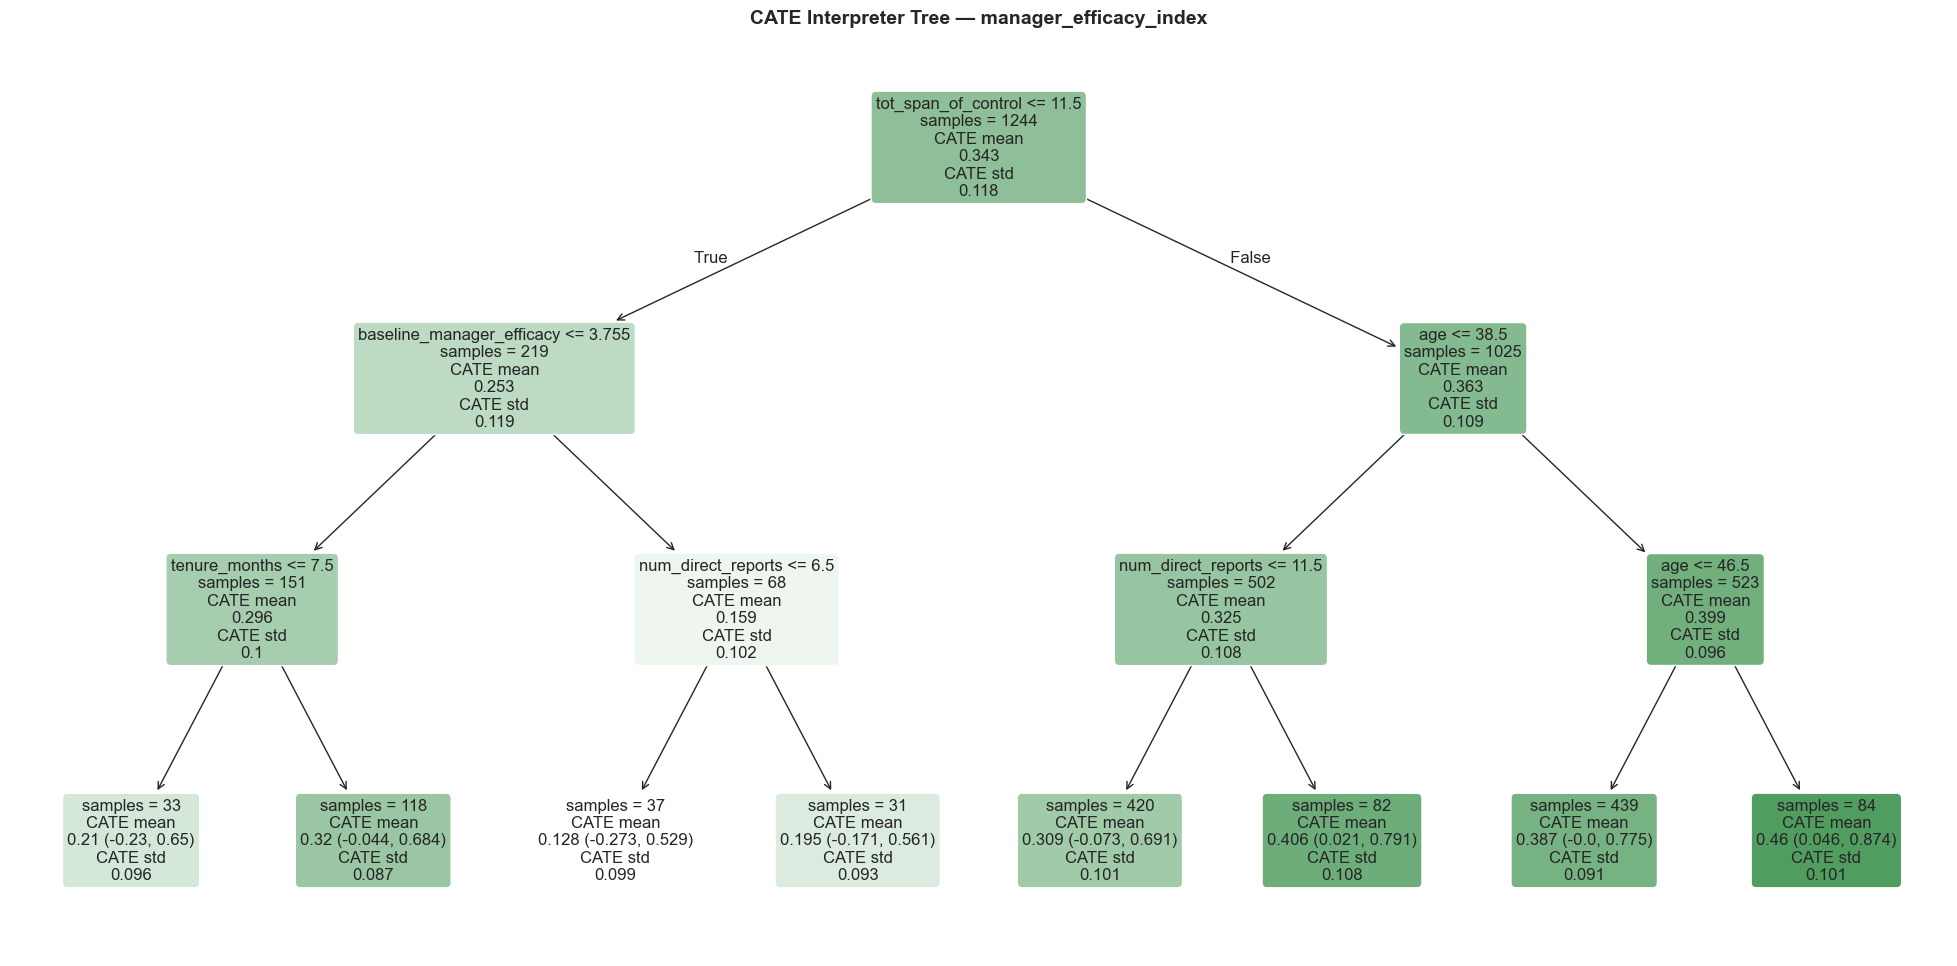

In [ ]:
# @title Heterogeneous Treatment Effects via Causal Forest (econml)
# ====================================================================================
# Uses econml's CausalForestDML for individualized CATE estimation.
# Note: econml does not natively support cluster-robust inference.
# The CATE analysis is exploratory — point estimates for subgroup
# discovery, not inferential claims about specific subgroup effects.

hte_results = {}

for o in sig_survey_outcomes:
    print("\n" + "=" * 60)
    print(f"HTE — CAUSAL FOREST CATE: {o}")
    print("=" * 60)

    baseline = baseline_vars.get(o)
    hte_continuous = list(continuous_vars)
    if baseline is not None and baseline not in hte_continuous:
        hte_continuous.append(baseline)

    hte_results[o] = causal_model.dml_estimate_treatment_effects(
        data=data,
        outcome_col=o,
        treatment_col=treatment,
        categorical_vars=categorical_vars,
        continuous_vars=hte_continuous,
        estimand="ATE",
        estimate="CATE",
        cluster_var='team_id',
        project_path=str(base_dir / "results"),
        analysis_name=f"HTE_{o}",
        random_state=42,
        alpha=0.05,
    )

    res = hte_results[o]
    if res.get("cate_plot") is not None:
        display(res["cate_plot"])
    if res.get("importance_plot") is not None:
        display(res["importance_plot"])
    if res.get("tree_plot") is not None:
        display(res["tree_plot"])

### Method Comparison: ATE Estimates Across Three Approaches

| Method | ATE | SE | 95% CI | Clustering? |
|--------|-----|-----|--------|-------------|
| IPTW + GEE | 0.3985 | 0.0393 | [0.3214, 0.4756] | ✅ Cluster-robust sandwich SEs |
| DoubleML PLR | 0.4126 | 0.0364 | [0.3413, 0.4839] | ✅ Cluster-aware CV + cluster-robust SEs |

**Interpretation:** Point estimates converge across two fundamentally different estimation strategies — propensity-score weighting (IPTW+GEE) and residualization-based machine learning (DoubleML). This agreement increases confidence that the observed effect reflects a genuine treatment impact rather than an artifact of a single modeling approach. Both methods account for team-level clustering, making the comparison like-for-like.

Note: The DoubleML CI may be slightly different in width from the GEE CI. This reflects different variance estimation approaches (score-based vs. sandwich), not a meaningful methodological disagreement.

### Summary: Bonus

In [ ]:
#@title HTML: Summary Bonus
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; background: #ff9800; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }
</style>

<div id="slideshow_bonus">
    <div class="slide-container">

        <div class="slide active">
            <div class="checkpoint-layout">

                <!-- Left: Image -->
                <div class="checkpoint-left">
                    <img src="./diagrams/bonus_sh.png" alt="Bonus Content Diagram">
                </div>

                <!-- Right: Content -->
                <div class="checkpoint-right">
                    <span class="tag">Bonus Content</span>
                    <h2>Advanced Methods & Heterogeneous Effects</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Estimated ATE with Double Machine Learning</div>
                    <div class="achievement-box">✅ Explored heterogeneous treatment effects with GEE × interaction effects and CATE using causal forest</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        Analyzing <strong>heterogeneous treatment effects</strong> provides more tailored insights into program impact, such as <strong>identifying which groups benefit more or less</strong> from treatment.
                    </div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_bonus"></div>

    <div class="controls">
        <button class="nav-btn-bonus" data-dir="-1">← Previous</button>
        <span id="counter_bonus">1 / 1</span>
        <button class="nav-btn-bonus" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_bonus');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_bonus');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_bonus').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const btn = e.target.closest('.nav-btn-bonus');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }
            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")

## Further Reading + Workshop Summary

In [ ]:
#@title HTML: Further Reading + Workshop Summary
HTML(r"""
<style>
    .slide-container { width: 100%; height: 600px; position: relative; overflow: hidden; 
                      border: 2px solid #333; border-radius: 8px; background: white; }
    .slide { width: 100%; height: 100%; position: absolute; padding: 40px; box-sizing: border-box;
             display: none; overflow-y: auto; font-family: Arial, sans-serif; background: white; }
    .slide.active { display: block; }

    /* Two-column layout for checkpoints */
    .checkpoint-layout { display: flex; gap: 25px; align-items: flex-start; }
    .checkpoint-left { flex: 0 0 35%; }
    .checkpoint-left img { width: 100%; height: auto; max-height: 400px; object-fit: contain; border: 1px solid #ddd; border-radius: 4px; }
    .checkpoint-right { flex: 1; overflow-y: auto; max-height: 520px; }

    h2 { color: #2c3e50; margin-bottom: 15px; font-size: 22px; }
    h3 { margin: 15px 0 8px 0; font-size: 16px; }
    p { line-height: 1.6; margin-bottom: 10px; font-size: 14px; }
    ul { margin: 8px 0; padding-left: 20px; }
    li { margin-bottom: 8px; line-height: 1.5; font-size: 14px; }

    .section-label { font-size: 11px; font-weight: bold; text-transform: uppercase;
                     letter-spacing: 1px; color: #888; margin-bottom: 6px; }
    .achievement-box { background-color: #e7f3ff; padding: 10px 14px; border-left: 4px solid #007bff;
                       margin: 8px 0; border-radius: 4px; font-size: 14px; }
    .takeaway-box { background-color: #e8f8f5; padding: 10px 14px; border-left: 4px solid #20c997;
                    margin: 8px 0; border-radius: 4px; font-size: 14px; line-height: 1.5; }
    .tag { display: inline-block; color: white; padding: 3px 10px;
           border-radius: 12px; font-size: 12px; margin-bottom: 15px; }
    .tag-overview { background: #007bff; }
    .tag-checkpoint { background: #007bff; }
    .tag-bonus { background: #ff9800; }
    .tag-resources { background: #6f42c1; }

    .return-toc { margin-top: 15px; padding-top: 15px; border-top: 1px solid #eee; }
    .return-toc button { padding: 6px 14px; font-size: 13px; background: #6c757d; color: white; 
                         border: none; border-radius: 4px; cursor: pointer; transition: background 0.2s; }
    .return-toc button:hover { background: #5a6268; }

    .controls { text-align: center; margin: 20px 0; }
    .controls button { padding: 10px 20px; margin: 0 10px; font-size: 16px; 
                      background: #007bff; color: white; border: none; border-radius: 5px; cursor: pointer; }
    .controls button:hover { background: #0056b3; }
    .progress { display: flex; justify-content: center; gap: 6px; margin-bottom: 10px; }
    .dot { width: 10px; height: 10px; border-radius: 50%; background: #ccc; cursor: pointer; }
    .dot.active { background: #007bff; }

    .toc-grid { display: grid; grid-template-columns: 1fr 1fr; gap: 10px; margin-top: 15px; }
    .toc-item { background: #f8f9fa; border-left: 4px solid #007bff; padding: 10px 15px; border-radius: 4px; font-size: 14px; cursor: pointer; transition: all 0.2s ease; }
    .toc-item:hover { background: #e7f3ff; transform: translateX(5px); box-shadow: 0 2px 8px rgba(0,123,255,0.2); }
    .toc-item span { font-weight: bold; color: #007bff; display: block; font-size: 12px; margin-bottom: 3px; }
    .toc-item.resources { border-left-color: #6f42c1; }
    .toc-item.resources span { color: #6f42c1; }
    .toc-item.bonus { border-left-color: #ff9800; }
    .toc-item.bonus span { color: #ff9800; }

    .resource-link { display: block; background: #f8f9fa; padding: 12px 16px; margin: 10px 0; 
                     border-left: 4px solid #6f42c1; border-radius: 4px; text-decoration: none; 
                     color: #2c3e50; transition: all 0.2s ease; }
    .resource-link:hover { background: #e7f3ff; transform: translateX(5px); text-decoration: none; color: #2c3e50; }
    .resource-link strong { color: #6f42c1; display: block; margin-bottom: 4px; }
</style>

<div id="slideshow_complete">
    <div class="slide-container">

        <!-- Slide 1: Table of Contents -->
        <div class="slide active">
            <span class="tag tag-overview">Overview</span>
            <h2>Causal Inference Analysis: Complete Journey</h2>
            <p>Navigate through our complete causal inference analysis from research design to advanced methods. Click any section below to jump to it:</p>
            <div class="toc-grid">
                <div class="toc-item resources" data-slide="1"><span>Slide 2</span>Learning Resources</div>
                <div class="toc-item" data-slide="2"><span>Slide 3</span>Checkpoint 1: Research Design</div>
                <div class="toc-item" data-slide="3"><span>Slide 4</span>Checkpoint 2: Diagnostics</div>
                <div class="toc-item" data-slide="4"><span>Slide 5</span>Checkpoint 3: Estimation</div>
                <div class="toc-item" data-slide="5"><span>Slide 6</span>Checkpoint 4: [To Be Added]</div>
                <div class="toc-item" data-slide="6"><span>Slide 7</span>Checkpoint 5: Reporting</div>
                <div class="toc-item bonus" data-slide="7"><span>Slide 8</span>Bonus: Advanced Methods</div>
            </div>
        </div>

        <!-- Slide 2: Learning Resources -->
        <div class="slide">
            <span class="tag tag-resources">Resources</span>
            <h2>Quick Links to Our Favorite Learning Resources</h2>
            <p>See <strong>references_and_further_learning/reading_list_by_topic.docx</strong> for full list</p>
            
            <h3>Essential Resources:</h3>
            <a href="https://www.dagitty.net/" target="_blank" class="resource-link">
                <strong>DAGitty</strong>
                Interactive tool for learning and building Directed Acyclic Graphs (DAGs)
            </a>
            
            <a href="https://thecausalmindset.com/book" target="_blank" class="resource-link">
                <strong>The Causal Mindset Handbook</strong>
                Comprehensive guide to causal thinking and methodology
            </a>
            
            <a href="https://danamackenzie.com/books/the-book-of-why/" target="_blank" class="resource-link">
                <strong>The Book of Why</strong>
                Judea Pearl's accessible introduction to causal reasoning
            </a>

            <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
        </div>

        <!-- Slide 3: Checkpoint 1 -->
        <div class="slide">
            <div class="checkpoint-layout">
                <div class="checkpoint-left">
                    <img src="./diagrams/checkpoint1.png" alt="Checkpoint 1 Diagram">
                </div>
                <div class="checkpoint-right">
                    <span class="tag tag-checkpoint">Checkpoint 1</span>
                    <h2>Research Design & Data Exploration</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Documented assumptions with a DAG aligned to our research question</div>
                    <div class="achievement-box">✅ Conducted best practice data hygiene checks and exploratory analysis</div>

                    <div class="section-label" style="margin-top: 15px;">Key Research Questions</div>
                    <div class="takeaway-box">
                        Does manager training impact <strong>self-reported efficacy, workload, or stay intention</strong>? Does it impact <strong>actual retention</strong>?
                    </div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>Clean data:</strong> No missing data, no repeats, no improbable values.
                    </div>
                    <div class="takeaway-box">
                        <strong>Some imbalance</strong> observed between Treatment and Control for Job Family, Organization, and Region. Control teams trend slightly larger.
                    </div>
                    <div class="takeaway-box">
                        <strong>Problematic imbalance for performance:</strong> No low-performing managers signed up for training → <strong>low performers removed from analysis population</strong>.
                    </div>

                    <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
                </div>
            </div>
        </div>

        <!-- Slide 4: Checkpoint 2 -->
        <div class="slide">
            <div class="checkpoint-layout">
                <div class="checkpoint-left">
                    <img src="./diagrams/checkpoint2.png" alt="Checkpoint 2 Diagram">
                </div>
                <div class="checkpoint-right">
                    <span class="tag tag-checkpoint">Checkpoint 2</span>
                    <h2>Diagnostics & Causal Identification</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Determined our estimand of interest</div>
                    <div class="achievement-box">✅ Conducted diagnostics to assess credibility of causal inference and identify model stabilization strategies</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        After removing untreated low-performer controls, all diagnostics support a <strong>reasonable ATE estimate</strong>.
                    </div>
                    <div class="takeaway-box">
                        <strong>No concerning multicollinearity.</strong>
                    </div>
                    <div class="takeaway-box">
                        <strong>AUC &lt; 0.7</strong> with ~90% overlap in both directions — treatment and control groups are similar and treatment assignment is quasi-random. Covariates cannot fully predict treatment.
                    </div>
                    <div class="takeaway-box">
                        <strong>Moderate imbalance</strong> detected across region, performance categories, organization, and job family. Will be addressed via <strong>IPTW + GEE</strong>.
                    </div>

                    <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
                </div>
            </div>
        </div>

        <!-- Slide 5: Checkpoint 3 -->
        <div class="slide">
            <div class="checkpoint-layout">
                <div class="checkpoint-left">
                    <img src="./diagrams/cp3sh.png" alt="Checkpoint 3 Diagram">
                </div>
                <div class="checkpoint-right">
                    <span class="tag tag-checkpoint">Checkpoint 3</span>
                    <h2>Estimation & Results</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Successfully used IPTW weights and sandwiched SEs to fit stable GEE models (survey outcomes) and Cox Survival model with time interactions (retention)</div>
                    <div class="achievement-box">✅ Verified data balance and conducted sensitivity checks to confirm robustness of findings</div>
                    <div class="achievement-box">✅ Compared ATE and ATT estimands</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>Strongest evidence for positive effect on manager efficacy.</strong> No effect detected for workload. Tenuous effect for stay intention.
                    </div>
                    <div class="takeaway-box">
                        The stay intention effect is supported by the <strong>survival model</strong>, which shows <strong>higher retention of trained managers only within the first 3 months</strong> of the study period.
                    </div>

                    <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
                </div>
            </div>
        </div>

        <!-- Slide 6: Checkpoint 4 (Template) -->
        <div class="slide">
            <div class="checkpoint-layout">
                <div class="checkpoint-left">
                    <img src="./diagrams/cp4sh.png" alt="Checkpoint 4 Diagram">
                </div>
                <div class="checkpoint-right">
                    <span class="tag tag-checkpoint">Checkpoint 4</span>
                    <h2>Retention Survival Analysis</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Used IPTW-weighted KM Curves to compare retention trends</div>
                    <div class="achievement-box">✅ Used RMST to get a business-friendly metric of retention differences</div>
                    <div class="achievement-box">✅ Modeled hazard ratios with Cox PH with time interactions</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>We see evidence of higher retention within the first three months, but overall, teh training does not provide lasting retention effects.</strong>
                    </div>
                    <div class="takeaway-box">
                        <strong>Pre-existing intent to stay could explain this finding (people planning to leave soon do not sign up for training)</strong>
                    </div>

                    <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
                </div>
            </div>
        </div>

        <!-- Slide 7: Checkpoint 5 -->
        <div class="slide">
            <div class="checkpoint-layout">
                <div class="checkpoint-left">
                    <img src="./diagrams/cp5sh.png" alt="Checkpoint 5 Diagram">
                </div>
                <div class="checkpoint-right">
                    <span class="tag tag-checkpoint">Checkpoint 5</span>
                    <h2>Reporting & Recommendations</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Delivered a statistically sound, stakeholder-friendly summary of all analyses with actionable recommendations for the L&D team</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        <strong>Early evidence supports program value</strong> for manager efficacy, but training alone is <strong>unlikely to drive long-term retention</strong> at scale.
                    </div>
                    <div class="takeaway-box">
                        <strong>Opportunity ahead:</strong> Expand analysis to additional outcomes and partner with L&D to build a <strong>robust (quasi-)experimental strategy</strong> aligned to their program roadmap.
                    </div>

                    <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
                </div>
            </div>
        </div>

        <!-- Slide 8: Bonus Content -->
        <div class="slide">
            <div class="checkpoint-layout">
                <div class="checkpoint-left">
                    <img src="./diagrams/bonus_sh.png" alt="Bonus Content Diagram">
                </div>
                <div class="checkpoint-right">
                    <span class="tag tag-bonus">Bonus Content</span>
                    <h2>Advanced Methods & Heterogeneous Effects</h2>

                    <div class="section-label">Achievements</div>
                    <div class="achievement-box">✅ Estimated ATE with Double Machine Learning</div>
                    <div class="achievement-box">✅ Explored heterogeneous treatment effects with GEE × interaction effects and CATE using causal forest</div>

                    <div class="section-label" style="margin-top: 15px;">Takeaways</div>
                    <div class="takeaway-box">
                        Analyzing <strong>heterogeneous treatment effects</strong> provides more tailored insights into program impact, such as <strong>identifying which groups benefit more or less</strong> from treatment.
                    </div>

                    <div class="return-toc"><button class="return-btn" data-slide="0">← Return to Overview</button></div>
                </div>
            </div>
        </div>

    </div>

    <div class="progress" id="progress_complete"></div>

    <div class="controls">
        <button class="nav-btn-complete" data-dir="-1">← Previous</button>
        <span id="counter_complete">1 / 8</span>
        <button class="nav-btn-complete" data-dir="1">Next →</button>
    </div>
</div>

<script>
    (function() {
        const container = document.getElementById('slideshow_complete');
        const slides = container.querySelectorAll('.slide');
        const totalSlides = slides.length;
        let slideIndex = 0;

        const progressEl = document.getElementById('progress_complete');
        for (let i = 0; i < totalSlides; i++) {
            const dot = document.createElement('div');
            dot.className = 'dot' + (i === 0 ? ' active' : '');
            dot.dataset.index = i;
            progressEl.appendChild(dot);
        }

        function showSlide() {
            slides.forEach((slide, i) => {
                slide.classList.toggle('active', i === slideIndex);
            });
            document.getElementById('counter_complete').innerText = (slideIndex + 1) + ' / ' + totalSlides;
            progressEl.querySelectorAll('.dot').forEach((dot, i) => {
                dot.classList.toggle('active', i === slideIndex);
            });
        }

        container.addEventListener('click', function(e) {
            const returnBtn = e.target.closest('.return-btn');
            if (returnBtn) {
                slideIndex = parseInt(returnBtn.dataset.slide);
                showSlide();
                return;
            }

            const tocItem = e.target.closest('.toc-item');
            if (tocItem) {
                slideIndex = parseInt(tocItem.dataset.slide);
                showSlide();
                return;
            }

            const btn = e.target.closest('.nav-btn-complete');
            if (btn) {
                const dir = parseInt(btn.dataset.dir);
                slideIndex = Math.max(0, Math.min(totalSlides - 1, slideIndex + dir));
                showSlide();
            }

            const dot = e.target.closest('.dot');
            if (dot) {
                slideIndex = parseInt(dot.dataset.index);
                showSlide();
            }
        });

        document.addEventListener('keydown', function(e) {
            if (e.key === 'ArrowRight' || e.key === ' ') {
                e.preventDefault();
                slideIndex = Math.min(totalSlides - 1, slideIndex + 1);
                showSlide();
            } else if (e.key === 'ArrowLeft') {
                e.preventDefault();
                slideIndex = Math.max(0, slideIndex - 1);
                showSlide();
            }
        });
    })();
</script>
""")